# Parametric estimator analysis from subject artifacts

This notebook:

1. discovers and loads campaign artifacts
2. builds subject-level artifacts
3. fits parametric models to **observed non-zero incidence-frequency data**
4. computes parametric estimators from the **fitted model parameters**
5. compares parametric and non-parametric estimators
6. saves summary tables and plot data
7. visualises subject-level model fits and estimator behaviour

The zero-truncated comparison models (`ztPoisson`, `ztNB`) have been removed.


In [61]:
from __future__ import annotations

import json
import math
import pickle
import re
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize, root_scalar
from scipy.special import gammaln
from scipy.stats import (
    poisson as sp_poisson,
    expon as sp_expon,
    gamma as sp_gamma,
    nbinom as sp_nbinom,
    chi2 as sp_chi2,
    kstest as sp_ks,
)


In [62]:
# ============================================================
# Configuration
# ============================================================

#RAW_DATA_DIR = Path("/Volumes/PRJ-FSS/data_2NT")
#RAW_DATA_DIR = Path("/Users/natt0753/USYD/Papers_Submitted/ISSRE2026/main_V2/issre2026-parametric-species/data")
RAW_DATA_DIR = Path("/Volumes/PRJ-FSS/ISSRE2026")
OUTPUT_DIR = Path("./analysis_outputs_new")
#ARTIFACTS_DIR = OUTPUT_DIR / "campaign_artifacts"
ARTIFACTS_DIR = RAW_DATA_DIR / "campaign_artifacts"
SUBJECT_ARTIFACTS_DIR = OUTPUT_DIR / "subject_artifacts"
SUMMARIES_DIR = OUTPUT_DIR / "summaries"
PLOT_DATA_DIR = SUMMARIES_DIR / "plot_data"
PLOTS_DIR = SUMMARIES_DIR / "plots"
for p in [OUTPUT_DIR, ARTIFACTS_DIR, SUBJECT_ARTIFACTS_DIR, SUMMARIES_DIR, PLOT_DATA_DIR, PLOTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

REBUILD_CAMPAIGN_ARTIFACTS = False
REBUILD_SUBJECT_ARTIFACTS = False
COVERAGE_KEY = "block_coverage"

RUN_DIR_RE = re.compile(r"^(?P<subject>.+?)_aflpp_run_(?P<run>\d+)$")

# KNOWN_TOTALS = {
#     "parsera": 16084,
#     "parserb": 16084,
#     "parserc": 10484,
#     "parserd": 17684,
#     "parsere": 26684,
#     "parserf": 9540,
#     "parserg": 289070,
#     "parserh": 229583,
    
# }

KNOWN_TOTALS = {
   
    "parsera": 104952,
    "parserb": 194852,
    "parserd": 136455,
    "parsere": 231510,
    "parserf": 331301,
    "parserg": 289070,
    "parserh": 229583,
    "parseri": 190177,
    "parserj": 267410,
    
}
# "parsera": 104952,
    #"parserb": 194852,
#"parserc": 100500,
# KNOWN_TOTALS = {
#     "parserf": 331301,
#     "parserg": 289070,
#     "parserh": 229583,
#     "parseri": 190177,
#     "parserj": 267410,
    
# }

print("Artifact directories:")
for p in [OUTPUT_DIR, ARTIFACTS_DIR, SUBJECT_ARTIFACTS_DIR, SUMMARIES_DIR, PLOT_DATA_DIR, PLOTS_DIR]:
    print(f"  {p}")

Artifact directories:
  analysis_outputs_new
  /Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts
  analysis_outputs_new/subject_artifacts
  analysis_outputs_new/summaries
  analysis_outputs_new/summaries/plot_data
  analysis_outputs_new/summaries/plots


In [63]:
# ============================================================
# Raw coverage discovery helpers
# ============================================================

def _natural_sort_key(path: Path) -> List[object]:
    parts = re.split(r"(\d+)", path.name)
    return [int(p) if p.isdigit() else p for p in parts]

def discover_campaigns(data_root: str | Path) -> pd.DataFrame:
    data_root = Path(data_root)
    rows = []

    for p in sorted(data_root.iterdir()):
        if not p.is_dir():
            continue

        m = RUN_DIR_RE.match(p.name)
        if not m:
            continue

        coverage_dir = p / "coverage"
        if not coverage_dir.exists():
            continue

        rows.append({
            "subject": m.group("subject"),
            "run_no": int(m.group("run")),
            "campaign_name": p.name,
            "run_dir": str(p),
            "coverage_dir": str(coverage_dir),
        })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["subject", "run_no"]).reset_index(drop=True)
    return out

def get_cov_files_for_campaign(run_dir: str | Path) -> List[Path]:
    coverage_dir = Path(run_dir) / "coverage"
    return sorted(coverage_dir.glob("ft_cov_*.json"), key=_natural_sort_key)

def load_block_coverage(json_path: str | Path, key: str = COVERAGE_KEY) -> np.ndarray:
    with Path(json_path).open("r", encoding="utf-8") as f:
        obj = json.load(f)
    if key not in obj:
        raise KeyError(f"{json_path} does not contain key '{key}'")
    return np.asarray(obj[key], dtype=np.int64)

def pad_vectors(vectors: List[np.ndarray]) -> np.ndarray:
    if len(vectors) == 0:
        return np.empty((0, 0), dtype=np.int64)
    max_len = max(len(v) for v in vectors)
    padded = []
    for v in vectors:
        arr = np.zeros(max_len, dtype=np.int64)
        arr[:len(v)] = v
        padded.append(arr)
    return np.vstack(padded)


In [64]:
# ============================================================
# Campaign artifacts
# ============================================================

from json import JSONDecodeError

def build_campaign_artifacts(run_dir: str | Path, key: str = COVERAGE_KEY):
    files = get_cov_files_for_campaign(run_dir)
    if len(files) == 0:
        raise FileNotFoundError(f"No coverage JSON files found in {run_dir}")

    cumulative_vectors = []
    for f in files:
        try:
            cumulative_vectors.append(load_block_coverage(f, key=key))
        except JSONDecodeError as e:
            print(f"[BAD JSON FILE] {f}")
            raise JSONDecodeError(f"{e.msg} in file {f}", e.doc, e.pos) from e

    cumulative = pad_vectors(cumulative_vectors)

    prev = np.zeros(cumulative.shape[1], dtype=np.int64)
    incidence_rows = []
    hit_rows = []

    for cur in cumulative:
        delta = np.maximum(cur - prev, 0)
        incidence_rows.append((delta > 0).astype(np.uint8))
        hit_rows.append(delta.astype(np.int64))
        prev = cur

    incidence = np.vstack(incidence_rows)
    hit_counts = np.vstack(hit_rows)
    return incidence, hit_counts, cumulative

def save_campaign_artifact(campaign_row: pd.Series, incidence: np.ndarray, hit_counts: np.ndarray, cumulative: np.ndarray, output_root: Path) -> Path:
    campaign_dir = output_root / campaign_row["campaign_name"]
    campaign_dir.mkdir(parents=True, exist_ok=True)

    with open(campaign_dir / "incidence.pkl", "wb") as f:
        pickle.dump(incidence, f)

    with open(campaign_dir / "hit_counts.pkl", "wb") as f:
        pickle.dump(hit_counts, f)

    metadata = {
        "subject": campaign_row["subject"],
        "run_no": int(campaign_row["run_no"]),
        "campaign_name": campaign_row["campaign_name"],
        "run_dir": campaign_row["run_dir"],
        "n_intervals": int(incidence.shape[0]),
        "n_blocks": int(incidence.shape[1]),
        "final_observed_blocks": int((cumulative[-1] > 0).sum()) if cumulative.size else 0,
    }
    (campaign_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return campaign_dir

def rebuild_all_campaign_artifacts(campaigns_df: pd.DataFrame, output_root: Path, key: str = COVERAGE_KEY) -> pd.DataFrame:
    rows = []

    for _, row in campaigns_df.iterrows():
        if row["subject"] not in KNOWN_TOTALS:
            continue  # only KNOWN_TOTALS parsers
        incidence, hit_counts, cumulative = build_campaign_artifacts(row["run_dir"], key=key)
        artifact_dir = save_campaign_artifact(row, incidence, hit_counts, cumulative, output_root)
        rows.append({
            "subject": row["subject"],
            "run_no": int(row["run_no"]),
            "campaign_name": row["campaign_name"],
            "artifact_dir": str(artifact_dir),
            "n_intervals": int(incidence.shape[0]),
            "n_blocks": int(incidence.shape[1]),
        })

    return pd.DataFrame(rows)

def load_campaign_artifact(artifact_dir: str | Path) -> Dict[str, object]:
    artifact_dir = Path(artifact_dir)
    with open(artifact_dir / "incidence.pkl", "rb") as f:
        incidence = pickle.load(f)
    with open(artifact_dir / "hit_counts.pkl", "rb") as f:
        hit_counts = pickle.load(f)
    metadata = json.loads((artifact_dir / "metadata.json").read_text(encoding="utf-8"))
    return {"incidence": incidence, "hit_counts": hit_counts, "metadata": metadata}


In [65]:
# ============================================================
# Build or load campaign artifact index
# NOTE: campaign artifacts are NO LONGER all loaded into memory here.
# They are streamed one at a time when building subject artifacts.
# ============================================================

campaigns_df = discover_campaigns(RAW_DATA_DIR)
print(f"Discovered campaigns: {len(campaigns_df)}")
display(campaigns_df.head())

artifact_index_path = OUTPUT_DIR / "campaign_artifact_index.csv"

if REBUILD_CAMPAIGN_ARTIFACTS:
    artifact_index_df = rebuild_all_campaign_artifacts(campaigns_df, ARTIFACTS_DIR, key=COVERAGE_KEY)
    artifact_index_df.to_csv(artifact_index_path, index=False)
else:
    artifact_index_df = pd.read_csv(artifact_index_path)
    # repoint to current ARTIFACTS_DIR without rebuilding the .pkl files
    artifact_index_df["artifact_dir"] = artifact_index_df["campaign_name"].map(
        lambda name: str(ARTIFACTS_DIR / name)
    )

# We intentionally do NOT build a `campaign_artifacts` dict here.
# Holding every campaign's incidence/hit_counts matrix in memory is expensive
# and means one truncated pickle breaks the whole load. Subject artifacts below
# load each campaign lazily instead.
n_known = int(artifact_index_df["subject"].isin(KNOWN_TOTALS).sum())
print(f"Campaign artifacts indexed (KNOWN_TOTALS subjects): {n_known}")
display(artifact_index_df.head())

Discovered campaigns: 0


""


Campaign artifacts indexed (KNOWN_TOTALS subjects): 15


,subject,run_no,campaign_name,artifact_dir,n_intervals,n_blocks
0,parserf,1,parserf_aflpp_run_01,/Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts/...,673,331301
1,parserf,2,parserf_aflpp_run_02,/Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts/...,673,331301
2,parserf,3,parserf_aflpp_run_03,/Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts/...,673,331301
3,parsera,1,parsera_aflpp_run_01,/Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts/...,673,104952
4,parsera,2,parsera_aflpp_run_02,/Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts/...,673,104952


In [66]:
# ============================================================
# Subject artifacts
# Built by streaming ONE campaign artifact at a time (low memory).
# ============================================================

def build_subject_artifact_from_campaigns(subject: str, campaign_group: pd.DataFrame):
    """Build a subject artifact without holding all campaign matrices in memory.

    Loads each campaign's hit_counts one at a time, accumulates the element-wise
    sum into a single matrix (growing it as needed), then averages across runs.
    Behaviourally identical to the old preloaded-dict version.
    """
    hit_sum = None
    campaign_names = []
    run_nos = []
    n_campaigns = 0

    for _, row in campaign_group.sort_values("run_no").iterrows():
        payload = load_campaign_artifact(row["artifact_dir"])
        hit_counts = np.asarray(payload["hit_counts"], dtype=np.float32)
        t, s = hit_counts.shape

        if hit_sum is None:
            hit_sum = np.zeros((t, s), dtype=np.float32)
        else:
            T, S = hit_sum.shape
            if t > T or s > S:
                grown = np.zeros((max(T, t), max(S, s)), dtype=np.float32)
                grown[:T, :S] = hit_sum
                hit_sum = grown

        hit_sum[:t, :s] += hit_counts
        campaign_names.append(row["campaign_name"])
        run_nos.append(int(row["run_no"]))
        n_campaigns += 1

        # free per-campaign memory before loading the next one
        del payload, hit_counts

    if n_campaigns == 0:
        raise ValueError(f"No campaign artifacts available for subject {subject}")

    # final_hit_count: element-wise average across runs, same shape as campaign hit_counts
    final_hit_count = hit_sum / np.float32(n_campaigns)

    # incidence: derived from final_hit_count — 1 where hit count > 0, else 0
    subject_incidence = (final_hit_count > 0).astype(np.float32)

    metadata = {
        "subject": subject,
        "n_campaigns": n_campaigns,
        "campaign_names": campaign_names,
        "run_nos": run_nos,
        "n_intervals": int(subject_incidence.shape[0]),
        "n_blocks": int(subject_incidence.shape[1]),
        "n_nonzero_final_blocks": int(np.sum(final_hit_count > 0)),
    }
    return subject_incidence, final_hit_count, metadata

def save_subject_artifact(subject: str, subject_incidence: np.ndarray, final_hit_count: np.ndarray, metadata: Dict[str, object], output_root: Path) -> Path:
    subject_dir = output_root / subject
    subject_dir.mkdir(parents=True, exist_ok=True)

    with open(subject_dir / "incidence.pkl", "wb") as f:
        pickle.dump(subject_incidence.astype(np.float32), f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(subject_dir / "final_hit_count.pkl", "wb") as f:
        pickle.dump(final_hit_count.astype(np.float32), f, protocol=pickle.HIGHEST_PROTOCOL)

    (subject_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return subject_dir

def rebuild_all_subject_artifacts(artifact_index_df: pd.DataFrame, output_root: Path) -> pd.DataFrame:
    rows = []
    subjects = [s for s in sorted(artifact_index_df["subject"].unique()) if s in KNOWN_TOTALS]
    n_subjects = len(subjects)
    for i, subject in enumerate(subjects, start=1):
        g = artifact_index_df[artifact_index_df["subject"] == subject]
        subject_incidence, final_hit_count, metadata = build_subject_artifact_from_campaigns(subject, g)
        artifact_dir = save_subject_artifact(subject, subject_incidence, final_hit_count, metadata, output_root)
        rows.append({
            "subject": subject,
            "artifact_dir": str(artifact_dir),
            "n_campaigns": int(metadata["n_campaigns"]),
            "n_intervals": int(metadata["n_intervals"]),
            "n_blocks": int(metadata["n_blocks"]),
            "n_nonzero_final_blocks": int(metadata["n_nonzero_final_blocks"]),
        })
        print(
            f"[{i}/{n_subjects}] Finished subject '{subject}': "
            f"{metadata['n_campaigns']} campaigns, "
            f"{metadata['n_intervals']} intervals x {metadata['n_blocks']} blocks, "
            f"{metadata['n_nonzero_final_blocks']} nonzero blocks -> {artifact_dir}"
        )
        # free memory before moving to the next subject
        del subject_incidence, final_hit_count
    return pd.DataFrame(rows)

def load_subject_artifact(artifact_dir: str | Path) -> Dict[str, object]:
    artifact_dir = Path(artifact_dir)
    with open(artifact_dir / "incidence.pkl", "rb") as f:
        incidence = pickle.load(f)
    with open(artifact_dir / "final_hit_count.pkl", "rb") as f:
        final_hit_count = pickle.load(f)
    metadata = json.loads((artifact_dir / "metadata.json").read_text(encoding="utf-8"))
    return {
        "incidence": np.asarray(incidence, dtype=np.float32),
        "final_hit_count": np.asarray(final_hit_count, dtype=np.float32),
        "metadata": metadata,
    }

In [67]:
# ============================================================
# Build or load subject artifacts
# ============================================================

subject_artifact_index_path = OUTPUT_DIR / "subject_artifact_index.csv"

if REBUILD_SUBJECT_ARTIFACTS:
    subject_artifact_index_df = rebuild_all_subject_artifacts(artifact_index_df, SUBJECT_ARTIFACTS_DIR)
    subject_artifact_index_df.to_csv(subject_artifact_index_path, index=False)
else:
    subject_artifact_index_df = pd.read_csv(subject_artifact_index_path)

subject_artifacts = {
    row["subject"]: load_subject_artifact(row["artifact_dir"])
    for _, row in subject_artifact_index_df.iterrows()
    if row["subject"] in KNOWN_TOTALS
}

print(f"Loaded subject artifacts: {len(subject_artifacts)}")
display(subject_artifact_index_df.head())

Loaded subject artifacts: 5


,subject,artifact_dir,n_campaigns,n_intervals,n_blocks,n_nonzero_final_blocks
0,parserd,analysis_outputs_new/subject_artifacts/parserd,3,673,136455,3272918
1,parsere,analysis_outputs_new/subject_artifacts/parsere,3,673,231510,3384097
2,parserf,analysis_outputs_new/subject_artifacts/parserf,3,673,331301,3719571
3,parsera,analysis_outputs_new/subject_artifacts/parsera,3,673,104952,4160935
4,parserb,analysis_outputs_new/subject_artifacts/parserb,3,673,194852,4967799


In [68]:

# ============================================================
# Frequency helpers
# ============================================================

def observed_species_from_counts(counts: np.ndarray) -> int:
    """Count the number of blocks (species) observed at least once.
    Handles both 1D (per-block totals) and 2D (intervals x blocks) arrays.
    For a 2D array, a block is 'observed' if it has a nonzero value in any interval.
    """
    arr = np.asarray(counts, dtype=float)
    if arr.ndim == 2:
        # Sum across intervals (axis=0) -> per-block totals, then count > 0
        block_totals = np.nansum(arr, axis=0)
        block_totals = block_totals[np.isfinite(block_totals)]
        return int(np.sum(block_totals > 0))
    # 1D fallback
    arr = arr[np.isfinite(arr)]
    return int(np.sum(arr > 0))

def incidence_frequency_counts(incidence_matrix: np.ndarray) -> Tuple[int, int, int, np.ndarray]:
    arr = np.asarray(incidence_matrix, dtype=float)
    if arr.ndim != 2:
        raise ValueError("incidence_matrix must be 2D")

    q = np.nansum(arr, axis=0).astype(int)
    q = q[q >= 0]

    t = int(arr.shape[0])
    F1 = int(np.sum(q == 1))
    F2 = int(np.sum(q == 2))
    return t, F1, F2, q

def observed_incidence_sample(incidence_matrix: np.ndarray) -> Dict[str, object]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    q = np.asarray(q, dtype=int)
    q_pos = q[q > 0]
    values, counts = np.unique(q_pos, return_counts=True) if len(q_pos) else (np.array([], dtype=int), np.array([], dtype=int))
    freq_table = {int(k): int(v) for k, v in zip(values, counts)}
    return {
        "t": t,
        "F1": F1,
        "F2": F2,
        "q": q,
        "q_pos": q_pos,
        "S_obs": int(len(q_pos)),
        "freq_table": freq_table,
    }

def subject_average_nonzero_hit_counts_from_artifact(final_hit_count: np.ndarray) -> np.ndarray:
    """Return the per-block total (summed over intervals) for blocks that were hit at
    least once. final_hit_count is 2D (n_intervals x n_blocks) — an averaged hit-count
    matrix. We sum across intervals to get the total average hit count per block, then
    keep only blocks with a nonzero total.
    """
    arr = np.asarray(final_hit_count, dtype=float)
    if arr.ndim == 2:
        # Sum over time intervals (axis=0) to get per-block totals
        block_totals = np.nansum(arr, axis=0)
    else:
        block_totals = arr
    block_totals = block_totals[np.isfinite(block_totals)]
    return block_totals[block_totals > 0]

def discrete_aic_bic(loglik: float, n_params: int, n: int) -> Tuple[float, float]:
    aic = 2 * n_params - 2 * loglik
    bic = math.log(max(n, 1)) * n_params - 2 * loglik
    return float(aic), float(bic)

def rmse_discrete_counts(x: np.ndarray, pmf_fn) -> float:
    x = np.asarray(x, dtype=int)
    if len(x) == 0:
        return np.nan
    vals, obs = np.unique(x, return_counts=True)
    exp = len(x) * np.asarray([pmf_fn(v) for v in vals], dtype=float)
    return float(np.sqrt(np.mean((obs - exp) ** 2)))

def rmse_binned_continuous(x: np.ndarray, cdf_fn, bins: str | int = "auto") -> float:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    hist, edges = np.histogram(x, bins=bins)
    cdf_vals = cdf_fn(edges)
    probs = np.maximum(cdf_vals[1:] - cdf_vals[:-1], 0.0)
    exp = len(x) * probs
    return float(np.sqrt(np.mean((hist - exp) ** 2)))

def chi_square_from_expected(obs_counts: np.ndarray, exp_counts: np.ndarray, min_exp: float = 1e-8) -> Tuple[float, float]:
    obs_counts = np.asarray(obs_counts, dtype=float)
    exp_counts = np.asarray(exp_counts, dtype=float)
    exp_counts = np.maximum(exp_counts, min_exp)

    obs_total = obs_counts.sum()
    exp_total = exp_counts.sum()
    if obs_total <= 0 or exp_total <= 0:
        return np.nan, np.nan

    exp_counts = exp_counts * (obs_total / exp_total)
    try:
        stat, p = chisquare(f_obs=obs_counts, f_exp=exp_counts)
        return float(stat), float(p)
    except Exception:
        return np.nan, np.nan

def gof_poisson(x_int: np.ndarray, lam: float) -> Tuple[float, float]:
    values, obs_counts = np.unique(x_int, return_counts=True)
    exp_counts = sp_poisson.pmf(values, mu=lam) * len(x_int)
    return chi_square_from_expected(obs_counts, exp_counts)

def gof_nb(x_int: np.ndarray, size: float, prob: float) -> Tuple[float, float]:
    values, obs_counts = np.unique(x_int, return_counts=True)
    exp_counts = sp_nbinom.pmf(values, n=size, p=prob) * len(x_int)
    return chi_square_from_expected(obs_counts, exp_counts)

def gof_exponential(x: np.ndarray, rate: float) -> Tuple[float, float]:
    try:
        D, p = kstest(x, "expon", args=(0.0, 1.0 / rate))
        return float(D), float(p)
    except Exception:
        return np.nan, np.nan

def gof_gamma(x: np.ndarray, shape: float, scale: float) -> Tuple[float, float]:
    try:
        D, p = kstest(x, "gamma", args=(shape, 0.0, scale))
        return float(D), float(p)
    except Exception:
        return np.nan, np.nan

def best_model_name(df: pd.DataFrame, metric: str, larger_is_better: bool = False):
    if df.empty or metric not in df.columns:
        return np.nan
    tmp = df[["model", metric]].dropna()
    if tmp.empty:
        return np.nan
    if larger_is_better:
        return tmp.sort_values(metric, ascending=False).iloc[0]["model"]
    return tmp.sort_values(metric, ascending=True).iloc[0]["model"]

def _save_plot_csv(df: pd.DataFrame, filename: str, columns=None):
    out_path = PLOT_DATA_DIR / filename
    to_save = df.copy()
    if columns is not None:
        keep_cols = [c for c in columns if c in to_save.columns]
        to_save = to_save[keep_cols]
    to_save.to_csv(out_path, index=False)
    print(f"Saved plot data: {out_path}")
    return out_path


In [69]:
# ============================================================
# Parametric fits
# ============================================================

def _positive_incidence_counts(incidence_matrix: np.ndarray) -> Dict[str, object]:
    obs = observed_incidence_sample(incidence_matrix)
    q_pos = np.asarray(obs["q_pos"], dtype=float)
    q_pos = q_pos[np.isfinite(q_pos)]
    q_pos = q_pos[q_pos > 0]
    x_int = np.rint(q_pos).astype(int)
    x_int = x_int[x_int > 0]

    return {
        "q_pos": q_pos,
        "x_int": x_int,
        "freq_table": dict(Counter(x_int)),
        "S_obs": int(obs["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
    }


def _discrete_interval_probs_from_continuous_cdf(vals: np.ndarray, cdf_fn) -> np.ndarray:
    """
    Convert a continuous positive distribution into integer-bin probabilities:
      P(Y = k) := P(k <= X < k+1), for k = 0,1,2,...
    """
    vals = np.asarray(vals, dtype=int)
    lower = vals.astype(float)
    upper = lower + 1.0
    probs = np.asarray(cdf_fn(upper) - cdf_fn(lower), dtype=float)
    probs = np.clip(probs, 1e-300, 1.0)
    return probs


def rmse_discrete_counts(x_obs: np.ndarray, pmf_fn) -> float:
    vals, counts = np.unique(np.asarray(x_obs, dtype=int), return_counts=True)
    expected = len(x_obs) * np.array([pmf_fn(int(v)) for v in vals], dtype=float)
    return float(np.sqrt(np.mean((counts - expected) ** 2)))


def rmse_binned_continuous(x_obs: np.ndarray, cdf_fn, bins="auto") -> float:
    hist, edges = np.histogram(x_obs, bins=bins)
    probs = np.asarray(cdf_fn(edges[1:]) - cdf_fn(edges[:-1]), dtype=float)
    probs = np.clip(probs, 0.0, 1.0)
    expected = len(x_obs) * probs
    return float(np.sqrt(np.mean((hist - expected) ** 2)))


def discrete_aic_bic(loglik: float, n_params: int, n: int) -> Tuple[float, float]:
    aic = float(2 * n_params - 2 * loglik)
    bic = float(np.log(max(n, 1)) * n_params - 2 * loglik)
    return aic, bic


def gof_poisson(x_int: np.ndarray, lam: float) -> Tuple[float, float]:
    vals, counts = np.unique(x_int, return_counts=True)
    expected = len(x_int) * sp_poisson.pmf(vals, mu=lam)
    expected = np.clip(expected, 1e-12, None)
    chi2 = float(np.sum((counts - expected) ** 2 / expected))
    df = max(len(vals) - 1 - 1, 1)
    p = float(1.0 - sp_chi2.cdf(chi2, df))
    return chi2, p


def gof_nb(x_int: np.ndarray, r: float, p: float) -> Tuple[float, float]:
    vals, counts = np.unique(x_int, return_counts=True)
    expected = len(x_int) * sp_nbinom.pmf(vals, n=r, p=p)
    expected = np.clip(expected, 1e-12, None)
    chi2 = float(np.sum((counts - expected) ** 2 / expected))
    df = max(len(vals) - 1 - 2, 1)
    pval = float(1.0 - sp_chi2.cdf(chi2, df))
    return chi2, pval


def gof_exponential(x: np.ndarray, rate: float) -> Tuple[float, float]:
    ks = sp_ks(x, lambda z: sp_expon.cdf(z, loc=0.0, scale=1.0 / rate))
    return float(ks.statistic), float(ks.pvalue)


def gof_gamma(x: np.ndarray, shape: float, scale: float) -> Tuple[float, float]:
    ks = sp_ks(x, lambda z: sp_gamma.cdf(z, a=shape, loc=0.0, scale=scale))
    return float(ks.statistic), float(ks.pvalue)


def best_model_name(df: pd.DataFrame, metric: str, larger_is_better: bool = False) -> Optional[str]:
    if df.empty or metric not in df.columns:
        return None
    sub = df[["model", metric]].dropna()
    if sub.empty:
        return None
    idx = sub[metric].idxmax() if larger_is_better else sub[metric].idxmin()
    return str(sub.loc[idx, "model"])


# ------------------------------------------------------------
# Incidence-frequency models used as estimators
# ------------------------------------------------------------

def fit_poisson_incidence_model(incidence_matrix: np.ndarray) -> Dict[str, float]:
    dat = _positive_incidence_counts(incidence_matrix)
    x_int = dat["x_int"]
    S_obs = dat["S_obs"]
    if len(x_int) == 0:
        return {}

    sample_mean = float(np.mean(x_int))

    def f(lam: float) -> float:
        denom = 1.0 - math.exp(-lam)
        return lam / denom - sample_mean

    upper = max(10.0, sample_mean * 10.0)
    while f(upper) < 0:
        upper *= 2.0
        if upper > 1e10:
            break

    try:
        root = root_scalar(f, bracket=[1e-12, upper], method="brentq")
        lam_hat = float(root.root)
    except Exception:
        lam_hat = max(sample_mean, 1e-12)

    p0 = float(math.exp(-lam_hat))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)

    loglik = float(np.sum(sp_poisson.logpmf(x_int, mu=lam_hat) - math.log(p_seen)))
    aic, bic = discrete_aic_bic(loglik, n_params=1, n=len(x_int))

    def zt_pois_pmf(k: int) -> float:
        if k <= 0:
            return 0.0
        return float(sp_poisson.pmf(k, mu=lam_hat) / p_seen)

    rmse = rmse_discrete_counts(x_int, zt_pois_pmf)

    return {
        "model": "Poisson",
        "fit_family": "zero-truncated Poisson on incidence frequencies",
        "n_obs": int(len(x_int)),
        "S_obs": S_obs,
        "lambda": lam_hat,
        "p0": p0,
        "p_seen": p_seen,
        "estimate": S_hat,
        "unseen": float(max(S_hat - S_obs, 0.0)),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
    }


def fit_exponential_incidence_model(incidence_matrix: np.ndarray) -> Dict[str, float]:
    """
    Discretized zero-truncated Exponential on integer incidence counts.
    """
    dat = _positive_incidence_counts(incidence_matrix)
    x = dat["q_pos"]
    x_int = dat["x_int"]
    S_obs = dat["S_obs"]
    if len(x) == 0:
        return {}

    rate0 = 1.0 / max(float(np.mean(x)), 1e-12)

    def negloglik(log_rate_arr: np.ndarray) -> float:
        rate_ = float(np.exp(log_rate_arr[0]))
        scale_ = 1.0 / rate_
        p0_ = float(sp_expon.cdf(1.0, loc=0.0, scale=scale_) - sp_expon.cdf(0.0, loc=0.0, scale=scale_))
        p_seen_ = max(1.0 - p0_, 1e-300)
        probs = _discrete_interval_probs_from_continuous_cdf(
            x_int,
            lambda z: sp_expon.cdf(z, loc=0.0, scale=scale_),
        )
        ll = np.sum(np.log(probs) - math.log(p_seen_))
        return -float(ll) if np.isfinite(ll) else 1e100

    res = minimize(
        negloglik,
        x0=np.array([math.log(max(rate0, 1e-12))], dtype=float),
        method="L-BFGS-B",
        bounds=[(-20, 20)],
    )
    if not res.success:
        return {}

    rate_hat = float(np.exp(res.x[0]))
    scale_hat = float(1.0 / rate_hat)
    p0 = float(sp_expon.cdf(1.0, loc=0.0, scale=scale_hat) - sp_expon.cdf(0.0, loc=0.0, scale=scale_hat))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)

    probs = _discrete_interval_probs_from_continuous_cdf(
        x_int,
        lambda z: sp_expon.cdf(z, loc=0.0, scale=scale_hat),
    )
    loglik = float(np.sum(np.log(probs) - math.log(p_seen)))
    aic, bic = discrete_aic_bic(loglik, n_params=1, n=len(x_int))

    def zt_exp_pmf(k: int) -> float:
        if k <= 0:
            return 0.0
        pk = float(sp_expon.cdf(k + 1.0, loc=0.0, scale=scale_hat) - sp_expon.cdf(k, loc=0.0, scale=scale_hat))
        return pk / p_seen

    rmse = rmse_discrete_counts(x_int, zt_exp_pmf)

    return {
        "model": "Exponential",
        "fit_family": "discretized zero-truncated Exponential on incidence frequencies",
        "n_obs": int(len(x_int)),
        "S_obs": S_obs,
        "rate": rate_hat,
        "scale": scale_hat,
        "mean": scale_hat,
        "p0": p0,
        "p_seen": p_seen,
        "estimate": S_hat,
        "unseen": float(max(S_hat - S_obs, 0.0)),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
    }


def fit_gamma_incidence_model(incidence_matrix: np.ndarray) -> Dict[str, float]:
    """
    Discretized zero-truncated Gamma on integer incidence counts.
    """
    dat = _positive_incidence_counts(incidence_matrix)
    x = dat["q_pos"]
    x_int = dat["x_int"]
    S_obs = dat["S_obs"]
    if len(x) == 0:
        return {}

    try:
        shape0, loc0, scale0 = sp_gamma.fit(x, floc=0.0)
    except Exception:
        return {}
    shape0 = float(max(shape0, 1e-6))
    scale0 = float(max(scale0, 1e-6))

    def negloglik(log_params: np.ndarray) -> float:
        shape_ = float(np.exp(log_params[0]))
        scale_ = float(np.exp(log_params[1]))
        p0_ = float(sp_gamma.cdf(1.0, a=shape_, loc=0.0, scale=scale_) - sp_gamma.cdf(0.0, a=shape_, loc=0.0, scale=scale_))
        p_seen_ = max(1.0 - p0_, 1e-300)
        probs = _discrete_interval_probs_from_continuous_cdf(
            x_int,
            lambda z: sp_gamma.cdf(z, a=shape_, loc=0.0, scale=scale_),
        )
        ll = np.sum(np.log(probs) - math.log(p_seen_))
        return -float(ll) if np.isfinite(ll) else 1e100

    res = minimize(
        negloglik,
        x0=np.array([math.log(shape0), math.log(scale0)], dtype=float),
        method="L-BFGS-B",
        bounds=[(-20, 20), (-20, 20)],
    )
    if not res.success:
        return {}

    shape_hat = float(np.exp(res.x[0]))
    scale_hat = float(np.exp(res.x[1]))
    rate_hat = float(1.0 / scale_hat)

    p0 = float(sp_gamma.cdf(1.0, a=shape_hat, loc=0.0, scale=scale_hat) - sp_gamma.cdf(0.0, a=shape_hat, loc=0.0, scale=scale_hat))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)

    probs = _discrete_interval_probs_from_continuous_cdf(
        x_int,
        lambda z: sp_gamma.cdf(z, a=shape_hat, loc=0.0, scale=scale_hat),
    )
    loglik = float(np.sum(np.log(probs) - math.log(p_seen)))
    aic, bic = discrete_aic_bic(loglik, n_params=2, n=len(x_int))

    def zt_gamma_pmf(k: int) -> float:
        if k <= 0:
            return 0.0
        pk = float(
            sp_gamma.cdf(k + 1.0, a=shape_hat, loc=0.0, scale=scale_hat)
            - sp_gamma.cdf(k, a=shape_hat, loc=0.0, scale=scale_hat)
        )
        return pk / p_seen

    rmse = rmse_discrete_counts(x_int, zt_gamma_pmf)

    return {
        "model": "Gamma",
        "fit_family": "discretized zero-truncated Gamma on incidence frequencies",
        "n_obs": int(len(x_int)),
        "S_obs": S_obs,
        "shape": shape_hat,
        "scale": scale_hat,
        "rate": rate_hat,
        "mean": float(shape_hat * scale_hat),
        "p0": p0,
        "p_seen": p_seen,
        "estimate": S_hat,
        "unseen": float(max(S_hat - S_obs, 0.0)),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
    }


def fit_nb_incidence_model(incidence_matrix: np.ndarray) -> Dict[str, float]:
    dat = _positive_incidence_counts(incidence_matrix)
    x_int = dat["x_int"]
    freq_table = dat["freq_table"]
    S_obs = dat["S_obs"]
    if len(x_int) == 0:
        return {}

    mean_x = float(np.mean(x_int))
    var_x = float(np.var(x_int, ddof=1)) if len(x_int) > 1 else mean_x + 1.0

    if var_x > mean_x:
        size0 = max((mean_x ** 2) / max(var_x - mean_x, 1e-9), 1e-3)
    else:
        size0 = 1e3
    prob0 = float(np.clip(size0 / (size0 + mean_x), 1e-6, 1.0 - 1e-6))

    def neg_loglik(log_params: np.ndarray) -> float:
        size = math.exp(log_params[0])
        prob = 1.0 / (1.0 + math.exp(-log_params[1]))
        p0 = float(sp_nbinom.pmf(0, n=size, p=prob))
        if (not np.isfinite(p0)) or p0 >= 1.0:
            return 1e100

        log_seen = math.log(max(1.0 - p0, 1e-300))
        total = 0.0
        for k, fk in freq_table.items():
            if k >= 1:
                ll_k = float(sp_nbinom.logpmf(k, n=size, p=prob) - log_seen)
                if not np.isfinite(ll_k):
                    return 1e100
                total += fk * ll_k
        return -float(total)

    res = minimize(
        neg_loglik,
        x0=np.array([math.log(size0), math.log(prob0 / (1.0 - prob0))], dtype=float),
        method="L-BFGS-B",
        bounds=[(-20, 20), (-20, 20)],
    )

    if not res.success:
        return {}

    size_hat = float(math.exp(res.x[0]))
    prob_hat = float(1.0 / (1.0 + math.exp(-res.x[1])))
    p0 = float(sp_nbinom.pmf(0, n=size_hat, p=prob_hat))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)
    mu_hat = float(size_hat * (1.0 - prob_hat) / prob_hat)

    loglik = -float(res.fun)
    aic, bic = discrete_aic_bic(loglik, n_params=2, n=len(x_int))

    def zt_nb_pmf(k: int) -> float:
        if k <= 0:
            return 0.0
        return float(sp_nbinom.pmf(k, n=size_hat, p=prob_hat) / p_seen)

    rmse = rmse_discrete_counts(x_int, zt_nb_pmf)

    return {
        "model": "Negative Binomial",
        "fit_family": "zero-truncated Negative Binomial on incidence frequencies",
        "n_obs": int(len(x_int)),
        "S_obs": S_obs,
        "size": size_hat,
        "prob": prob_hat,
        "mean": mu_hat,
        "p0": p0,
        "p_seen": p_seen,
        "estimate": S_hat,
        "unseen": float(max(S_hat - S_obs, 0.0)),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
    }


def fit_gamma_poisson_incidence_model(incidence_matrix: np.ndarray) -> Dict[str, float]:
    obs = observed_incidence_sample(incidence_matrix)
    q_pos = np.asarray(obs["q_pos"], dtype=int)
    freq_table = obs["freq_table"]
    S_obs = int(obs["S_obs"])
    if len(q_pos) == 0:
        return {}

    def gp_logpmf(k: int, alpha: float, beta: float) -> float:
        return (
            alpha * math.log(beta)
            + gammaln(k + alpha)
            - gammaln(alpha)
            - gammaln(k + 1)
            - (k + alpha) * math.log(beta + 1.0)
        )

    def neg_loglik(log_params: np.ndarray) -> float:
        alpha = math.exp(log_params[0])
        beta = math.exp(log_params[1])

        p0 = (beta / (beta + 1.0)) ** alpha
        if not np.isfinite(p0) or p0 >= 1.0:
            return 1e100

        log_one_minus_p0 = math.log(max(1.0 - p0, 1e-300))
        total = 0.0
        for k, fk in freq_table.items():
            if k >= 1:
                ll_k = gp_logpmf(k, alpha, beta) - log_one_minus_p0
                if not np.isfinite(ll_k):
                    return 1e100
                total += fk * ll_k
        return -float(total)

    mean_x = float(np.mean(q_pos))
    var_x = float(np.var(q_pos, ddof=1)) if len(q_pos) > 1 else mean_x + 1.0

    if var_x > mean_x:
        alpha0 = max(mean_x**2 / (var_x - mean_x), 1e-3)
    else:
        alpha0 = 1e3
    beta0 = max(alpha0 / mean_x, 1e-3)

    res = minimize(
        neg_loglik,
        x0=np.array([math.log(alpha0), math.log(beta0)], dtype=float),
        method="L-BFGS-B",
        bounds=[(-20, 20), (-20, 20)],
    )

    if not res.success:
        return {}

    alpha_hat = float(math.exp(res.x[0]))
    beta_hat = float(math.exp(res.x[1]))

    p0 = float((beta_hat / (beta_hat + 1.0)) ** alpha_hat)
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)

    loglik = -float(res.fun)
    aic, bic = discrete_aic_bic(loglik, n_params=2, n=len(q_pos))

    def zt_gp_pmf(k: int) -> float:
        if k <= 0:
            return 0.0
        logp = gp_logpmf(k, alpha_hat, beta_hat) - math.log(p_seen)
        return float(math.exp(logp))

    rmse = rmse_discrete_counts(q_pos, zt_gp_pmf)

    return {
        "model": "Gamma-Poisson",
        "fit_family": "zero-truncated Gamma-Poisson on incidence frequencies",
        "n_obs": int(len(q_pos)),
        "S_obs": S_obs,
        "shape": alpha_hat,
        "rate": beta_hat,
        "scale": float(1.0 / beta_hat),
        "mean": float(alpha_hat / beta_hat),
        "p0": p0,
        "p_seen": p_seen,
        "estimate": S_hat,
        "unseen": float(max(S_hat - S_obs, 0.0)),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
    }


def fit_zipf_mandelbrot_model(x: np.ndarray, ranks: Optional[np.ndarray] = None) -> Dict[str, float]:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return {}

    if ranks is None:
        sorted_counts = np.sort(x)[::-1]
        ranks = np.arange(1, len(sorted_counts) + 1, dtype=float)
    else:
        sorted_counts = np.asarray(x, dtype=float)
        ranks = np.asarray(ranks, dtype=float)
        if len(ranks) != len(sorted_counts):
            raise ValueError(f"Length mismatch: got {len(ranks)} ranks for {len(sorted_counts)} counts")

    n = len(sorted_counts)
    J = float(np.sum(sorted_counts))

    def loss(params: np.ndarray) -> float:
        s, q = params
        if s <= 0.0 or q < 0.0:
            return 1e18
        weights = (ranks + q) ** (-s)
        C = 1.0 / np.sum(weights)
        pred = J * C * weights
        return float(np.sum((sorted_counts - pred) ** 2))
        #return float(np.sum((np.log(sorted_counts) - np.log(pred)) ** 2))

    res = minimize(
        loss,
        x0=np.array([1.0, 1.0]),
        bounds=[(1e-6, 10.0), (0.0, 100.0)],
        method="L-BFGS-B",
    )

    if not res.success:
        s_hat, q_hat = 1.0, 1.0
    else:
        s_hat, q_hat = float(res.x[0]), float(res.x[1])

    weights = (ranks + q_hat) ** (-s_hat)
    C = 1.0 / np.sum(weights)
    pred = J * C * weights

    #residuals = np.log(sorted_counts) - np.log(pred)
    residuals = sorted_counts - pred
    sigma2 = float(np.mean(residuals ** 2))
    if sigma2 <= 0.0 or not np.isfinite(sigma2):
        sigma2 = 1.0

    loglik = -0.5 * n * (np.log(2.0 * np.pi * sigma2) + 1.0)
    aic, bic = discrete_aic_bic(loglik, n_params=2, n=n)
    rmse = float(np.sqrt(np.mean((sorted_counts - pred) ** 2)))
    
    return {
        "model": "Zipf-Mandelbrot",
        "fit_family": "Zipf-Mandelbrot on rank-frequency data derived from incidence sums",
        "n_obs": int(n),
        "S_obs": int(n),
        "J": J,
        "C": float(C),
        "s": s_hat,
        "q": q_hat,
        "pred": pred,
        "ranks": ranks,
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
    }


# ------------------------------------------------------------
# Hit-count models
# ------------------------------------------------------------

def fit_poisson_hitcount_model(x_avg: np.ndarray) -> Dict[str, float]:
    x_int = np.rint(np.asarray(x_avg, dtype=float)).astype(int)
    x_int = x_int[np.isfinite(x_int)]
    x_int = x_int[x_int >= 0]
    if len(x_int) == 0:
        return {}

    lam = float(np.mean(x_int))
    loglik = float(np.sum(sp_poisson.logpmf(x_int, mu=lam)))
    aic, bic = discrete_aic_bic(loglik, n_params=1, n=len(x_int))
    rmse = rmse_discrete_counts(x_int, lambda v: sp_poisson.pmf(v, mu=lam))
    chi2, chi2_p = gof_poisson(x_int, lam)

    return {
        "model": "Poisson",
        "fit_family": "Poisson on nonzero averaged hit counts",
        "n_obs": int(len(x_avg)),
        "n_obs_discrete": int(len(x_int)),
        "lambda": lam,
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
        "gof_stat": chi2,
        "gof_p": chi2_p,
        "gof_name": "Chi-square",
    }


def fit_exponential_hitcount_model(x_avg: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x_avg, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return {}

    rate = 1.0 / float(np.mean(x))
    loglik = float(np.sum(sp_expon.logpdf(x, loc=0.0, scale=1.0 / rate)))
    aic, bic = discrete_aic_bic(loglik, n_params=1, n=len(x))
    rmse = rmse_binned_continuous(x, lambda z: sp_expon.cdf(z, loc=0.0, scale=1.0 / rate))
    ks_D, ks_p = gof_exponential(x, rate)

    return {
        "model": "Exponential",
        "fit_family": "Exponential on nonzero averaged hit counts",
        "n_obs": int(len(x)),
        "rate": float(rate),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
        "gof_stat": ks_D,
        "gof_p": ks_p,
        "gof_name": "KS",
    }


def fit_gamma_hitcount_model(x_avg: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x_avg, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return {}

    try:
        shape, loc, scale = sp_gamma.fit(x, floc=0.0)
    except Exception:
        return {}
    shape = float(shape)
    scale = float(scale)
    rate = float(1.0 / scale) if scale > 0 else np.nan

    loglik = float(np.sum(sp_gamma.logpdf(x, a=shape, loc=0.0, scale=scale)))
    aic, bic = discrete_aic_bic(loglik, n_params=2, n=len(x))
    rmse = rmse_binned_continuous(x, lambda z: sp_gamma.cdf(z, a=shape, loc=0.0, scale=scale))
    ks_D, ks_p = gof_gamma(x, shape, scale)

    return {
        "model": "Gamma",
        "fit_family": "Gamma on nonzero averaged hit counts",
        "n_obs": int(len(x)),
        "shape": shape,
        "scale": scale,
        "rate": rate,
        "mean": float(shape * scale),
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
        "gof_stat": ks_D,
        "gof_p": ks_p,
        "gof_name": "KS",
    }


def fit_nb_hitcount_model(x_avg: np.ndarray) -> Dict[str, float]:
    x = np.asarray(x_avg, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return {}

    x_int = np.round(x).astype(np.int64)
    x_int = x_int[x_int > 0]
    if len(x_int) == 0:
        return {}

    mean_x = float(np.mean(x_int))
    var_x = float(np.var(x_int, ddof=1)) if len(x_int) > 1 else mean_x + 1.0

    if var_x <= mean_x:
        r0 = 1000.0
    else:
        r0 = mean_x**2 / (var_x - mean_x)

    r0 = float(np.clip(r0, 1e-6, 1e6))
    p0 = float(np.clip(r0 / (r0 + mean_x), 1e-10, 1 - 1e-10))

    def negloglik(params):
        log_r, logit_p = params
        r = float(np.clip(np.exp(log_r), 1e-6, 1e6))
        p = float(np.clip(1.0 / (1.0 + np.exp(-logit_p)), 1e-10, 1 - 1e-10))
        try:
            ll_vals = sp_nbinom.logpmf(x_int, n=r, p=p)
            if not np.all(np.isfinite(ll_vals)):
                return 1e100
            ll = float(np.sum(ll_vals))
            return -ll if np.isfinite(ll) else 1e100
        except Exception:
            return 1e100

    res = minimize(
    negloglik,
    x0=np.array([np.log(r0), np.log(p0 / (1 - p0))], dtype=float),
    method="L-BFGS-B",
    bounds=[(-20, 20), (-20, 20)],
)

    if not res.success:
        # fallback: use initial-guess parameters instead of silently dropping the row
        log_r0 = float(np.clip(np.log(r0), -20, 20))
        logit_p0 = float(np.clip(np.log(p0 / (1 - p0)), -20, 20))
        r_hat = float(np.exp(log_r0))
        p_hat = float(1.0 / (1.0 + np.exp(-logit_p0)))
        loglik = float(np.sum(sp_nbinom.logpmf(x_int, n=r_hat, p=p_hat)))
    else:
        r_hat = float(np.clip(np.exp(res.x[0]), 1e-6, 1e6))
        p_hat = float(np.clip(1.0 / (1.0 + np.exp(-res.x[1])), 1e-10, 1 - 1e-10))
        loglik = -float(res.fun)

    mu_hat = float(r_hat * (1 - p_hat) / p_hat)
    aic, bic = discrete_aic_bic(loglik, n_params=2, n=len(x_int))
    rmse = rmse_discrete_counts(x_int, lambda v: sp_nbinom.pmf(v, n=r_hat, p=p_hat))
    chi2, chi2_p = gof_nb(x_int, r_hat, p_hat)

    return {
        "model": "Negative Binomial",
        "fit_family": "Negative Binomial on nonzero averaged hit counts",
        "n_obs": int(len(x)),
        "n_obs_discrete": int(len(x_int)),
        "size": r_hat,
        "prob": p_hat,
        "mu": mu_hat,
        "loglik": loglik,
        "aic": aic,
        "bic": bic,
        "rmse": rmse,
        "gof_stat": chi2,
        "gof_p": chi2_p,
        "gof_name": "Chi-square",
    }


def fit_all_hitcount_models(x_avg: np.ndarray) -> pd.DataFrame:
    rows = []
    for fn in [
        fit_poisson_hitcount_model,
        fit_exponential_hitcount_model,
        fit_gamma_hitcount_model,
        fit_nb_hitcount_model,
    ]:
        res = fn(x_avg)
        if res:
            rows.append(res)
    return pd.DataFrame(rows)


def fit_all_incidence_models(incidence_matrix: np.ndarray) -> pd.DataFrame:
    rows = []
    for fn in [
        fit_poisson_incidence_model,
        fit_exponential_incidence_model,
        fit_gamma_incidence_model,
        fit_nb_incidence_model,
        fit_gamma_poisson_incidence_model,
    ]:
        res = fn(incidence_matrix)
        if res:
            rows.append(res)
    return pd.DataFrame(rows)


In [70]:

# ============================================================
# Subject-level fitted model table
# ============================================================

def canonical_fit_model_name(model_name: str) -> str:
    model_name = str(model_name).strip()
    aliases = {
        "NegBin": "Negative Binomial",
        "Negative Binomial": "Negative Binomial",
        "Poisson": "Poisson",
        "Exponential": "Exponential",
        "Gamma": "Gamma",
        "Gamma-Poisson": "Gamma-Poisson",
        "Zipf-Mandelbrot": "Zipf-Mandelbrot",
        "ztPoisson": "ztPoisson",
        "ztNB": "ztNB",
    }
    return aliases.get(model_name, model_name)


def explicit_model_label(base_model: str, fit_input: str) -> str:
    base_model = canonical_fit_model_name(base_model)

    label_map = {
        ("Poisson", "incidence_frequency"): "Poisson (incidence-frequency)",
        ("Exponential", "incidence_frequency"): "Exponential (incidence-frequency)",
        ("Gamma", "incidence_frequency"): "Gamma (incidence-frequency)",
        ("Negative Binomial", "incidence_frequency"): "Negative Binomial (incidence-frequency)",
        ("Gamma-Poisson", "incidence_frequency"): "Gamma-Poisson (incidence-frequency)",

        ("Poisson", "nonzero_averaged_hit_count"): "Poisson (hit-count)",
        ("Exponential", "nonzero_averaged_hit_count"): "Exponential (hit-count)",
        ("Gamma", "nonzero_averaged_hit_count"): "Gamma (hit-count)",
        ("Negative Binomial", "nonzero_averaged_hit_count"): "Negative Binomial (hit-count)",

        ("Zipf-Mandelbrot", "incidence_sum_axis1"): "Zipf-Mandelbrot (coverage-frequency)",

        ("ztPoisson", "incidence_frequency"): "ztPoisson (incidence-frequency)",
        ("ztNB", "incidence_frequency"): "ztNB (incidence-frequency)",
    }
    return label_map.get((base_model, fit_input), f"{base_model} ({fit_input})")


fit_rows = []

for subject, payload in sorted(subject_artifacts.items()):
    incidence = np.asarray(payload["incidence"], dtype=np.float32)
    final_hit_count = np.asarray(payload["final_hit_count"], dtype=np.float32)

    # --------------------------------------------------------
    # Incidence-frequency fits
    # --------------------------------------------------------
    incidence_fit_df = fit_all_incidence_models(incidence)
    if not incidence_fit_df.empty:
        incidence_fit_df = incidence_fit_df.copy()
        incidence_fit_df.insert(0, "subject", subject)
        incidence_fit_df["fit_input"] = "incidence_frequency"
        incidence_fit_df["base_model"] = incidence_fit_df["model"].astype(str).map(canonical_fit_model_name)
        incidence_fit_df["model"] = incidence_fit_df["base_model"].apply(
            lambda m: explicit_model_label(m, "incidence_frequency")
        )
        incidence_fit_df["best_by_rmse"] = best_model_name(incidence_fit_df, "rmse")
        incidence_fit_df["best_by_aic"] = best_model_name(incidence_fit_df, "aic")
        incidence_fit_df["best_by_bic"] = best_model_name(incidence_fit_df, "bic")
        incidence_fit_df["best_by_loglik"] = best_model_name(
            incidence_fit_df, "loglik", larger_is_better=True
        )
        fit_rows.extend(incidence_fit_df.to_dict(orient="records"))

    # --------------------------------------------------------
    # Hit-count fits
    # --------------------------------------------------------
    x_avg = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    hitcount_fit_df = fit_all_hitcount_models(x_avg)
    if not hitcount_fit_df.empty:
        hitcount_fit_df = hitcount_fit_df.copy()
        hitcount_fit_df.insert(0, "subject", subject)
        hitcount_fit_df["fit_input"] = "nonzero_averaged_hit_count"
        hitcount_fit_df["base_model"] = hitcount_fit_df["model"].astype(str).map(canonical_fit_model_name)
        hitcount_fit_df["model"] = hitcount_fit_df["base_model"].apply(
            lambda m: explicit_model_label(m, "nonzero_averaged_hit_count")
        )
        hitcount_fit_df["best_by_rmse"] = best_model_name(hitcount_fit_df, "rmse")
        hitcount_fit_df["best_by_aic"] = best_model_name(hitcount_fit_df, "aic")
        hitcount_fit_df["best_by_bic"] = best_model_name(hitcount_fit_df, "bic")
        hitcount_fit_df["best_by_loglik"] = best_model_name(
            hitcount_fit_df, "loglik", larger_is_better=True
        )
        fit_rows.extend(hitcount_fit_df.to_dict(orient="records"))

    # --------------------------------------------------------
    # Zipf-Mandelbrot on incidence-sum rank-frequency
    # --------------------------------------------------------
    zipf_counts = np.asarray(payload["incidence"], dtype=float).sum(axis=0)
    zipf_counts = zipf_counts[np.isfinite(zipf_counts)]
    zipf_counts = zipf_counts[zipf_counts > 0]

    if len(zipf_counts) > 0:
        zipf = fit_zipf_mandelbrot_model(np.sort(zipf_counts)[::-1])
        if zipf:
            zipf["base_model"] = "Zipf-Mandelbrot"
            zipf["model"] = explicit_model_label("Zipf-Mandelbrot", "incidence_sum_axis1")
            fit_rows.append({"subject": subject, **zipf, "fit_input": "incidence_sum_axis1"})

    # # ── Diagnostic: Loss vs q for one subject ──────────────────

    # DEBUG_SUBJECT = "parser01"

    # if subject == DEBUG_SUBJECT and len(zipf_counts) > 0:
    #     zipf_sorted = np.sort(zipf_counts)[::-1]
    #     ranks_diag  = np.arange(1, len(zipf_sorted) + 1, dtype=float)
    #     J_diag      = float(np.sum(zipf_sorted))
    #     q_fitted    = zipf["q"]   # ← get from fitted values
    #     s_fitted    = zipf["s"]   # ← get from fitted values

    #     #q_values = np.linspace(0.1, q_fitted * 2, 200)  # ← sweep up to 2x the fitted q
    #     q_values = np.logspace(0, 5, 500)  # sweeps from 1 to 100,000 on log scale
    #     losses   = []

    #     for q_test in q_values:
    #         def loss_s_only(params):
    #             s = params[0]
    #             if s <= 0:
    #                 return 1e18
    #             weights = (ranks_diag + q_test) ** (-s)
    #             C       = 1.0 / np.sum(weights)
    #             pred    = J_diag * C * weights
    #             return float(np.sum((zipf_sorted - pred) ** 2))

    #         res = minimize(loss_s_only, x0=[s_fitted],   # ← use fitted s as initial guess 
    #                     bounds=[(1e-6, 10.0)], method="L-BFGS-B")
    #         losses.append(res.fun)

    #     plt.figure(figsize=(8, 4))
    #     plt.plot(q_values, losses)
    #     plt.axvline(q_fitted, color="green", linestyle="--", 
    #                 label=f"fitted q = {q_fitted:.1f}")
    #     plt.xscale("log")
    #     plt.xlabel("q")
    #     plt.ylabel("Loss (SSE) — best s at each q")
    #     plt.title(f"Profile loss vs q — {DEBUG_SUBJECT}")
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.show()
    
subject_fit_df = (
    pd.DataFrame(fit_rows)
    .sort_values(["subject", "fit_input", "base_model", "model"])
    .reset_index(drop=True)
)

subject_fit_df.to_csv(SUMMARIES_DIR / "subject_parametric_fit_summary.csv", index=False)
subject_fit_df[subject_fit_df["fit_input"] == "incidence_frequency"].to_csv(
    SUMMARIES_DIR / "subject_parametric_fit_summary_incidence_frequency.csv", index=False
)
subject_fit_df[subject_fit_df["fit_input"] == "nonzero_averaged_hit_count"].to_csv(
    SUMMARIES_DIR / "subject_parametric_fit_summary_hit_count.csv", index=False
)
subject_fit_df[subject_fit_df["fit_input"] == "incidence_sum_axis1"].to_csv(
    SUMMARIES_DIR / "subject_parametric_fit_summary_zipf_coverage_frequency.csv", index=False
)

print("Saved:", SUMMARIES_DIR / "subject_parametric_fit_summary.csv")
print("Saved:", SUMMARIES_DIR / "subject_parametric_fit_summary_incidence_frequency.csv")
print("Saved:", SUMMARIES_DIR / "subject_parametric_fit_summary_hit_count.csv")
print("Saved:", SUMMARIES_DIR / "subject_parametric_fit_summary_zipf_coverage_frequency.csv")
display(subject_fit_df.head(30))


Saved: analysis_outputs_new/summaries/subject_parametric_fit_summary.csv
Saved: analysis_outputs_new/summaries/subject_parametric_fit_summary_incidence_frequency.csv
Saved: analysis_outputs_new/summaries/subject_parametric_fit_summary_hit_count.csv
Saved: analysis_outputs_new/summaries/subject_parametric_fit_summary_zipf_coverage_frequency.csv


,subject,model,fit_family,n_obs,S_obs,lambda,p0,p_seen,estimate,unseen,...,gof_stat,gof_p,gof_name,mu,J,C,s,q,pred,ranks
0,parsera,Exponential (incidence-frequency),discretized zero-truncated Exponential on inci...,9995,9995.0,NaN,1.000000e+00,1.000000e-12,9.995000e+15,9.995000e+15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,parsera,Gamma (incidence-frequency),discretized zero-truncated Gamma on incidence ...,9995,9995.0,NaN,1.563934e-03,9.984361e-01,1.001066e+04,1.565600e+01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,parsera,Gamma-Poisson (incidence-frequency),zero-truncated Gamma-Poisson on incidence freq...,9995,9995.0,NaN,1.594460e-03,9.984055e-01,1.001096e+04,1.596208e+01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,parsera,Negative Binomial (incidence-frequency),zero-truncated Negative Binomial on incidence ...,9995,9995.0,NaN,1.594768e-03,9.984052e-01,1.001097e+04,1.596517e+01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,parsera,Poisson (incidence-frequency),zero-truncated Poisson on incidence frequencies,9995,9995.0,4.163017e+02,1.594007e-181,1.000000e+00,9.995000e+03,0.000000e+00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,parsera,Zipf-Mandelbrot (coverage-frequency),Zipf-Mandelbrot on rank-frequency data derived...,9995,9995.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4160935.0,0.001218,0.307473,100.0,"[1226.3168343961174, 1222.6075504635337, 1218....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
6,parsera,Exponential (hit-count),Exponential on nonzero averaged hit counts,9995,NaN,NaN,NaN,NaN,NaN,NaN,...,6.444620e-01,0.000000e+00,KS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,parsera,Gamma (hit-count),Gamma on nonzero averaged hit counts,9995,NaN,NaN,NaN,NaN,NaN,NaN,...,1.681368e-01,1.839378e-247,KS,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,parsera,Negative Binomial (hit-count),Negative Binomial on nonzero averaged hit counts,9995,NaN,NaN,NaN,NaN,NaN,NaN,...,3.026068e+09,0.000000e+00,Chi-square,2.093129e+07,NaN,NaN,NaN,NaN,NaN,NaN
9,parsera,Poisson (hit-count),Poisson on nonzero averaged hit counts,9995,NaN,1.633821e+07,NaN,NaN,NaN,NaN,...,6.519100e+16,0.000000e+00,Chi-square,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
# ============================================================
# Subject-level fit plots
# ============================================================

def _save_subject_fit_plot_csv(df: pd.DataFrame, filename: str):
    outpath = PLOTS_DIR / filename
    df.to_csv(outpath, index=False)


def plot_poisson_fit(subject: str, incidence_matrix: np.ndarray, save_csv: bool = True):
    obs = observed_incidence_sample(incidence_matrix)
    q_pos = np.asarray(obs["q_pos"], dtype=int)
    fit = fit_poisson_incidence_model(incidence_matrix)
    if len(q_pos) == 0 or not fit:
        print(f"No positive incidence counts for {subject}")
        return

    vals, counts = np.unique(q_pos, return_counts=True)
    fitted = len(q_pos) * np.array([
        sp_poisson.pmf(v, mu=fit["lambda"]) / max(1.0 - fit["p0"], 1e-12)
        for v in vals
    ], dtype=float)

    plot_df = pd.DataFrame({
        "subject": subject,
        "k": vals,
        "observed_count": counts,
        "fitted_count": fitted,
        "model": "Poisson (incidence-frequency)",
        "fit_input": "incidence_frequency",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_poisson_incidence_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(vals, counts, s=30, label="Observed")
    plt.plot(vals, fitted, label=f"Poisson fit (lambda={fit['lambda']:.3f})")
    plt.xlabel("Incidence frequency k")
    plt.ylabel("Number of coverage elements")
    plt.title(f"Poisson incidence fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_exponential_incidence_fit(subject: str, incidence_matrix: np.ndarray, save_csv: bool = True):
    dat = _positive_incidence_counts(incidence_matrix)
    x_int = dat["x_int"]
    fit = fit_exponential_incidence_model(incidence_matrix)
    if len(x_int) == 0 or not fit:
        print(f"No positive incidence counts for {subject}")
        return

    vals, counts = np.unique(x_int, return_counts=True)

    fitted = len(x_int) * np.array([
        (
            sp_expon.cdf(v + 1.0, loc=0.0, scale=fit["scale"])
            - sp_expon.cdf(v, loc=0.0, scale=fit["scale"])
        ) / max(fit["p_seen"], 1e-12)
        for v in vals
    ], dtype=float)

    plot_df = pd.DataFrame({
        "subject": subject,
        "k": vals,
        "observed_count": counts,
        "fitted_count": fitted,
        "model": "Exponential (incidence-frequency)",
        "fit_input": "incidence_frequency",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_exponential_incidence_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(vals, counts, s=30, label="Observed")
    plt.plot(vals, fitted, label=f"Exponential fit (rate={fit['rate']:.3f})")
    plt.xlabel("Incidence frequency k")
    plt.ylabel("Number of coverage elements")
    plt.title(f"Exponential incidence fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_gamma_incidence_fit(subject: str, incidence_matrix: np.ndarray, save_csv: bool = True):
    dat = _positive_incidence_counts(incidence_matrix)
    x_int = dat["x_int"]
    fit = fit_gamma_incidence_model(incidence_matrix)
    if len(x_int) == 0 or not fit:
        print(f"No positive incidence counts for {subject}")
        return

    vals, counts = np.unique(x_int, return_counts=True)

    fitted = len(x_int) * np.array([
        (
            sp_gamma.cdf(v + 1.0, a=fit["shape"], loc=0.0, scale=fit["scale"])
            - sp_gamma.cdf(v, a=fit["shape"], loc=0.0, scale=fit["scale"])
        ) / max(fit["p_seen"], 1e-12)
        for v in vals
    ], dtype=float)

    plot_df = pd.DataFrame({
        "subject": subject,
        "k": vals,
        "observed_count": counts,
        "fitted_count": fitted,
        "model": "Gamma (incidence-frequency)",
        "fit_input": "incidence_frequency",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_gamma_incidence_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(vals, counts, s=30, label="Observed")
    plt.plot(vals, fitted, label=f"Gamma fit (shape={fit['shape']:.3f}, rate={fit['rate']:.3f})")
    plt.xlabel("Incidence frequency k")
    plt.ylabel("Number of coverage elements")
    plt.title(f"Gamma incidence fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_nb_incidence_fit(subject: str, incidence_matrix: np.ndarray, save_csv: bool = True):
    dat = _positive_incidence_counts(incidence_matrix)
    x_int = dat["x_int"]
    fit = fit_nb_incidence_model(incidence_matrix)
    if len(x_int) == 0 or not fit:
        print(f"No positive incidence counts for {subject}")
        return

    vals, counts = np.unique(x_int, return_counts=True)
    fitted = len(x_int) * np.array([
        sp_nbinom.pmf(v, n=fit["size"], p=fit["prob"]) / max(fit["p_seen"], 1e-12)
        for v in vals
    ], dtype=float)

    plot_df = pd.DataFrame({
        "subject": subject,
        "k": vals,
        "observed_count": counts,
        "fitted_count": fitted,
        "model": "Negative Binomial (incidence-frequency)",
        "fit_input": "incidence_frequency",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_negative_binomial_incidence_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(vals, counts, s=30, label="Observed")
    plt.plot(vals, fitted, label=f"NB fit (size={fit['size']:.3f}, prob={fit['prob']:.3f})")
    plt.xlabel("Incidence frequency k")
    plt.ylabel("Number of coverage elements")
    plt.title(f"Negative Binomial incidence fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_gamma_poisson_fit(subject: str, incidence_matrix: np.ndarray, save_csv: bool = True):
    obs = observed_incidence_sample(incidence_matrix)
    q_pos = np.asarray(obs["q_pos"], dtype=int)
    fit = fit_gamma_poisson_incidence_model(incidence_matrix)
    if len(q_pos) == 0 or not fit:
        print(f"No positive incidence counts for {subject}")
        return

    vals, counts = np.unique(q_pos, return_counts=True)

    def gp_logpmf(k: int, alpha: float, beta: float) -> float:
        return (
            alpha * math.log(beta)
            + gammaln(k + alpha)
            - gammaln(alpha)
            - gammaln(k + 1)
            - (k + alpha) * math.log(beta + 1.0)
        )

    fitted = len(q_pos) * np.array([
        math.exp(gp_logpmf(v, fit["shape"], fit["rate"])) / max(1.0 - fit["p0"], 1e-12)
        for v in vals
    ], dtype=float)

    plot_df = pd.DataFrame({
        "subject": subject,
        "k": vals,
        "observed_count": counts,
        "fitted_count": fitted,
        "model": "Gamma-Poisson (incidence-frequency)",
        "fit_input": "incidence_frequency",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_gamma_poisson_incidence_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(vals, counts, s=30, label="Observed")
    plt.plot(vals, fitted, label=f"Gamma-Poisson fit (alpha={fit['shape']:.3f}, beta={fit['rate']:.3f})")
    plt.xlabel("Incidence frequency k")
    plt.ylabel("Number of coverage elements")
    plt.title(f"Gamma-Poisson incidence fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_zipf_fit(subject: str, counts_vector: np.ndarray, save_csv: bool = True):
    counts = np.asarray(counts_vector, dtype=float)
    counts = counts[np.isfinite(counts)]
    counts = counts[counts > 0]

    if len(counts) == 0:
        print(f"No positive counts for {subject}")
        return

    sorted_counts = np.sort(counts)[::-1]
    ranks = np.arange(1, len(sorted_counts) + 1, dtype=float)
    fit = fit_zipf_mandelbrot_model(sorted_counts, ranks=ranks)
    
    plot_df = pd.DataFrame({
        "subject": subject,
        "rank": ranks,
        "observed_frequency": sorted_counts,
        "fitted_frequency": fit["pred"],
        "model": "Zipf-Mandelbrot (coverage-frequency)",
        "fit_input": "incidence_sum_axis1",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_zipf_mandelbrot_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(ranks, sorted_counts, s=15, label="Observed")
    plt.plot(ranks, fit["pred"], label=f"Zipf fit (s={fit['s']:.3f}, q={fit['q']:.3f})")
   # plt.xscale("log")
   # plt.yscale("log")
    plt.xlabel("Rank")
    plt.ylabel("Frequency")
    plt.title(f"Zipf-Mandelbrot fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_exponential_fit(subject: str, final_hit_count: np.ndarray, save_csv: bool = True):
    x = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_exponential_hitcount_model(x)
    if len(x) == 0 or not fit:
        print(f"No positive averaged hit counts for {subject}")
        return

    hist, edges = np.histogram(x, bins="auto")
    mids = 0.5 * (edges[:-1] + edges[1:])
    probs = sp_expon.cdf(edges[1:], loc=0.0, scale=1.0 / fit["rate"]) - sp_expon.cdf(edges[:-1], loc=0.0, scale=1.0 / fit["rate"])
    fitted = len(x) * probs

    plot_df = pd.DataFrame({
        "subject": subject,
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "bin_mid": mids,
        "observed_count": hist,
        "fitted_count": fitted,
        "model": "Exponential (hit-count)",
        "fit_input": "nonzero_averaged_hit_count",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_exponential_hitcount_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(mids, hist, s=30, label="Observed")
    plt.plot(mids, fitted, label=f"Exponential fit (rate={fit['rate']:.3f})")
    plt.xlabel("Averaged nonzero hit count")
    plt.ylabel("Binned frequency")
    plt.title(f"Exponential hit-count fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_gamma_fit(subject: str, final_hit_count: np.ndarray, save_csv: bool = True):
    x = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_gamma_hitcount_model(x)
    if len(x) == 0 or not fit:
        print(f"No positive averaged hit counts for {subject}")
        return

    hist, edges = np.histogram(x, bins="auto")
    mids = 0.5 * (edges[:-1] + edges[1:])
    probs = sp_gamma.cdf(edges[1:], a=fit["shape"], loc=0.0, scale=fit["scale"]) - sp_gamma.cdf(edges[:-1], a=fit["shape"], loc=0.0, scale=fit["scale"])
    fitted = len(x) * probs

    plot_df = pd.DataFrame({
        "subject": subject,
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "bin_mid": mids,
        "observed_count": hist,
        "fitted_count": fitted,
        "model": "Gamma (hit-count)",
        "fit_input": "nonzero_averaged_hit_count",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_gamma_hitcount_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(mids, hist, s=30, label="Observed")
    plt.plot(mids, fitted, label=f"Gamma fit (shape={fit['shape']:.3f}, rate={fit['rate']:.3f})")
    plt.xlabel("Averaged nonzero hit count")
    plt.ylabel("Binned frequency")
    plt.title(f"Gamma hit-count fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_nb_fit(subject: str, final_hit_count: np.ndarray, save_csv: bool = True):
    x = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_nb_hitcount_model(x)
    if len(x) == 0 or not fit:
        print(f"No positive averaged hit counts for {subject}")
        return

    x_int = np.round(x).astype(int)
    x_int = x_int[x_int > 0]
    vals, counts = np.unique(x_int, return_counts=True)
    fitted = len(x_int) * sp_nbinom.pmf(vals, n=fit["size"], p=fit["prob"])

    plot_df = pd.DataFrame({
        "subject": subject,
        "k": vals,
        "observed_count": counts,
        "fitted_count": fitted,
        "model": "Negative Binomial (hit-count)",
        "fit_input": "nonzero_averaged_hit_count",
    })
    if save_csv:
        _save_subject_fit_plot_csv(plot_df, f"{subject}_negative_binomial_hitcount_fit.csv")

    plt.figure(figsize=(6, 5))
    plt.scatter(vals, counts, s=30, label="Observed")
    plt.plot(vals, fitted, label=f"NB fit (size={fit['size']:.3f}, prob={fit['prob']:.3f})")
    plt.xlabel("Rounded averaged nonzero hit count")
    plt.ylabel("Frequency")
    plt.title(f"Negative Binomial hit-count fit: {subject}")
    plt.legend()
    plt.tight_layout()
    plt.show()


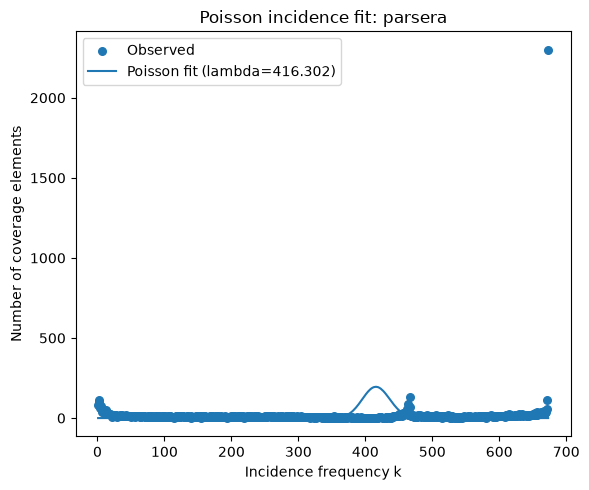

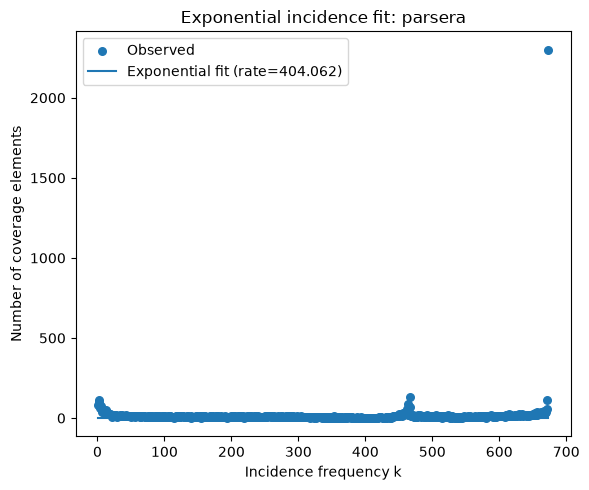

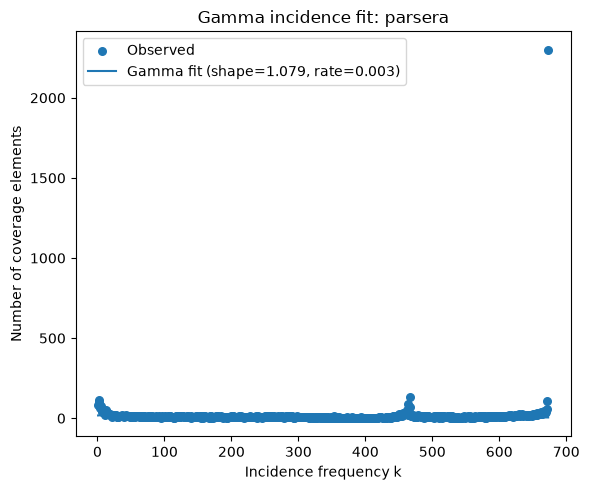

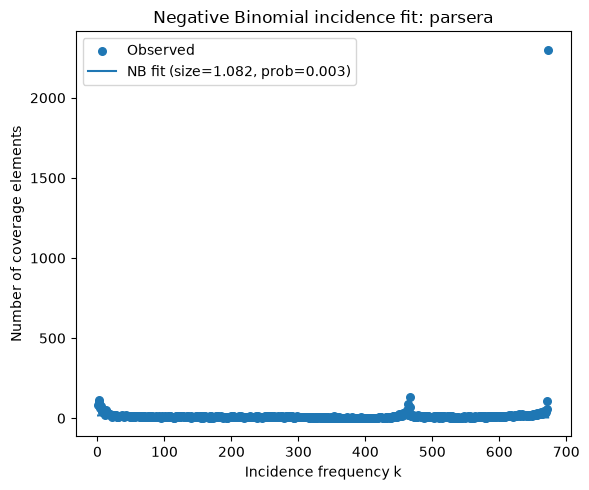

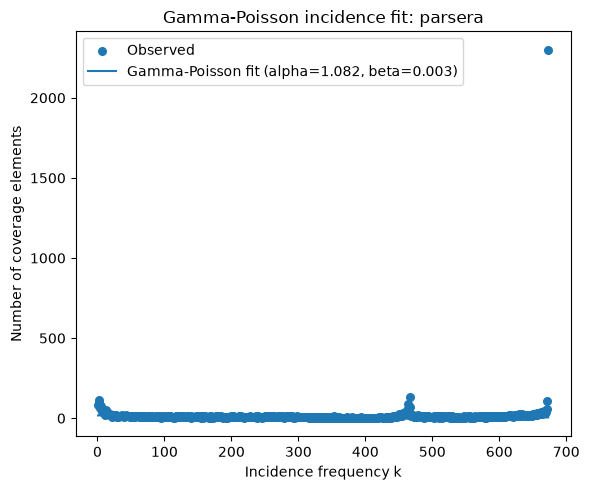

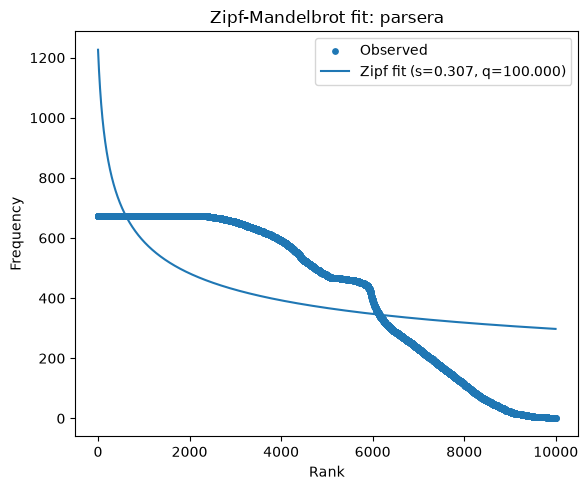

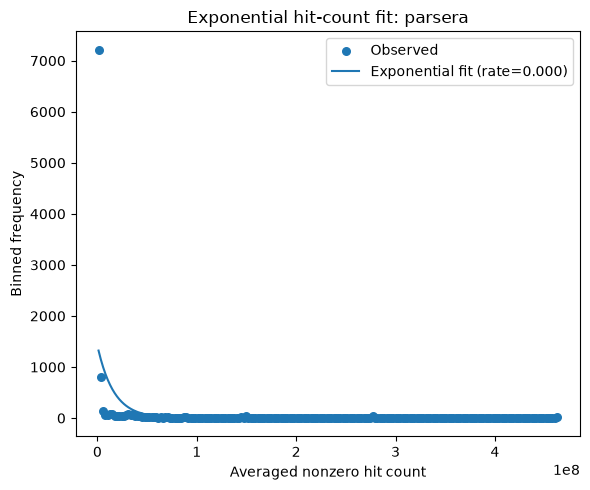

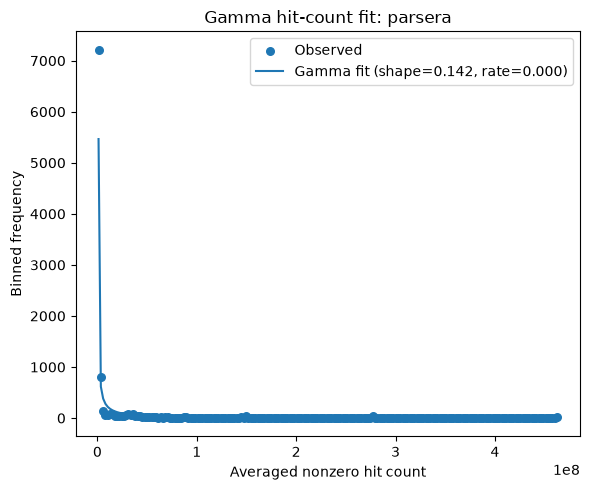

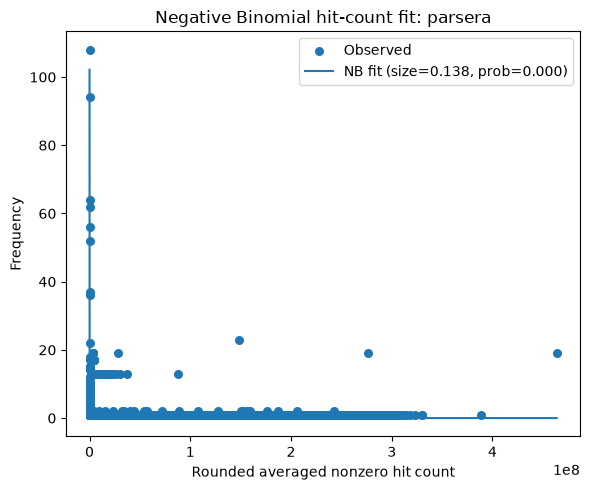

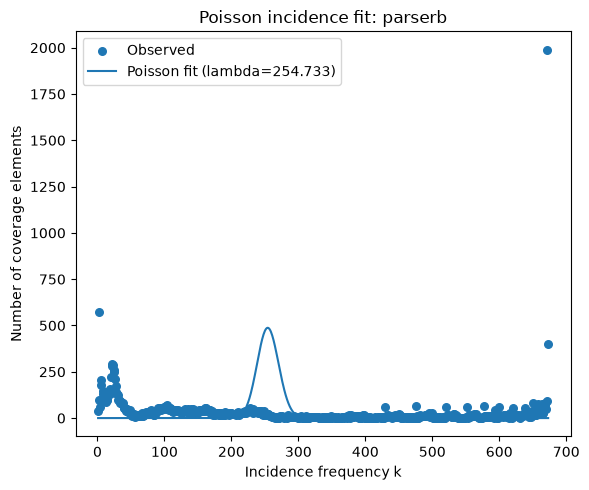

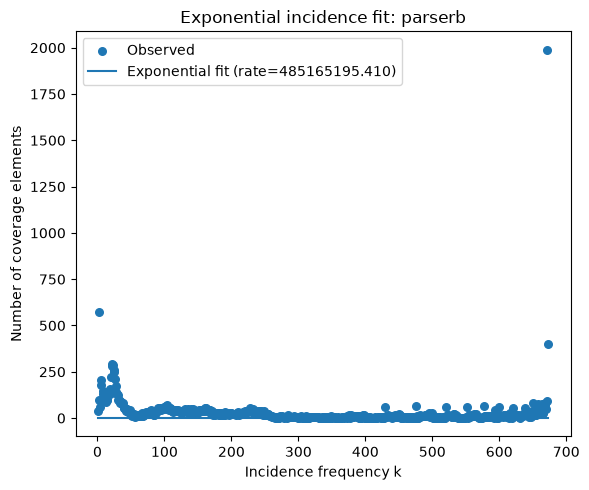

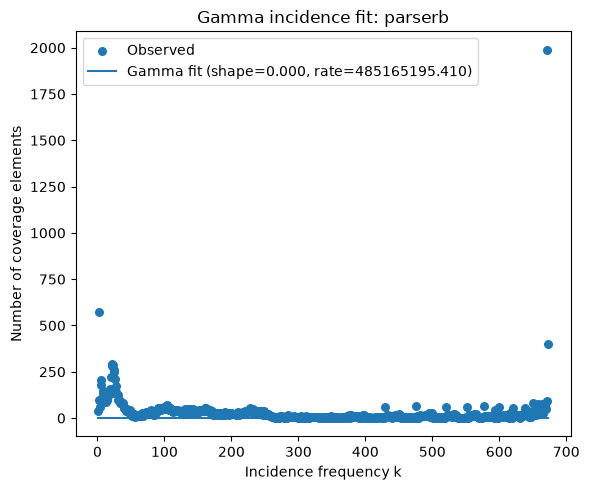

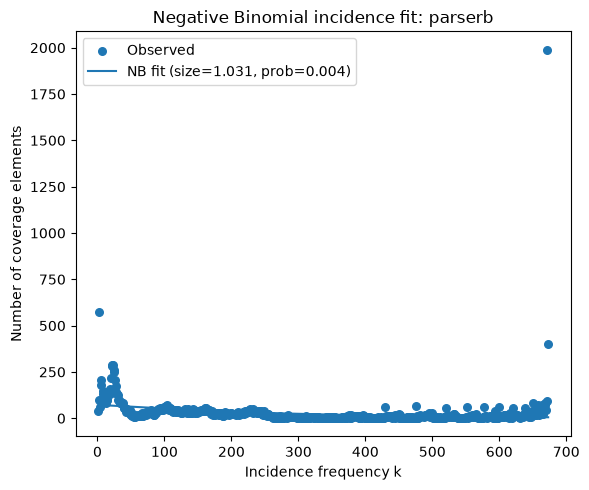

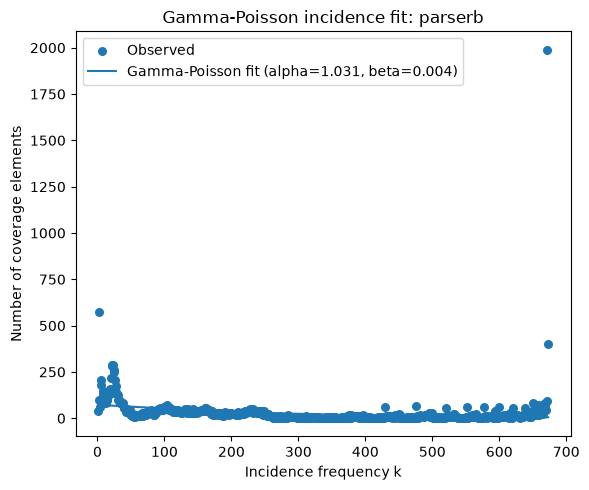

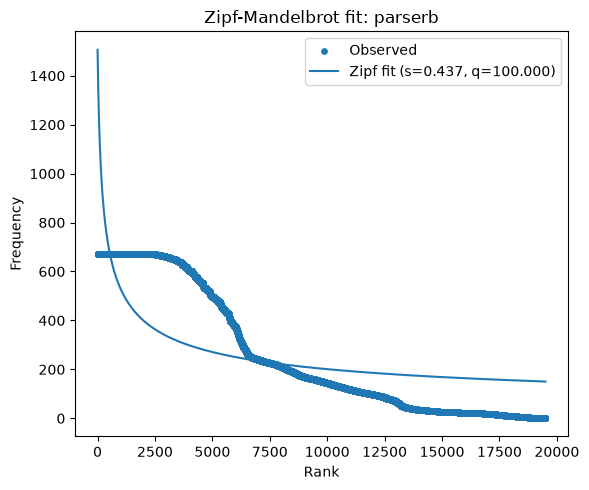

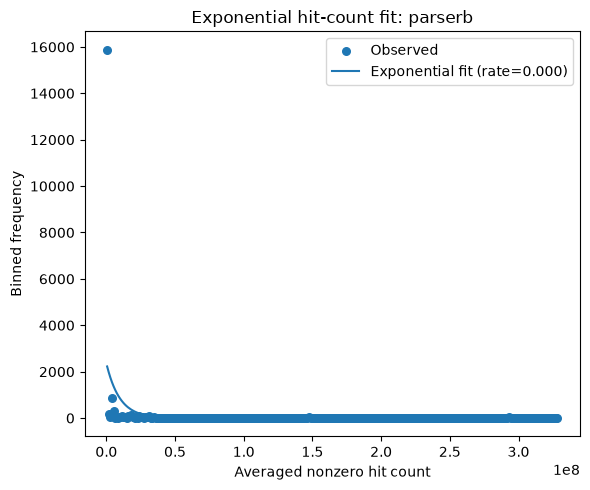

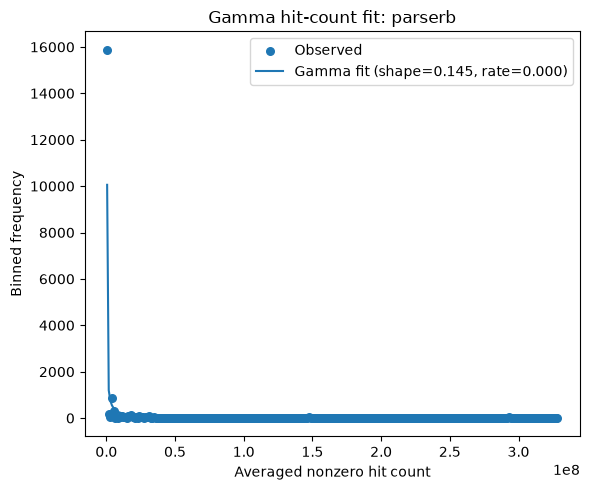

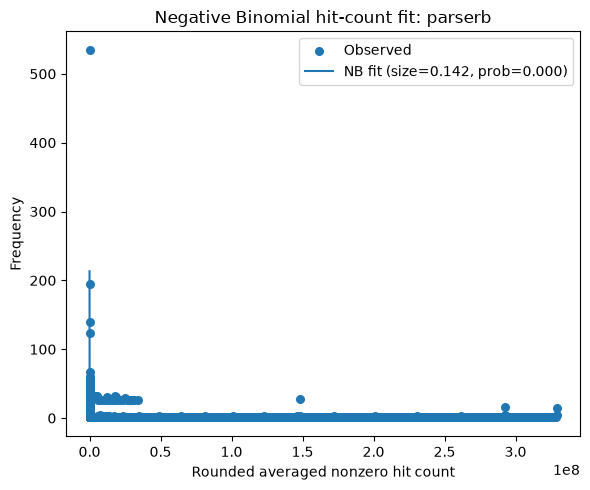

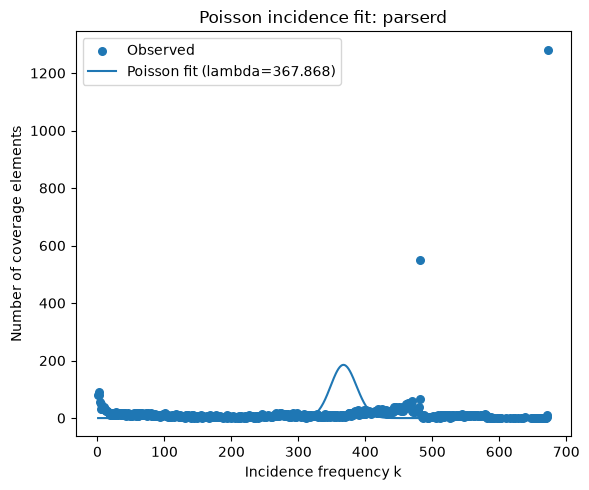

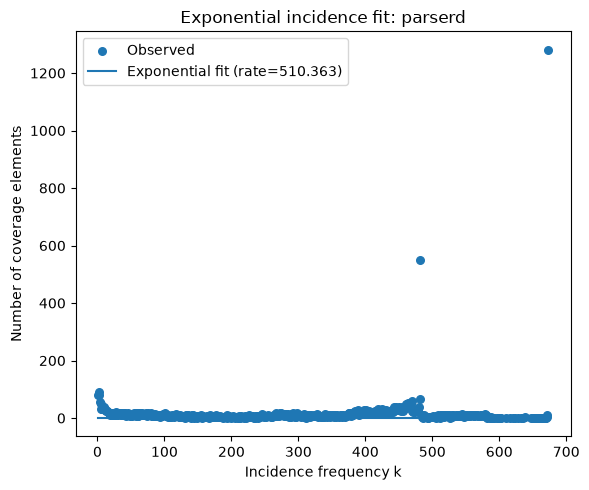

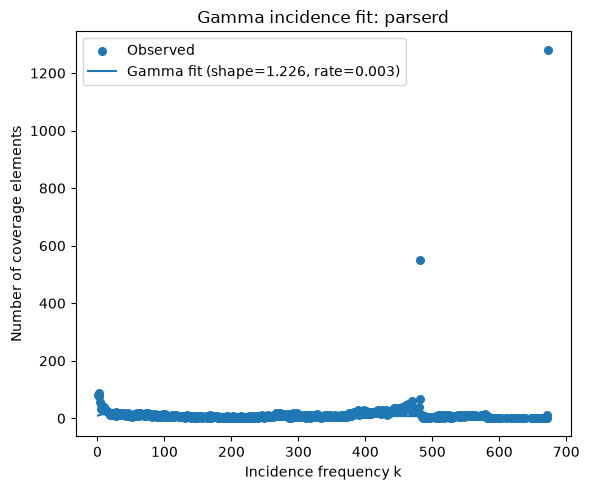

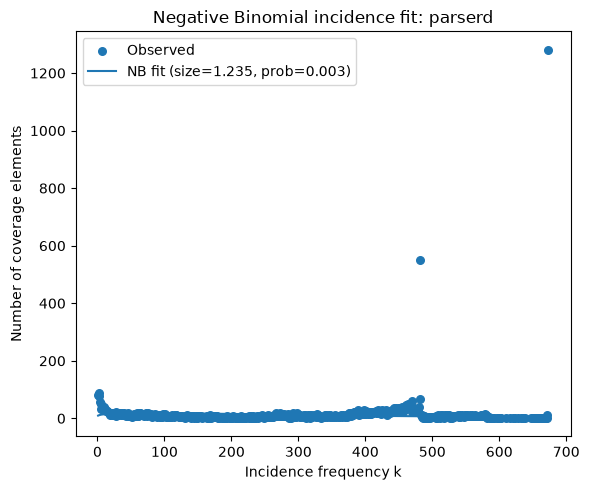

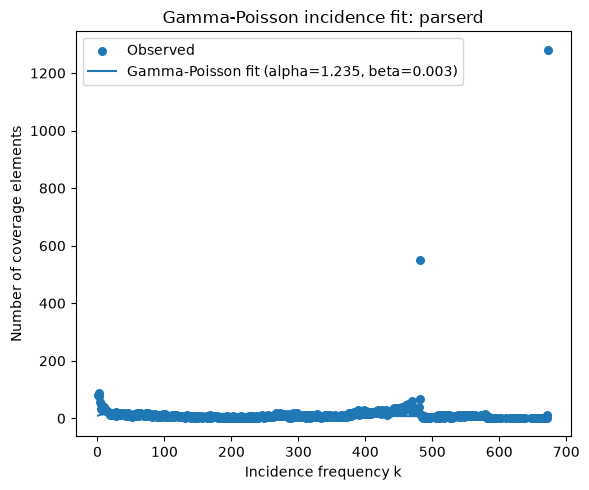

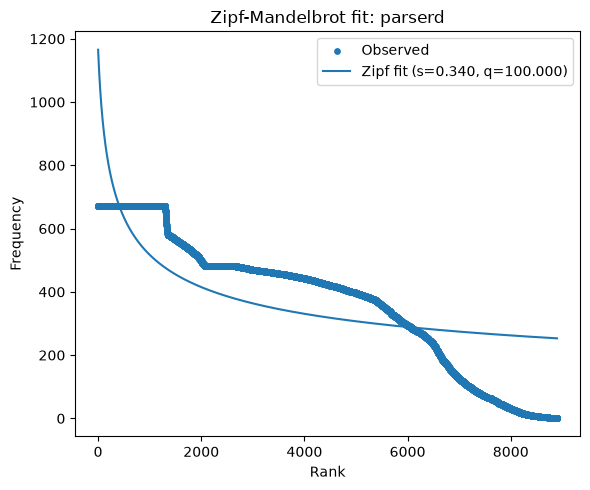

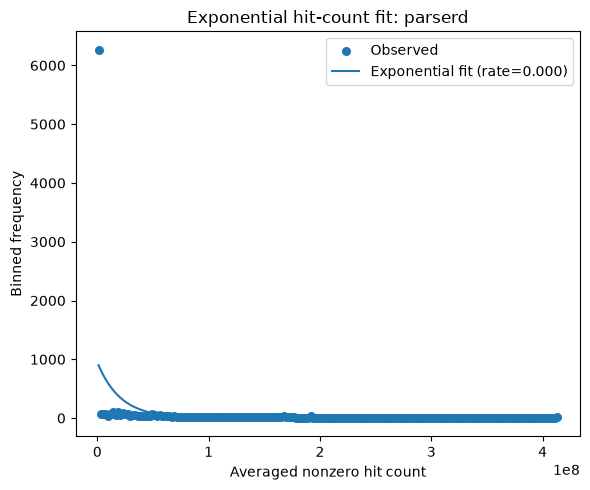

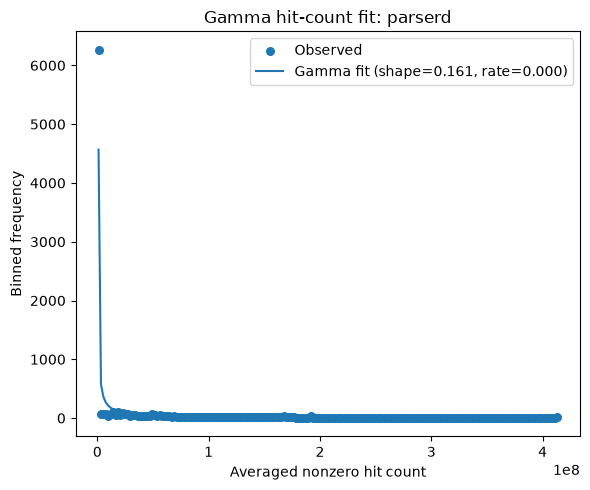

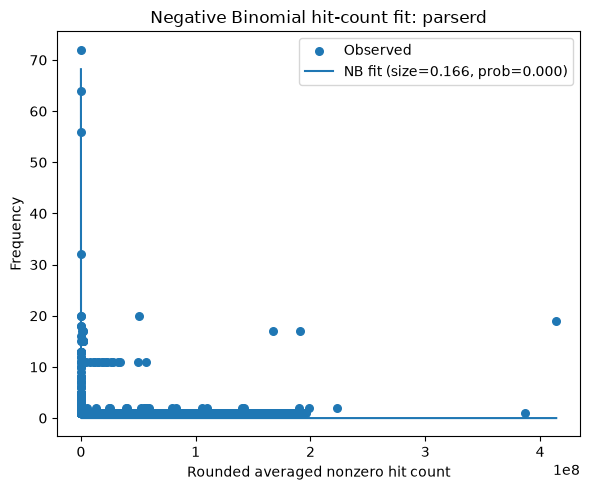

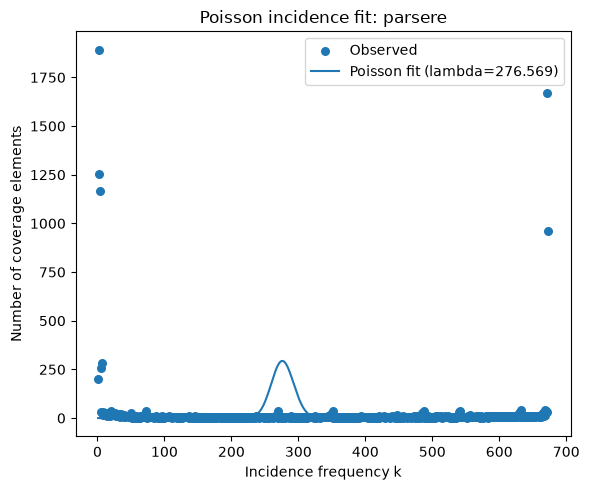

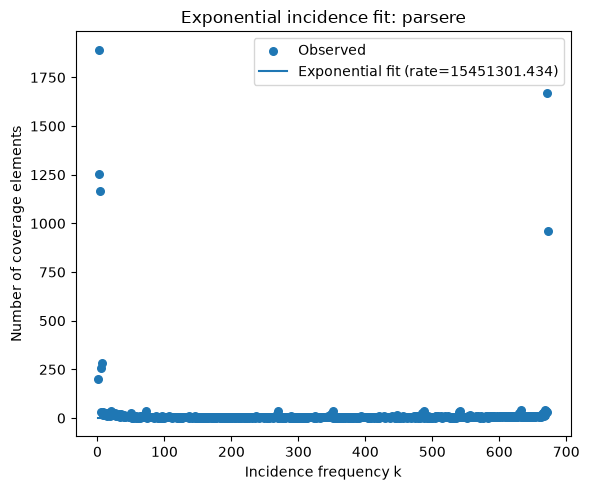

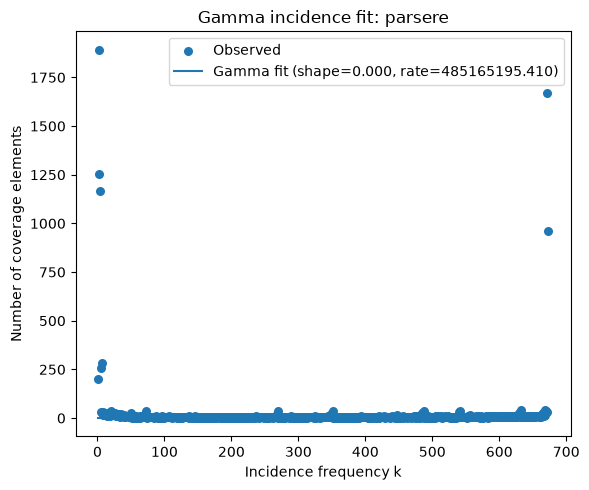

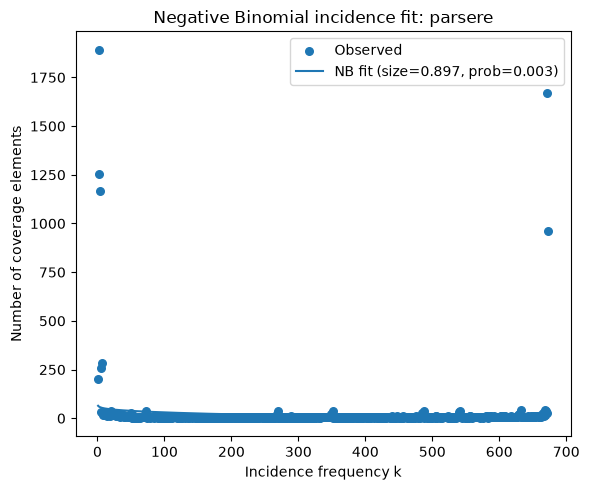

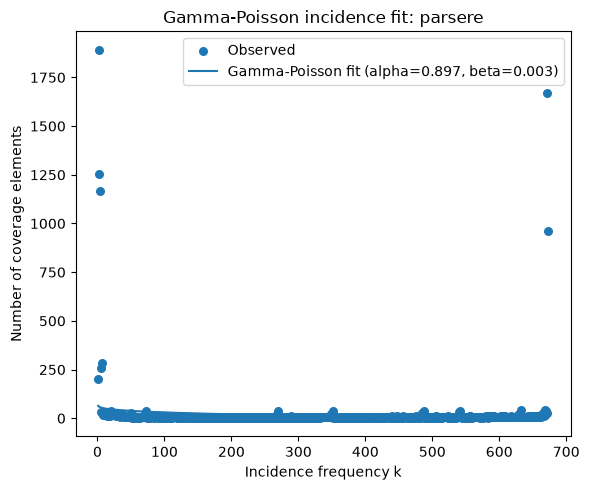

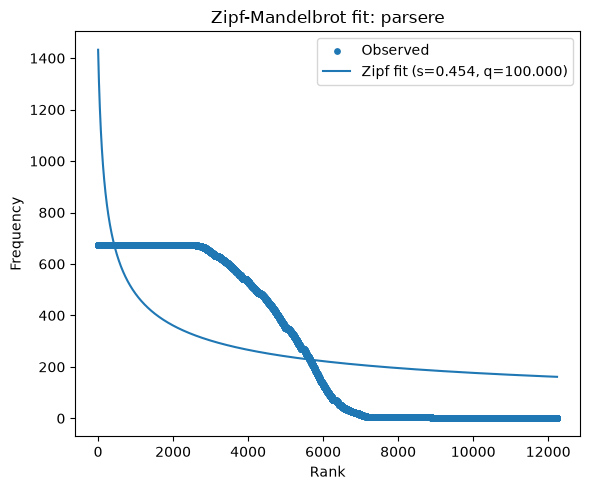

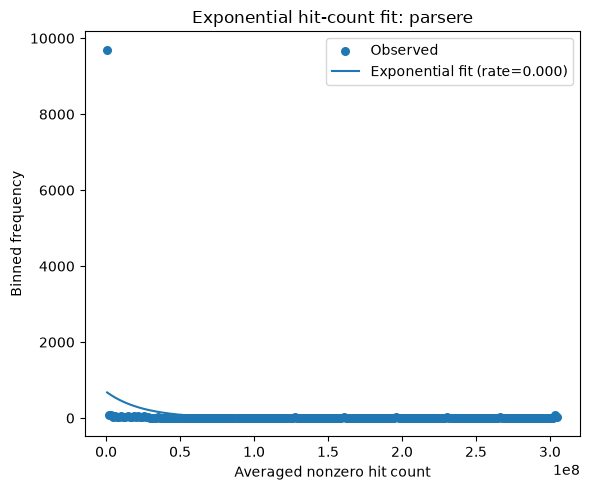

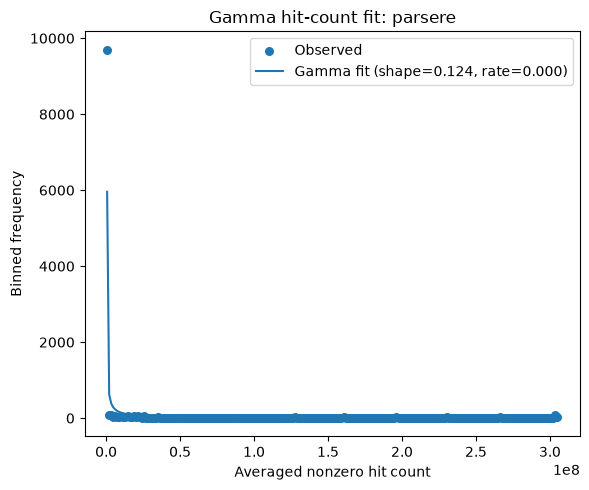

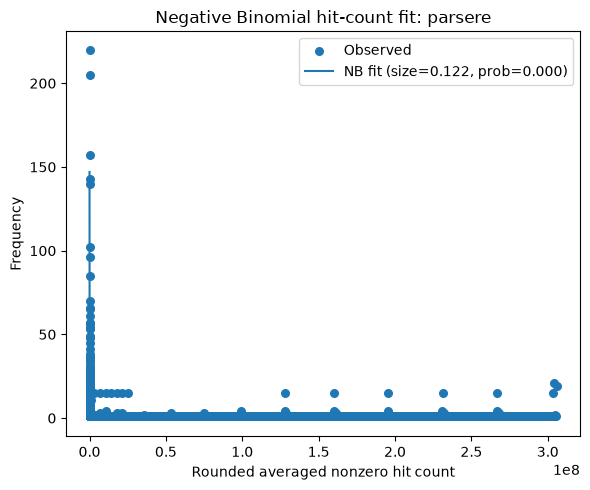

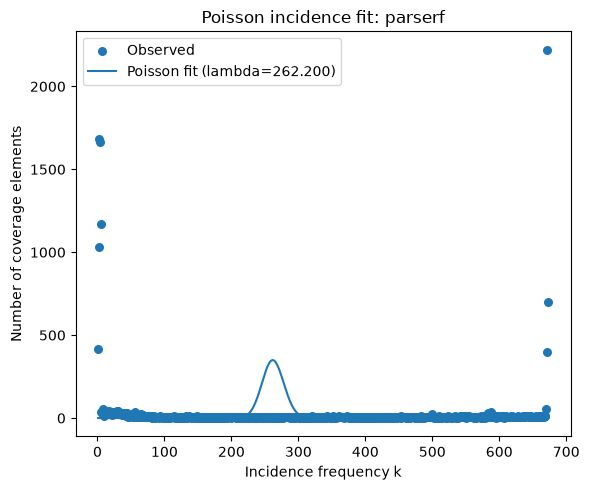

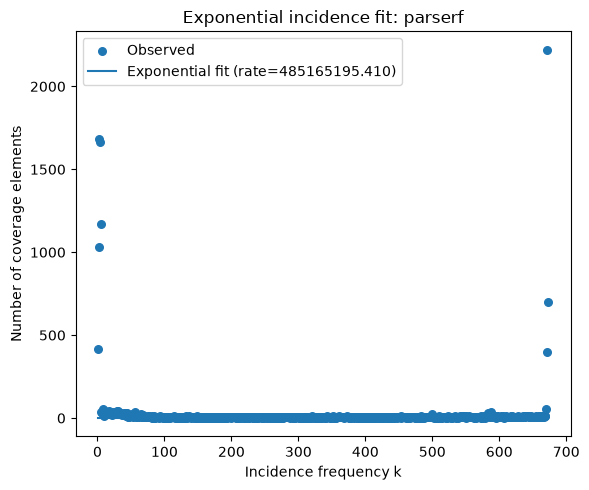

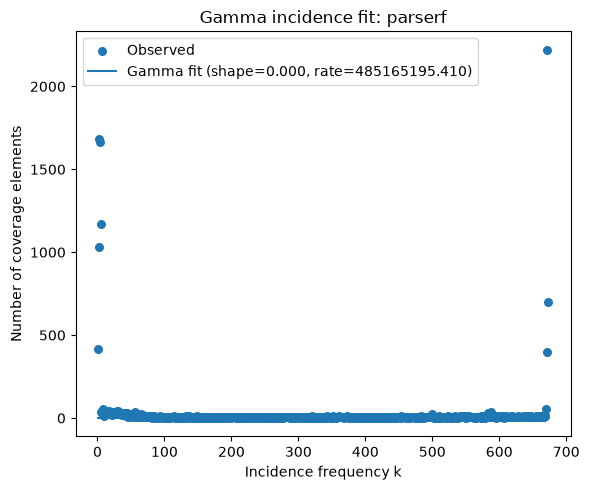

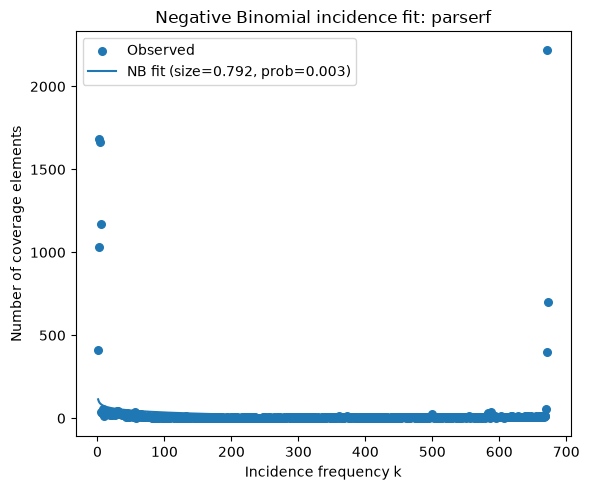

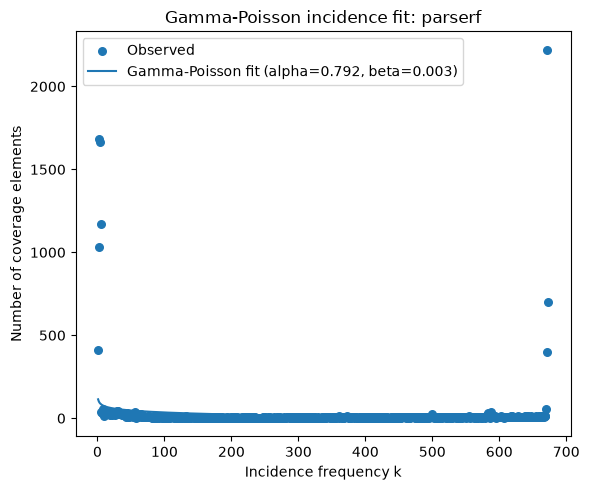

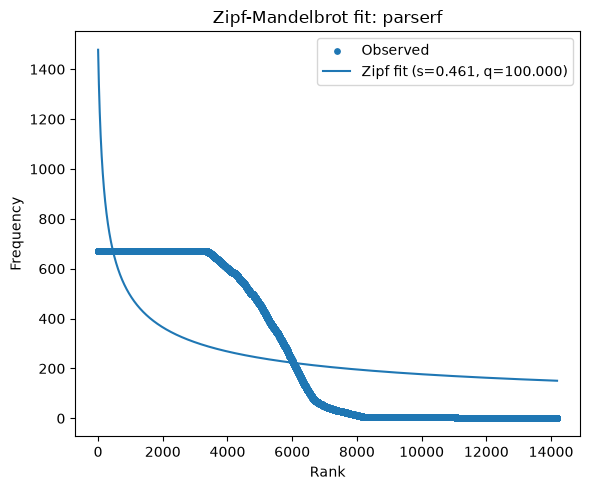

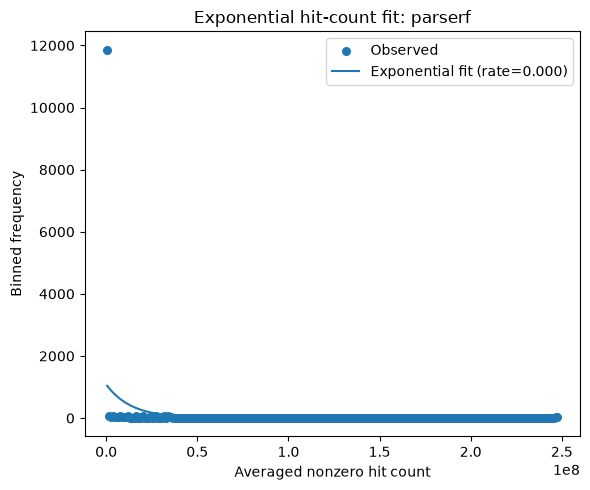

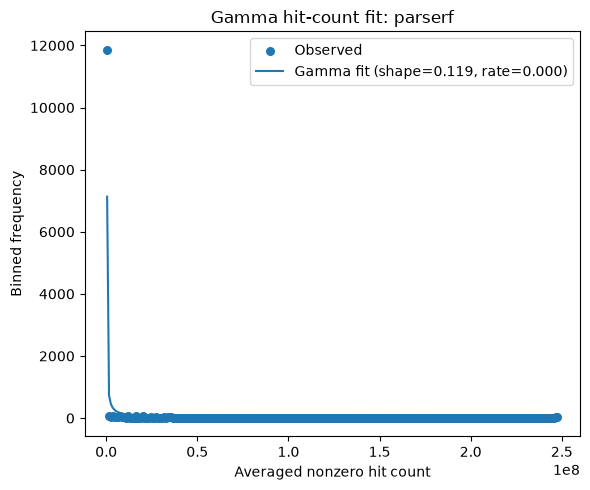

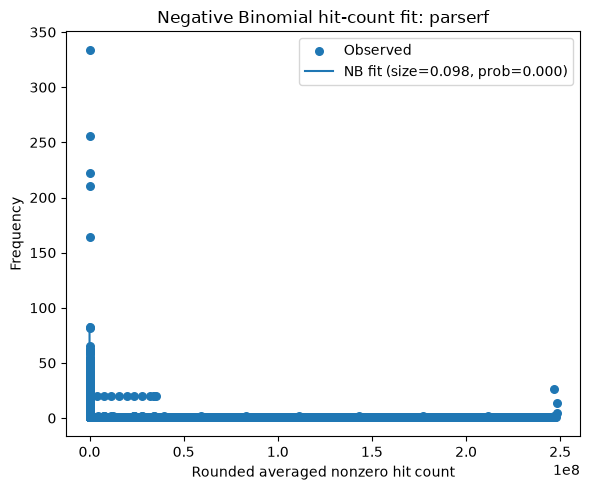

In [72]:

# Example plots for all subjects
for subject, payload in sorted(subject_artifacts.items()):
    incidence = np.asarray(payload["incidence"], dtype=np.float32)
    final_hit_count = np.asarray(payload["final_hit_count"], dtype=np.float32)

    # incidence-frequency fits
    plot_poisson_fit(subject, incidence)
    plot_exponential_incidence_fit(subject, incidence)
    plot_gamma_incidence_fit(subject, incidence)
    plot_nb_incidence_fit(subject, incidence)
    plot_gamma_poisson_fit(subject, incidence)

    # zipf on coverage-frequency
    plot_zipf_fit(subject, np.asarray(payload["incidence"], dtype=float).sum(axis=0))

    # hit-count fits
    plot_exponential_fit(subject, final_hit_count)
    plot_gamma_fit(subject, final_hit_count)
    plot_nb_fit(subject, final_hit_count)


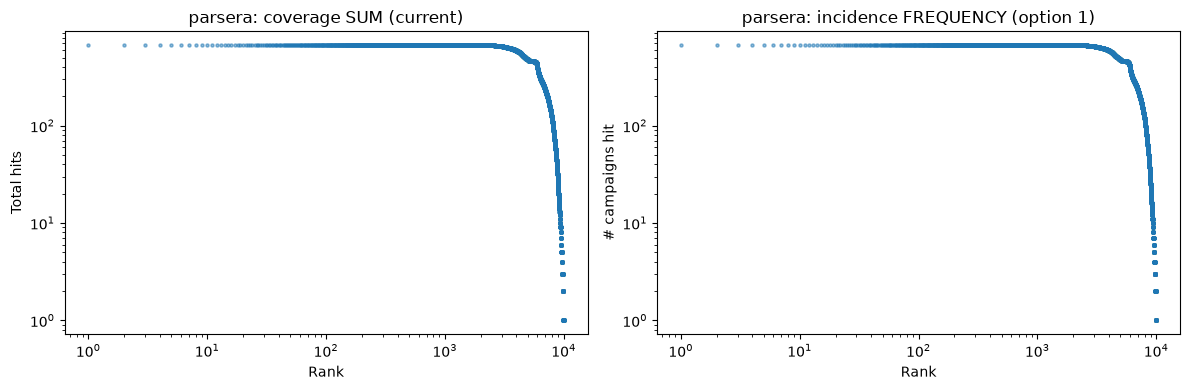

parsera: t=673 campaigns, inc_freq range=[1, 673], col_sum range=[1, 673]


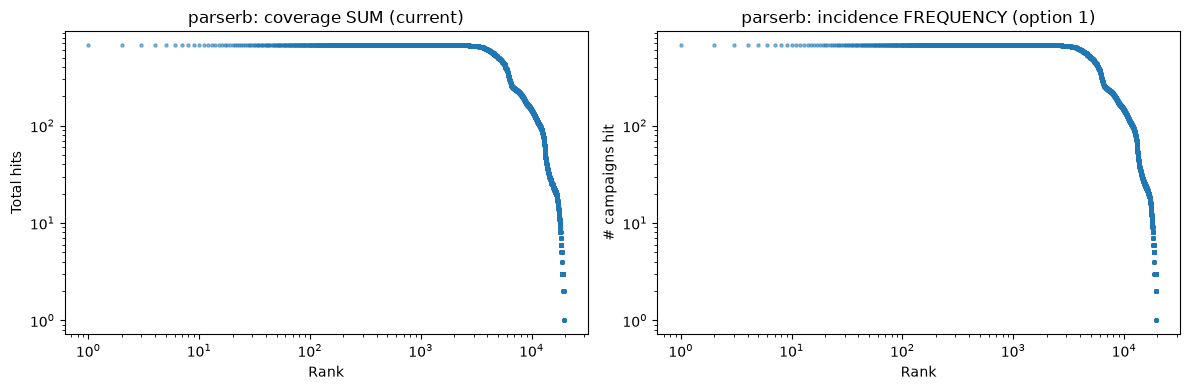

parserb: t=673 campaigns, inc_freq range=[1, 673], col_sum range=[1, 673]


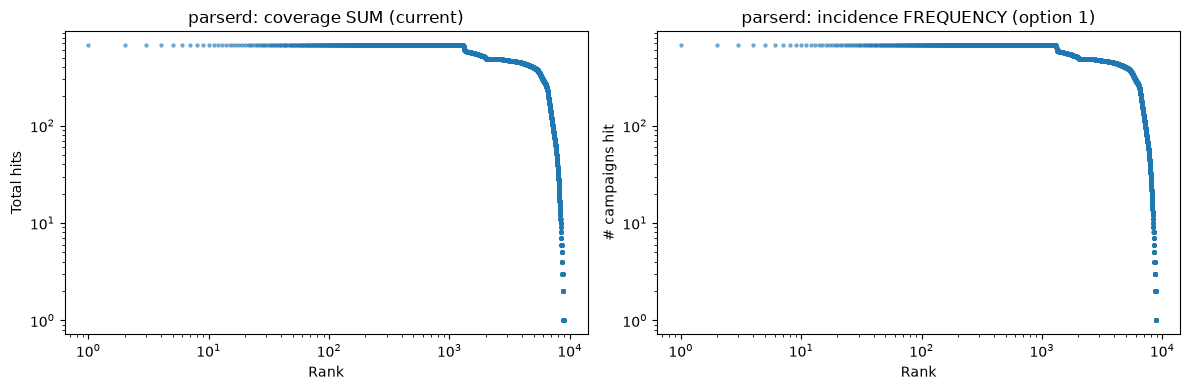

parserd: t=673 campaigns, inc_freq range=[1, 673], col_sum range=[1, 673]


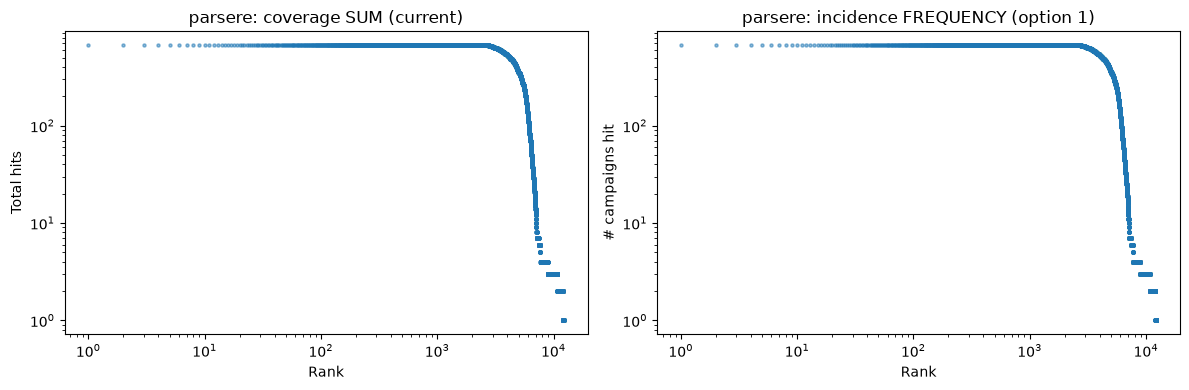

parsere: t=673 campaigns, inc_freq range=[1, 673], col_sum range=[1, 673]


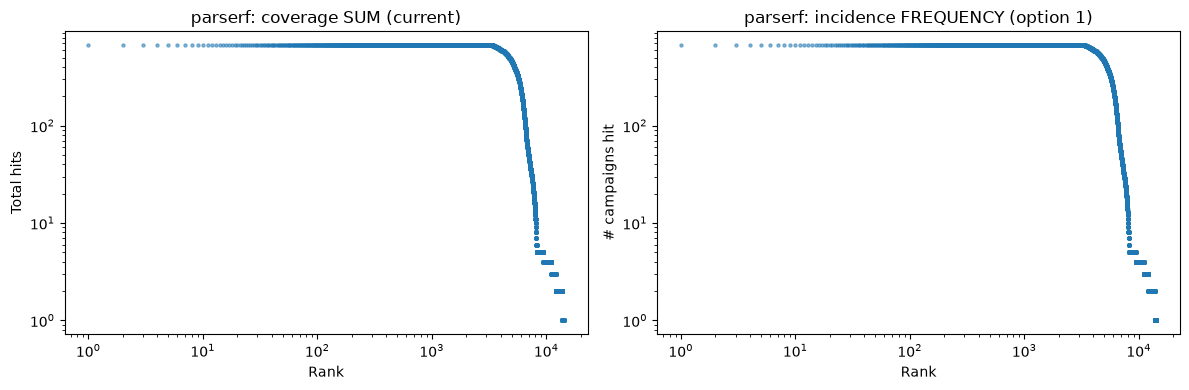

parserf: t=673 campaigns, inc_freq range=[1, 673], col_sum range=[1, 673]


In [73]:
import matplotlib.pyplot as plt
import numpy as np

for subject, payload in sorted(subject_artifacts.items()):
    incidence_mat = np.asarray(payload["incidence"], dtype=float)
    
    # What you currently use (column-sum = total hits)
    col_sums = incidence_mat.sum(axis=0)
    col_sums = col_sums[col_sums > 0]
    
    # Alternative: incidence frequency (number of campaigns each block appeared in)
    inc_freq = (incidence_mat > 0).sum(axis=0).astype(float)
    inc_freq = inc_freq[inc_freq > 0]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Current: coverage sum
    sorted_sums = np.sort(col_sums)[::-1]
    axes[0].scatter(np.arange(1, len(sorted_sums)+1), sorted_sums, s=5, alpha=0.5)
    axes[0].set_xscale("log"); axes[0].set_yscale("log")
    axes[0].set_title(f"{subject}: coverage SUM (current)")
    axes[0].set_xlabel("Rank"); axes[0].set_ylabel("Total hits")
    
    # Option 1: incidence frequency
    sorted_freq = np.sort(inc_freq)[::-1]
    axes[1].scatter(np.arange(1, len(sorted_freq)+1), sorted_freq, s=5, alpha=0.5)
    axes[1].set_xscale("log"); axes[1].set_yscale("log")
    axes[1].set_title(f"{subject}: incidence FREQUENCY (option 1)")
    axes[1].set_xlabel("Rank"); axes[1].set_ylabel("# campaigns hit")
    
    plt.tight_layout()
    plt.show()
    
    # Print the range to understand the data
    t = incidence_mat.shape[0]
    print(f"{subject}: t={t} campaigns, "
          f"inc_freq range=[{int(inc_freq.min())}, {int(inc_freq.max())}], "
          f"col_sum range=[{col_sums.min():.0f}, {col_sums.max():.0f}]")

In [74]:
# ============================================================
# Estimators
# ============================================================

def estimate_chao2(incidence_matrix: np.ndarray) -> Dict[str, float]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    S_obs = int(np.sum(q > 0))
    if t <= 1:
        return {"estimate": float(S_obs), "S_obs": S_obs, "F1": F1, "F2": F2, "t": t}
    if F2 > 0:
        est = S_obs + ((t - 1) / t) * (F1 * F1) / (2.0 * F2)
    else:
        est = S_obs + ((t - 1) / t) * F1 * (F1 - 1) / 2.0
    return {"estimate": float(est), "S_obs": S_obs, "F1": F1, "F2": F2, "t": t}

def estimate_chao2_bc(incidence_matrix: np.ndarray) -> Dict[str, float]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    S_obs = int(np.sum(q > 0))
    if t <= 1:
        return {"estimate": float(S_obs), "S_obs": S_obs, "F1": F1, "F2": F2, "t": t}
    if F2 > 0:
        est = S_obs + ((t - 1) / t) * F1 * (F1 - 1) / (2.0 * (F2 + 1.0))
    else:
        est = S_obs + ((t - 1) / t) * F1 * (F1 - 1) / 2.0
    return {"estimate": float(est), "S_obs": S_obs, "F1": F1, "F2": F2, "t": t}

def estimate_jackknife1(incidence_matrix: np.ndarray) -> Dict[str, float]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    S_obs = int(np.sum(q > 0))
    est = S_obs if t <= 1 else S_obs + F1 * (t - 1) / t
    return {"estimate": float(est), "S_obs": S_obs, "F1": F1, "F2": F2, "t": t}

def estimate_chao1(incidence_matrix: np.ndarray) -> Dict[str, float]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    S_obs = int(np.sum(q > 0))
    # Chao1 (Chao 1984): Ŝ = S_obs + F1²/(2*F2) when F2 > 0
    # Fallback when F2 == 0: Ŝ = S_obs + F1*(F1-1)/2
    if F2 > 0:
        est = float(S_obs + (F1 ** 2) / (2 * F2))
    else:
        est = float(S_obs + (F1 * (F1 - 1)) / 2)
    return {"estimate": float(est), "S_obs": S_obs, "F1": F1, "F2": F2, "t": t}

def estimate_lanumteang_bohning(incidence_matrix: np.ndarray) -> Dict[str, float]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    S_obs = int(np.sum(q > 0))
    F3 = int(np.sum(q == 3))
    if F2 == 0:
        return {"estimate": float(S_obs), "S_obs": S_obs, "F1": F1, "F2": F2, "F3": F3, "t": t}
    est = float(S_obs + (3.0 * (F1 ** 3) * F3) / (4.0 * (F2 ** 3)))
    return {"estimate": est, "S_obs": S_obs, "F1": F1, "F2": F2, "F3": F3, "t": t}

def estimate_chiu(incidence_matrix: np.ndarray) -> Dict[str, float]:
    t, F1, F2, q = incidence_frequency_counts(incidence_matrix)
    S_obs = int(np.sum(q > 0))
    F3 = int(np.sum(q == 3))
    F1_p, F2_p, F3_p = max(1, F1), max(1, F2), max(1, F3)
    if F2 > 0:
        f0_hat = F1 / (2.0 * F2)
    else:
        f0_hat = (F1 * (F1 - 1)) / (2.0 * (F2 + 1))
    ratio = (2.0 * F2_p * F2_p) / (3.0 * F1_p * F3_p)
    clipped = min(max(0.5, ratio), 1.0)
    S_hat = S_obs + f0_hat * (2.0 - clipped)
    return {"estimate": float(S_hat), "S_obs": S_obs, "F1": F1, "F2": F2, "F3": F3, "t": t}

def estimate_poisson_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_poisson_incidence_model(incidence_matrix)
    obs = _positive_incidence_counts(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "lambda": float(fit["lambda"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Incidence-frequency Poisson estimator.",
    }

def estimate_exponential_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_exponential_incidence_model(incidence_matrix)
    obs = _positive_incidence_counts(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "rate": float(fit["rate"]),
        "scale": float(fit["scale"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Incidence-frequency discretized Exponential estimator.",
    }

def estimate_gamma_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_gamma_incidence_model(incidence_matrix)
    obs = _positive_incidence_counts(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "shape": float(fit["shape"]),
        "scale": float(fit["scale"]),
        "rate": float(fit["rate"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Incidence-frequency discretized Gamma estimator.",
    }

def estimate_nb_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_nb_incidence_model(incidence_matrix)
    obs = _positive_incidence_counts(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "size": float(fit["size"]),
        "prob": float(fit["prob"]),
        "mean": float(fit["mean"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Incidence-frequency Negative Binomial estimator.",
    }



def estimate_poisson_hitcount_from_fit(final_hit_count: np.ndarray) -> Dict[str, float]:
    x_avg = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_poisson_hitcount_model(x_avg)
    S_obs = int(observed_species_from_counts(final_hit_count))
    if not fit:
        return {"estimate": float(S_obs), "S_obs": S_obs}

    lam = float(fit["lambda"])
    p0 = float(math.exp(-lam))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)
    return {
        "estimate": S_hat,
        "S_obs": S_obs,
        "lambda": lam,
        "p0": p0,
        "p_seen": p_seen,
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Hit-count Poisson estimator from nonzero averaged hit-count fit.",
    }


def estimate_exponential_hitcount_from_fit(final_hit_count: np.ndarray) -> Dict[str, float]:
    x_avg = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_exponential_hitcount_model(x_avg)
    S_obs = int(observed_species_from_counts(final_hit_count))
    if not fit:
        return {"estimate": float(S_obs), "S_obs": S_obs}

    rate = float(fit["rate"])
    scale = float(1.0 / rate)
    p0 = float(sp_expon.cdf(1.0, loc=0.0, scale=scale) - sp_expon.cdf(0.0, loc=0.0, scale=scale))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)
    return {
        "estimate": S_hat,
        "S_obs": S_obs,
        "rate": rate,
        "scale": scale,
        "mean": float(scale),
        "p0": p0,
        "p_seen": p_seen,
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Hit-count discretized Exponential estimator from nonzero averaged hit-count fit.",
    }


def estimate_gamma_hitcount_from_fit(final_hit_count: np.ndarray) -> Dict[str, float]:
    x_avg = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_gamma_hitcount_model(x_avg)
    S_obs = int(observed_species_from_counts(final_hit_count))
    if not fit:
        return {"estimate": float(S_obs), "S_obs": S_obs}

    shape = float(fit["shape"])
    scale = float(fit["scale"])
    rate = float(fit["rate"])
    p0 = float(sp_gamma.cdf(1.0, a=shape, loc=0.0, scale=scale) - sp_gamma.cdf(0.0, a=shape, loc=0.0, scale=scale))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)
    return {
        "estimate": S_hat,
        "S_obs": S_obs,
        "shape": shape,
        "scale": scale,
        "rate": rate,
        "mean": float(fit.get("mean", shape * scale)),
        "p0": p0,
        "p_seen": p_seen,
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Hit-count discretized Gamma estimator from nonzero averaged hit-count fit.",
    }


def estimate_nb_hitcount_from_fit(final_hit_count: np.ndarray) -> Dict[str, float]:
    x_avg = subject_average_nonzero_hit_counts_from_artifact(final_hit_count)
    fit = fit_nb_hitcount_model(x_avg)
    S_obs = int(observed_species_from_counts(final_hit_count))
    if not fit:
        return {"estimate": float(S_obs), "S_obs": S_obs}

    size = float(fit["size"])
    prob = float(fit["prob"])
    p0 = float(sp_nbinom.pmf(0, n=size, p=prob))
    p_seen = float(max(1.0 - p0, 1e-12))
    S_hat = float(S_obs / p_seen)
    return {
        "estimate": S_hat,
        "S_obs": S_obs,
        "size": size,
        "prob": prob,
        "mean": float(fit.get("mu", np.nan)),
        "p0": p0,
        "p_seen": p_seen,
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Hit-count Negative Binomial estimator from nonzero averaged hit-count fit.",
    }

def estimate_ztpoisson_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_poisson_incidence_model(incidence_matrix)
    obs = observed_incidence_sample(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "lambda": float(fit["lambda"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Zero-truncated Poisson-style estimator from fitted Poisson incidence model.",
    }

def estimate_ztnb_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_nb_incidence_model(incidence_matrix)
    obs = observed_incidence_sample(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "size": float(fit["size"]),
        "prob": float(fit["prob"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Zero-truncated Negative Binomial-style estimator from fitted incidence model.",
    }

def estimate_gamma_poisson_from_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    fit = fit_gamma_poisson_incidence_model(incidence_matrix)
    obs = observed_incidence_sample(incidence_matrix)
    if not fit:
        return {"estimate": float(obs["S_obs"]), "S_obs": int(obs["S_obs"])}
    return {
        "estimate": float(fit["estimate"]),
        "S_obs": int(fit["S_obs"]),
        "F1": int(obs["F1"]),
        "F2": int(obs["F2"]),
        "t": int(obs["t"]),
        "shape": float(fit["shape"]),
        "rate": float(fit["rate"]),
        "scale": float(fit["scale"]),
        "p0": float(fit["p0"]),
        "p_seen": float(fit["p_seen"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Gamma-Poisson estimator from incidence-frequency fit.",
    }

def find_S_threshold(J, s, q, max_search=100000):
    for S in range(1, max_search):
        ranks = np.arange(1, S + 1)
        weights = (ranks + q) ** (-s)
        C = 1.0 / np.sum(weights)
        n_S = J * C * (S + q) ** (-s)
        if n_S < 1:
            return S - 1
    return None

def abundance_at(rank: int, J: float, s: float, q: float, S: int) -> float:
    ranks = np.arange(1, S + 1)
    weights = (ranks + q) ** (-s)
    C = 1.0 / np.sum(weights)
    return float(J * C * (rank + q) ** (-s))

def estimate_zipf_mandelbrot(incidence_matrix: np.ndarray) -> Dict[str, float]:
    # sum across intervals (axis=0) to get per-block (per-element) incidence counts
    counts = np.asarray(incidence_matrix, dtype=float).sum(axis=0)
    counts = counts[np.isfinite(counts)]
    counts = counts[counts > 0]
    if len(counts) == 0:
        return {"estimate": 0.0, "S_obs": 0}

    S_obs = int(len(counts))
    fit = fit_zipf_mandelbrot_model(counts)
    if not fit:
        return {"estimate": float(S_obs), "S_obs": S_obs}

    S_hat = find_S_threshold(fit["J"], fit["s"], fit["q"])
    if S_hat is None:
        S_hat = S_obs

    return {
        "estimate": float(S_hat),
        "S_obs": S_obs,
        "J": float(fit["J"]),
        "s": float(fit["s"]),
        "q": float(fit["q"]),
        "loglik": float(fit["loglik"]),
        "aic": float(fit["aic"]),
        "bic": float(fit["bic"]),
        "rmse": float(fit["rmse"]),
        "method_note": "Zipf-Mandelbrot estimator on coverage-frequency rank data.",
    }


def estimate_beta_binomial_from_gp_fit(incidence_matrix: np.ndarray) -> Dict[str, float]:
    """
    Beta-Binomial species richness estimator (Chiu, 2022, Eq. 7).

    Parameters are derived from the Gamma-Poisson (GP) incidence fit via the
    canonical moment-matching bridge:
        alpha_BB = alpha_GP  (GP shape parameter)
        beta_BB  = beta_GP * T  (GP rate * number of sampling units)

    This maps Gamma(alpha, rate) on detection counts to Beta(alpha, beta*T) on
    detection probabilities (pi = lambda / T), preserving the mean and
    overdispersion structure.

    The estimator itself follows Chiu (2022) Eq. 7:
        S_BB = S_obs + Q0_Chao2 * (2 - F)
    where Q0_Chao2 is the Chao2-based undetected richness and
        F = max(1/2, min(2*Q2^2 / (3*Q1*Q3), 1))

    Additionally, the Beta-Binomial p0 (probability that a species appears in
    zero sampling units) is computed from the BB parameters for reference:
        p0_BB = B(alpha_BB, beta_BB + T) / B(alpha_BB, beta_BB)
    """
    gp_fit = fit_gamma_poisson_incidence_model(incidence_matrix)
    obs = observed_incidence_sample(incidence_matrix)

    S_obs = int(obs["S_obs"])
    t = int(obs["t"])
    F1 = int(obs["F1"])
    F2 = int(obs["F2"])
    q = obs["q"]
    F3 = int(np.sum(np.asarray(q) == 3))

    if not gp_fit or t < 1:
        return {"estimate": float(S_obs), "S_obs": S_obs, "F1": F1, "F2": F2, "F3": F3, "t": t}

    alpha_gp = float(gp_fit["shape"])
    beta_gp  = float(gp_fit["rate"])   # rate parameter

    # ── Parameter bridge: Gamma(alpha, rate) -> Beta(alpha, rate*T) ──────────
    alpha_bb = alpha_gp
    beta_bb  = beta_gp * t

    # ── Beta-Binomial p0: P(Y_i = 0 | T, alpha_bb, beta_bb) ─────────────────
    #   = B(alpha_bb, beta_bb + T) / B(alpha_bb, beta_bb)
    #   = exp( lgamma(alpha_bb+beta_bb) + lgamma(beta_bb+T)
    #          - lgamma(beta_bb) - lgamma(alpha_bb+beta_bb+T) )
    try:
        log_p0_bb = (
            gammaln(alpha_bb + beta_bb) + gammaln(beta_bb + t)
            - gammaln(beta_bb) - gammaln(alpha_bb + beta_bb + t)
        )
        p0_bb = float(math.exp(log_p0_bb))
    except Exception:
        p0_bb = float(gp_fit.get("p0", 0.0))

    p0_bb = float(np.clip(p0_bb, 0.0, 1.0 - 1e-12))

    # ── Chiu (2022) Eq. 7 ────────────────────────────────────────────────────
    # Q0_Chao2: Chao2-style estimate of undetected richness
    if F2 > 0:
        Q0_Chao2 = float((t - 1) / t * F1 ** 2 / (2.0 * F2))
    else:
        Q0_Chao2 = float((t - 1) / t * F1 * (F1 - 1) / 2.0)

    # F: bias-correction factor using tripletons
    Q1_eff = max(F1, 1)
    Q2_eff = max(F2, 1)
    Q3_eff = max(F3, 1)
    ratio = (2.0 * Q2_eff ** 2) / (3.0 * Q1_eff * Q3_eff)
    F_val = float(max(0.5, min(ratio, 1.0)))

    S_hat = float(S_obs + Q0_Chao2 * (2.0 - F_val))

    return {
        "estimate": S_hat,
        "S_obs": S_obs,
        "F1": F1,
        "F2": F2,
        "F3": F3,
        "t": t,
        "alpha_bb": alpha_bb,
        "beta_bb": beta_bb,
        "alpha_gp": alpha_gp,
        "beta_gp": beta_gp,
        "p0": p0_bb,
        "p_seen": float(1.0 - p0_bb),
        "Q0_Chao2": Q0_Chao2,
        "F_val": F_val,
        "method_note": (
            "Beta-Binomial estimator (Chiu 2022 Eq. 7). "
            "Parameters alpha_BB=alpha_GP, beta_BB=beta_GP*T derived from Gamma-Poisson fit."
        ),
    }


In [75]:

# ============================================================
# Estimator comparison
# ============================================================

def canonical_subject_name(subject_name: str) -> str:
    subject_name = str(subject_name)
    subject_name = re.sub(r"_aflpp_run_\d+$", "", subject_name)
    subject_name = re.sub(r"_run_\d+$", "", subject_name)
    return subject_name


def explicit_estimator_label(estimator_name: str, estimator_input: str) -> str:
    base = str(estimator_name).strip()
    label_map = {
        ("Poisson", "incidence_frequency"): "Poisson (incidence-frequency estimator)",
        ("Exponential", "incidence_frequency"): "Exponential (incidence-frequency estimator)",
        ("Gamma", "incidence_frequency"): "Gamma (incidence-frequency estimator)",
        ("Negative Binomial", "incidence_frequency"): "Negative Binomial (incidence-frequency estimator)",
        ("Gamma-Poisson", "incidence_frequency"): "Gamma-Poisson (incidence-frequency estimator)",
        ("ztPoisson", "incidence_frequency"): "ztPoisson (incidence-frequency estimator)",
        ("ztNB", "incidence_frequency"): "ztNB (incidence-frequency estimator)",
        ("Zipf-Mandelbrot", "incidence_sum_axis1"): "Zipf-Mandelbrot (coverage-frequency estimator)",
        ("Poisson", "hit_count"): "Poisson (hit-count estimator)",
        ("Exponential", "hit_count"): "Exponential (hit-count estimator)",
        ("Gamma", "hit_count"): "Gamma (hit-count estimator)",
        ("Negative Binomial", "hit_count"): "Negative Binomial (hit-count estimator)",
        ("Chao2", "incidence_frequency"): "Chao2 (incidence-based)",
        ("Chao2_bc", "incidence_frequency"): "Chao2_bc (incidence-based)",
        ("Jackknife1", "incidence_frequency"): "Jackknife1 (incidence-based)",
        ("Chao1", "incidence_frequency"): "Chao1 (incidence-based)",
        ("Lanumteang-Bohning", "incidence_frequency"): "Lanumteang-Bohning (incidence-based)",
        ("Chiu", "incidence_frequency"): "Chiu (incidence-based)",
        ("Beta-Binomial", "incidence_frequency"): "Beta-Binomial (incidence-based)",
    }
    return label_map.get((base, estimator_input), f"{base} ({estimator_input})")


STANDARD_PARAMETRIC_ESTIMATORS = [
    "Poisson",
    "Exponential",
    "Gamma",
    "Negative Binomial",
    "Gamma-Poisson",
    "Zipf-Mandelbrot",
]
NON_PARAMETRIC_ESTIMATORS = ["Chao2", "Chao2_bc", "Jackknife1", "Chao1", "Lanumteang-Bohning", "Chiu", "Beta-Binomial"]
ZT_PARAMETRIC_ESTIMATORS = ["ztPoisson", "ztNB"]
HITCOUNT_PARAMETRIC_ESTIMATORS = ["Poisson", "Exponential", "Gamma", "Negative Binomial"]
PARAMETRIC_PLUS_ZT_ESTIMATORS = STANDARD_PARAMETRIC_ESTIMATORS + ZT_PARAMETRIC_ESTIMATORS


def estimator_family(estimator_name: str, estimator_input: str) -> str:
    if estimator_input == "hit_count":
        return "hit_count_parametric"
    if estimator_name in STANDARD_PARAMETRIC_ESTIMATORS:
        return "standard_parametric"
    if estimator_name in NON_PARAMETRIC_ESTIMATORS:
        return "non_parametric"
    if estimator_name in ZT_PARAMETRIC_ESTIMATORS:
        return "zero_truncated_parametric"
    return "other"


comparison_rows = []

for artifact_key, subject_payload in sorted(subject_artifacts.items()):
    metadata = subject_payload.get("metadata", {})
    subject = canonical_subject_name(metadata.get("subject", artifact_key))

    incidence = np.asarray(subject_payload["incidence"], dtype=np.float32)
    final_hit_count = np.asarray(subject_payload["final_hit_count"], dtype=np.float32)

    obs_inc = observed_incidence_sample(incidence)
    S_obs_inc = int(obs_inc["S_obs"])
    S_obs_hits = observed_species_from_counts(final_hit_count)

    has_known_total = subject in KNOWN_TOTALS
    known_total = float(KNOWN_TOTALS[subject]) if has_known_total else np.nan

    estimator_functions = [
        ("Chao2", "incidence_frequency", lambda: estimate_chao2(incidence)),
        ("Chao2_bc", "incidence_frequency", lambda: estimate_chao2_bc(incidence)),
        ("Jackknife1", "incidence_frequency", lambda: estimate_jackknife1(incidence)),
        ("Chao1", "incidence_frequency", lambda: estimate_chao1(incidence)),
        ("Poisson", "incidence_frequency", lambda: estimate_poisson_from_fit(incidence)),
        ("Exponential", "incidence_frequency", lambda: estimate_exponential_from_fit(incidence)),
        ("Gamma", "incidence_frequency", lambda: estimate_gamma_from_fit(incidence)),
        ("Negative Binomial", "incidence_frequency", lambda: estimate_nb_from_fit(incidence)),
        ("ztPoisson", "incidence_frequency", lambda: estimate_ztpoisson_from_fit(incidence)),
        ("ztNB", "incidence_frequency", lambda: estimate_ztnb_from_fit(incidence)),
        ("Gamma-Poisson", "incidence_frequency", lambda: estimate_gamma_poisson_from_fit(incidence)),
        ("Lanumteang-Bohning", "incidence_frequency", lambda: estimate_lanumteang_bohning(incidence)),
        ("Chiu", "incidence_frequency", lambda: estimate_chiu(incidence)),
        ("Beta-Binomial", "incidence_frequency", lambda: estimate_beta_binomial_from_gp_fit(incidence)),
        ("Zipf-Mandelbrot", "incidence_sum_axis1", lambda: estimate_zipf_mandelbrot(incidence)),
        ("Poisson", "hit_count", lambda: estimate_poisson_hitcount_from_fit(final_hit_count)),
        ("Exponential", "hit_count", lambda: estimate_exponential_hitcount_from_fit(final_hit_count)),
        ("Gamma", "hit_count", lambda: estimate_gamma_hitcount_from_fit(final_hit_count)),
        ("Negative Binomial", "hit_count", lambda: estimate_nb_hitcount_from_fit(final_hit_count)),
    ]

    for est_name, estimator_input, fn in estimator_functions:
        try:
            res = fn()
        except Exception as e:
            print(f"[WARN] {subject} - {est_name} ({estimator_input}) failed: {e}")
            res = {}

        if not res:
            continue

        est_total = float(res.get("estimate", np.nan))
        observed_total_for_error = S_obs_hits if estimator_input == "hit_count" else S_obs_inc
        signed_err = est_total - known_total if has_known_total and np.isfinite(est_total) else np.nan
        abs_err = abs(signed_err) if np.isfinite(signed_err) else np.nan
        rel_err = abs_err / known_total if has_known_total and known_total > 0 and np.isfinite(abs_err) else np.nan
        coverage_completion = observed_total_for_error / known_total if has_known_total and known_total > 0 else np.nan

        comparison_rows.append({
            "subject": subject,
            "artifact_key": artifact_key,
            "program_type": "synthetic" if has_known_total else "real_world",
            "has_known_total": has_known_total,
            "target_type": "known_total" if has_known_total else "unknown",
            "known_total": known_total,
            "observed_total": S_obs_inc,
            "observed_total_hitcount": S_obs_hits,
            "observed_total_for_estimator": observed_total_for_error,
            "estimate_total": est_total,
            "estimated_unseen_vs_observed": float(max(est_total - observed_total_for_error, 0.0)) if np.isfinite(est_total) else np.nan,
            "signed_error": signed_err,
            "abs_error": abs_err,
            "rel_error": rel_err,
            "coverage_completion": coverage_completion,
            "estimator": est_name,
            "estimator_input": estimator_input,
            "estimator_label": explicit_estimator_label(est_name, estimator_input),
            "n_campaigns": int(metadata.get("n_campaigns", 0)),
            "F1": res.get("F1", np.nan),
            "F2": res.get("F2", np.nan),
            "F3": res.get("F3", np.nan),
            "t": res.get("t", np.nan),
            "p0": res.get("p0", np.nan),
            "p_seen": res.get("p_seen", np.nan),
            "loglik": res.get("loglik", np.nan),
            "aic": res.get("aic", np.nan),
            "bic": res.get("bic", np.nan),
            "rmse": res.get("rmse", np.nan),
            "lambda": res.get("lambda", np.nan),
            "shape": res.get("shape", np.nan),
            "scale": res.get("scale", np.nan),
            "rate": res.get("rate", np.nan),
            "size": res.get("size", np.nan),
            "prob": res.get("prob", np.nan),
            "mean": res.get("mean", np.nan),
            "J": res.get("J", np.nan),
            "s": res.get("s", np.nan),
            "q": res.get("q", np.nan),
            "method_note": res.get("method_note", ""),
            "estimator_family": estimator_family(est_name, estimator_input),
        })

comparison_df = pd.DataFrame(comparison_rows).sort_values(["subject", "estimator_input", "estimator"]).reset_index(drop=True)

comparison_known_df = comparison_df[comparison_df["has_known_total"]].copy()
comparison_unknown_df = comparison_df[~comparison_df["has_known_total"]].copy()

display(comparison_df.head(30))


,subject,artifact_key,program_type,has_known_total,target_type,known_total,observed_total,observed_total_hitcount,observed_total_for_estimator,estimate_total,...,scale,rate,size,prob,mean,J,s,q,method_note,estimator_family
0,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,9.995001e+03,...,1.633821e+07,6.120620e-08,NaN,NaN,1.633821e+07,NaN,NaN,NaN,Hit-count discretized Exponential estimator fr...,hit_count_parametric
1,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,1.082239e+04,...,1.149699e+08,8.697930e-09,NaN,NaN,1.633821e+07,NaN,NaN,NaN,Hit-count discretized Gamma estimator from non...,hit_count_parametric
2,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,1.079249e+04,...,NaN,NaN,0.138313,6.607971e-09,2.093129e+07,NaN,NaN,NaN,Hit-count Negative Binomial estimator from non...,hit_count_parametric
3,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,9.995000e+03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit-count Poisson estimator from nonzero avera...,hit_count_parametric
4,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,1.003891e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Beta-Binomial estimator (Chiu 2022 Eq. 7). Par...,non_parametric
5,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,1.002896e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,non_parametric
6,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,1.002891e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,non_parametric
7,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,1.002816e+04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,non_parametric
8,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,9.995536e+03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,non_parametric
9,parsera,parsera,synthetic,True,known_total,104952.0,9995,9995,9995,9.995000e+15,...,2.474867e-03,4.040621e+02,NaN,NaN,NaN,NaN,NaN,NaN,Incidence-frequency discretized Exponential es...,standard_parametric


In [76]:

# ============================================================
# Summary tables
# ============================================================

def summarise_estimator_performance(df: pd.DataFrame, group_cols: List[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    return (
        df.groupby(group_cols, dropna=False)
          .agg(
              n=("estimate_total", "size"),
              mean_estimate=("estimate_total", "mean"),
              mean_abs_error=("abs_error", "mean"),
              median_abs_error=("abs_error", "median"),
              rmse=("signed_error", lambda s: float(np.sqrt(np.mean(np.square(s.dropna())))) if s.notna().any() else np.nan),
              mean_rel_error=("rel_error", "mean"),
              median_rel_error=("rel_error", "median"),
              mean_signed_error=("signed_error", "mean"),
              mean_completion=("coverage_completion", "mean"),
          )
          .reset_index()
          .sort_values(group_cols)
    )

def summarise_relative_behavior(df: pd.DataFrame, group_cols: List[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    return (
        df.groupby(group_cols, dropna=False)
          .agg(
              n=("estimate_total", "size"),
              mean_estimate=("estimate_total", "mean"),
              median_estimate=("estimate_total", "median"),
              std_estimate=("estimate_total", "std"),
              min_estimate=("estimate_total", "min"),
              max_estimate=("estimate_total", "max"),
              mean_unseen_vs_observed=("estimated_unseen_vs_observed", "mean"),
          )
          .reset_index()
          .sort_values(group_cols)
    )

def subset_by_estimators(df: pd.DataFrame, estimator_labels: List[str]) -> pd.DataFrame:
    return df[df["estimator_label"].isin(estimator_labels)].copy()

INCIDENCE_PARAMETRIC_LABELS = [
    "Poisson (incidence-frequency estimator)",
    "Exponential (incidence-frequency estimator)",
    "Gamma (incidence-frequency estimator)",
    "Negative Binomial (incidence-frequency estimator)",
    "Gamma-Poisson (incidence-frequency estimator)",
    "Zipf-Mandelbrot (coverage-frequency estimator)",
]
NON_PARAMETRIC_LABELS = [
    "Chao2 (incidence-based)",
    "Chao2_bc (incidence-based)",
    "Jackknife1 (incidence-based)",
    "Chao1 (incidence-based)",
    "Lanumteang-Bohning (incidence-based)",
    "Chiu (incidence-based)",
    "Beta-Binomial (incidence-based)",
]
ZT_LABELS = [
    "ztPoisson (incidence-frequency estimator)",
    "ztNB (incidence-frequency estimator)",
]
HITCOUNT_PARAMETRIC_LABELS = [
    "Poisson (hit-count estimator)",
    "Exponential (hit-count estimator)",
    "Gamma (hit-count estimator)",
    "Negative Binomial (hit-count estimator)",
]

estimator_summary_overall_df = summarise_estimator_performance(comparison_known_df, ["estimator_label"])
estimator_summary_by_subject_df = summarise_estimator_performance(comparison_known_df, ["subject", "estimator_label"])
relative_behavior_overall_df = summarise_relative_behavior(comparison_unknown_df, ["estimator_label"])
relative_behavior_by_subject_df = summarise_relative_behavior(comparison_unknown_df, ["subject", "estimator_label"])

summary_groups = {
    "standard_parametric_incidence": INCIDENCE_PARAMETRIC_LABELS,
    "non_parametric_incidence": NON_PARAMETRIC_LABELS,
    "zt_only": ZT_LABELS,
    "hit_count_parametric": HITCOUNT_PARAMETRIC_LABELS,
    "parametric_plus_hitcount": INCIDENCE_PARAMETRIC_LABELS + HITCOUNT_PARAMETRIC_LABELS,
}

grouped_known_summaries = {}
grouped_unknown_summaries = {}
grouped_known_subject_summaries = {}
grouped_unknown_subject_summaries = {}

for group_name, estimator_list in summary_groups.items():
    known_sub = subset_by_estimators(comparison_known_df, estimator_list)
    unknown_sub = subset_by_estimators(comparison_unknown_df, estimator_list)

    grouped_known_summaries[group_name] = summarise_estimator_performance(known_sub, ["estimator_label"])
    grouped_known_subject_summaries[group_name] = summarise_estimator_performance(known_sub, ["subject", "estimator_label"])
    grouped_unknown_summaries[group_name] = summarise_relative_behavior(unknown_sub, ["estimator_label"])
    grouped_unknown_subject_summaries[group_name] = summarise_relative_behavior(unknown_sub, ["subject", "estimator_label"])

best_by_subject_df = pd.DataFrame()
best_overall_df = pd.DataFrame()
if not estimator_summary_by_subject_df.empty:
    best_by_subject_df = estimator_summary_by_subject_df.loc[
        estimator_summary_by_subject_df.groupby("subject")["mean_abs_error"].idxmin()
    ].sort_values("subject").reset_index(drop=True)

if not estimator_summary_overall_df.empty:
    best_overall_df = estimator_summary_overall_df.sort_values(["mean_abs_error", "rmse", "mean_rel_error"]).reset_index(drop=True)

display(estimator_summary_overall_df)
display(grouped_known_summaries["standard_parametric_incidence"])
display(grouped_known_summaries["non_parametric_incidence"])
display(grouped_known_summaries["hit_count_parametric"])


,estimator_label,n,mean_estimate,mean_abs_error,median_abs_error,rmse,mean_rel_error,median_rel_error,mean_signed_error,mean_completion
0,Beta-Binomial (incidence-based),5,1.299624e+04,1.868178e+05,1.753376e+05,2.022947e+05,9.285590e-01,9.344926e-01,-1.868178e+05,0.071239
1,Chao1 (incidence-based),5,1.299228e+04,1.868217e+05,1.753418e+05,2.022971e+05,9.285906e-01,9.345355e-01,-1.868217e+05,0.071239
2,Chao2 (incidence-based),5,1.299224e+04,1.868218e+05,1.753418e+05,2.022971e+05,9.285909e-01,9.345359e-01,-1.868218e+05,0.071239
3,Chao2_bc (incidence-based),5,1.299181e+04,1.868222e+05,1.753421e+05,2.022974e+05,9.285940e-01,9.345421e-01,-1.868222e+05,0.071239
4,Chiu (incidence-based),5,1.296351e+04,1.868505e+05,1.753497e+05,2.023255e+05,9.287591e-01,9.347952e-01,-1.868505e+05,0.071239
5,Exponential (hit-count estimator),5,1.296320e+04,1.868508e+05,1.753500e+05,2.023257e+05,9.287613e-01,9.347990e-01,-1.868508e+05,0.071239
6,Exponential (incidence-frequency estimator),5,1.296320e+16,1.296320e+16,1.223600e+16,1.349331e+16,7.123866e+10,6.520098e+10,1.296320e+16,0.071239
7,Gamma (hit-count estimator),5,1.421122e+04,1.856028e+05,1.736893e+05,2.010104e+05,9.224268e-01,9.311152e-01,-1.856028e+05,0.071239
8,Gamma (incidence-frequency estimator),5,9.184800e+15,9.184800e+15,1.223600e+16,1.209372e+16,3.915166e+10,4.281907e+10,9.184800e+15,0.071239
9,Gamma-Poisson (incidence-frequency estimator),5,1.302451e+04,1.867895e+05,1.752835e+05,2.022509e+05,9.285020e-01,9.347418e-01,-1.867895e+05,0.071239


,estimator_label,n,mean_estimate,mean_abs_error,median_abs_error,rmse,mean_rel_error,median_rel_error,mean_signed_error,mean_completion
0,Exponential (incidence-frequency estimator),5,1.296320e+16,1.296320e+16,1.223600e+16,1.349331e+16,7.123866e+10,6.520098e+10,1.296320e+16,0.071239
1,Gamma (incidence-frequency estimator),5,9.184800e+15,9.184800e+15,1.223600e+16,1.209372e+16,3.915166e+10,4.281907e+10,9.184800e+15,0.071239
2,Gamma-Poisson (incidence-frequency estimator),5,1.302451e+04,1.867895e+05,1.752835e+05,2.022509e+05,9.285020e-01,9.347418e-01,-1.867895e+05,0.071239
3,Negative Binomial (incidence-frequency estimator),5,1.302452e+04,1.867895e+05,1.752835e+05,2.022509e+05,9.285020e-01,9.347418e-01,-1.867895e+05,0.071239
4,Poisson (incidence-frequency estimator),5,1.296320e+04,1.868508e+05,1.753500e+05,2.023257e+05,9.287613e-01,9.347990e-01,-1.868508e+05,0.071239
5,Zipf-Mandelbrot (coverage-frequency estimator),5,1.296320e+04,1.868508e+05,1.753500e+05,2.023257e+05,9.287613e-01,9.347990e-01,-1.868508e+05,0.071239


,estimator_label,n,mean_estimate,mean_abs_error,median_abs_error,rmse,mean_rel_error,median_rel_error,mean_signed_error,mean_completion
0,Beta-Binomial (incidence-based),5,12996.240489,186817.759511,175337.647248,202294.723019,0.928559,0.934493,-186817.759511,0.071239
1,Chao1 (incidence-based),5,12992.279803,186821.720197,175341.752577,202297.076766,0.928591,0.934536,-186821.720197,0.071239
2,Chao2 (incidence-based),5,12992.236594,186821.763406,175341.764832,202297.119342,0.928591,0.934536,-186821.763406,0.071239
3,Chao2_bc (incidence-based),5,12991.811524,186822.188476,175342.052643,202297.413932,0.928594,0.934542,-186822.188476,0.071239
4,Chiu (incidence-based),5,12963.514499,186850.485501,175349.690722,202325.505462,0.928759,0.934795,-186850.485501,0.071239
5,Jackknife1 (incidence-based),5,13126.556909,186687.443091,175310.059435,202127.762670,0.928023,0.934214,-186687.443091,0.071239
6,Lanumteang-Bohning (incidence-based),5,12990.946069,186823.053931,175319.916936,202305.672318,0.928564,0.934484,-186823.053931,0.071239


,estimator_label,n,mean_estimate,mean_abs_error,median_abs_error,rmse,mean_rel_error,median_rel_error,mean_signed_error,mean_completion
0,Exponential (hit-count estimator),5,12963.200920,186850.799080,175349.997988,202325.730544,0.928761,0.934799,-186850.799080,0.071239
1,Gamma (hit-count estimator),5,14211.223045,185602.776955,173689.325131,201010.410837,0.922427,0.931115,-185602.776955,0.071239
2,Negative Binomial (hit-count estimator),5,14343.965932,185470.034068,173719.893371,200775.069605,0.922148,0.931649,-185470.034068,0.071239
3,Poisson (hit-count estimator),5,12963.200000,186850.800000,175350.000000,202325.731440,0.928761,0.934799,-186850.800000,0.071239


In [77]:

# ============================================================
# Save tables
# ============================================================

comparison_df.to_csv(SUMMARIES_DIR / "estimator_comparison_subject_artifacts.csv", index=False)
comparison_known_df.to_csv(SUMMARIES_DIR / "estimator_comparison_known_totals_only.csv", index=False)
comparison_unknown_df.to_csv(SUMMARIES_DIR / "estimator_comparison_unknown_totals_only.csv", index=False)

estimator_summary_overall_df.to_csv(SUMMARIES_DIR / "estimator_summary_overall_known_totals.csv", index=False)
estimator_summary_by_subject_df.to_csv(SUMMARIES_DIR / "estimator_summary_by_subject_known_totals.csv", index=False)
relative_behavior_overall_df.to_csv(SUMMARIES_DIR / "estimator_relative_behavior_overall_unknown_totals.csv", index=False)
relative_behavior_by_subject_df.to_csv(SUMMARIES_DIR / "estimator_relative_behavior_by_subject_unknown_totals.csv", index=False)
best_by_subject_df.to_csv(SUMMARIES_DIR / "best_estimator_by_subject_known_totals.csv", index=False)
best_overall_df.to_csv(SUMMARIES_DIR / "best_estimator_overall_known_totals.csv", index=False)

for group_name, df_out in grouped_known_summaries.items():
    df_out.to_csv(SUMMARIES_DIR / f"estimator_summary_{group_name}_known_totals.csv", index=False)
for group_name, df_out in grouped_known_subject_summaries.items():
    df_out.to_csv(SUMMARIES_DIR / f"estimator_summary_{group_name}_by_subject_known_totals.csv", index=False)
for group_name, df_out in grouped_unknown_summaries.items():
    df_out.to_csv(SUMMARIES_DIR / f"estimator_relative_behavior_{group_name}_unknown_totals.csv", index=False)
for group_name, df_out in grouped_unknown_subject_summaries.items():
    df_out.to_csv(SUMMARIES_DIR / f"estimator_relative_behavior_{group_name}_by_subject_unknown_totals.csv", index=False)

print("Saved summary tables to:", SUMMARIES_DIR)


Saved summary tables to: analysis_outputs_new/summaries


In [78]:

# ============================================================
# Extra incidence-frequency / hit-count / zipf summary exports
# ============================================================

incidence_fit_df = subject_fit_df[
    subject_fit_df["fit_input"] == "incidence_frequency"
].copy()

hitcount_fit_df = subject_fit_df[
    subject_fit_df["fit_input"] == "nonzero_averaged_hit_count"
].copy()

incidence_estimator_df = comparison_df[
    comparison_df["estimator_input"] == "incidence_frequency"
].copy()

hitcount_estimator_df = comparison_df[
    comparison_df["estimator_input"] == "hit_count"
].copy()

zipf_estimator_df = comparison_df[
    comparison_df["estimator_input"] == "incidence_sum_axis1"
].copy()

# all-subject exports by estimator input
incidence_estimator_df.to_csv(
    SUMMARIES_DIR / "incidence_frequency_estimator_comparison_all_subjects.csv",
    index=False
)

hitcount_estimator_df.to_csv(
    SUMMARIES_DIR / "hit_count_estimator_comparison_all_subjects.csv",
    index=False
)

zipf_estimator_df.to_csv(
    SUMMARIES_DIR / "coverage_frequency_estimator_comparison_all_subjects.csv",
    index=False
)

# synthetic / real-world splits for incidence estimators
for program_type, safe_name in [("synthetic", "synthetic_programs"), ("real_world", "real_world_programs")]:
    incidence_estimator_df[incidence_estimator_df["program_type"] == program_type].to_csv(
        SUMMARIES_DIR / f"incidence_frequency_estimator_comparison_{safe_name}.csv",
        index=False,
    )
    hitcount_estimator_df[hitcount_estimator_df["program_type"] == program_type].to_csv(
        SUMMARIES_DIR / f"hit_count_estimator_comparison_{safe_name}.csv",
        index=False,
    )

best_incidence_aic_df = (
    incidence_fit_df.sort_values(["subject", "aic"])
    .groupby("subject", as_index=False)
    .first()
)
best_incidence_aic_df.to_csv(
    SUMMARIES_DIR / "best_incidence_frequency_model_by_aic.csv",
    index=False
)

best_incidence_rmse_df = (
    incidence_fit_df.sort_values(["subject", "rmse"])
    .groupby("subject", as_index=False)
    .first()
)
best_incidence_rmse_df.to_csv(
    SUMMARIES_DIR / "best_incidence_frequency_model_by_rmse.csv",
    index=False
)

best_hitcount_aic_df = (
    hitcount_fit_df.sort_values(["subject", "aic"])
    .groupby("subject", as_index=False)
    .first()
)
best_hitcount_aic_df.to_csv(
    SUMMARIES_DIR / "best_hit_count_model_by_aic.csv",
    index=False
)

best_hitcount_rmse_df = (
    hitcount_fit_df.sort_values(["subject", "rmse"])
    .groupby("subject", as_index=False)
    .first()
)
best_hitcount_rmse_df.to_csv(
    SUMMARIES_DIR / "best_hit_count_model_by_rmse.csv",
    index=False
)

zipf_df = subject_fit_df[
    subject_fit_df["fit_input"] == "incidence_sum_axis1"
].copy()

zipf_cols = [c for c in [
    "subject", "model", "fit_family", "n_obs", "J", "s", "q", "loglik", "aic", "bic", "rmse"
] if c in zipf_df.columns]

zipf_df[zipf_cols].to_csv(
    SUMMARIES_DIR / "zipf_mandelbrot_coverage_frequency_summary.csv",
    index=False
)

print("Saved incidence estimator CSVs, hit-count estimator CSVs, and synthetic/real-world splits to:", SUMMARIES_DIR)


Saved incidence estimator CSVs, hit-count estimator CSVs, and synthetic/real-world splits to: analysis_outputs_new/summaries


In [79]:

# ============================================================
# Plot configuration
# ============================================================

ESTIMATOR_ORDER = [
    "Chao2 (incidence-based)",
    "Chao2_bc (incidence-based)",
    "Jackknife1 (incidence-based)",
    "Chao1 (incidence-based)",
    "Poisson (incidence-frequency estimator)",
    "Exponential (incidence-frequency estimator)",
    "Gamma (incidence-frequency estimator)",
    "Negative Binomial (incidence-frequency estimator)",
    "Gamma-Poisson (incidence-frequency estimator)",
    "Lanumteang-Bohning (incidence-based)",
    "Chiu (incidence-based)",
    "Beta-Binomial (incidence-based)",
    "Zipf-Mandelbrot (coverage-frequency estimator)",
    "ztPoisson (incidence-frequency estimator)",
    "ztNB (incidence-frequency estimator)",
    "Poisson (hit-count estimator)",
    "Exponential (hit-count estimator)",
    "Gamma (hit-count estimator)",
    "Negative Binomial (hit-count estimator)",
]

df_known = comparison_df[comparison_df["has_known_total"]].copy()
df_known = df_known[df_known["estimator_label"].isin(ESTIMATOR_ORDER)].copy()
df_known["estimator_label"] = pd.Categorical(df_known["estimator_label"], categories=ESTIMATOR_ORDER, ordered=True)

df_unknown = comparison_df[~comparison_df["has_known_total"]].copy()
df_unknown = df_unknown[df_unknown["estimator_label"].isin(ESTIMATOR_ORDER)].copy()
df_unknown["estimator_label"] = pd.Categorical(df_unknown["estimator_label"], categories=ESTIMATOR_ORDER, ordered=True)


Saved plot data: analysis_outputs_new/summaries/plot_data/absolute_error_by_estimator_raw.csv
Saved plot data: analysis_outputs_new/summaries/plot_data/absolute_error_by_estimator_summary.csv


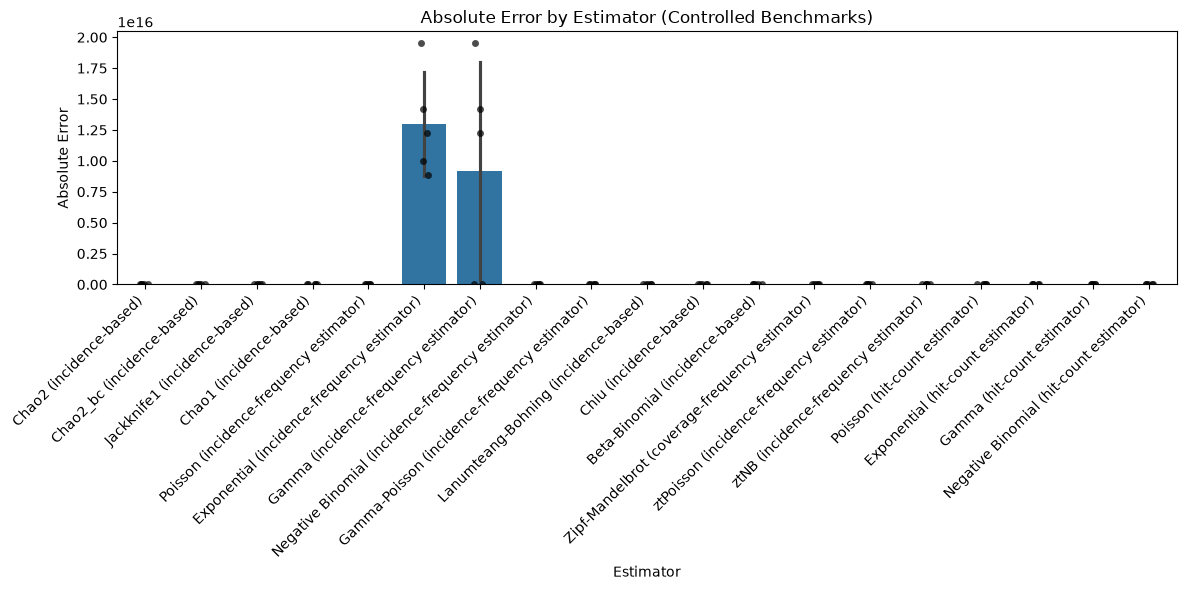

Saved plot data: analysis_outputs_new/summaries/plot_data/relative_error_by_estimator_raw.csv
Saved plot data: analysis_outputs_new/summaries/plot_data/relative_error_by_estimator_summary.csv


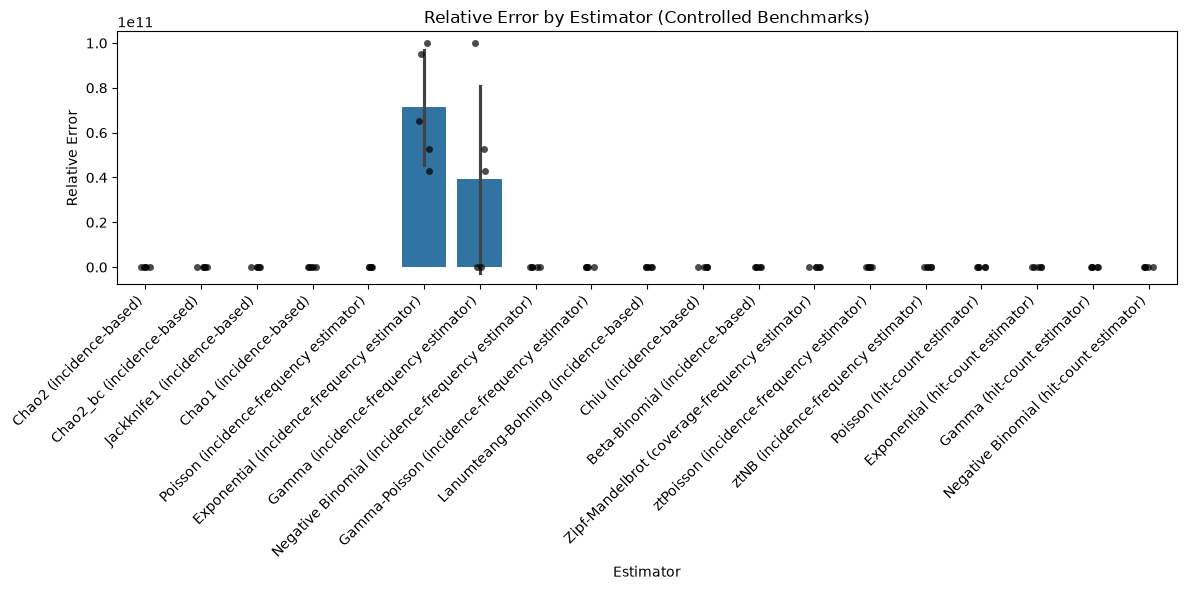

Saved plot data: analysis_outputs_new/summaries/plot_data/rmse_comparison_input.csv
Saved plot data: analysis_outputs_new/summaries/plot_data/rmse_comparison_summary.csv


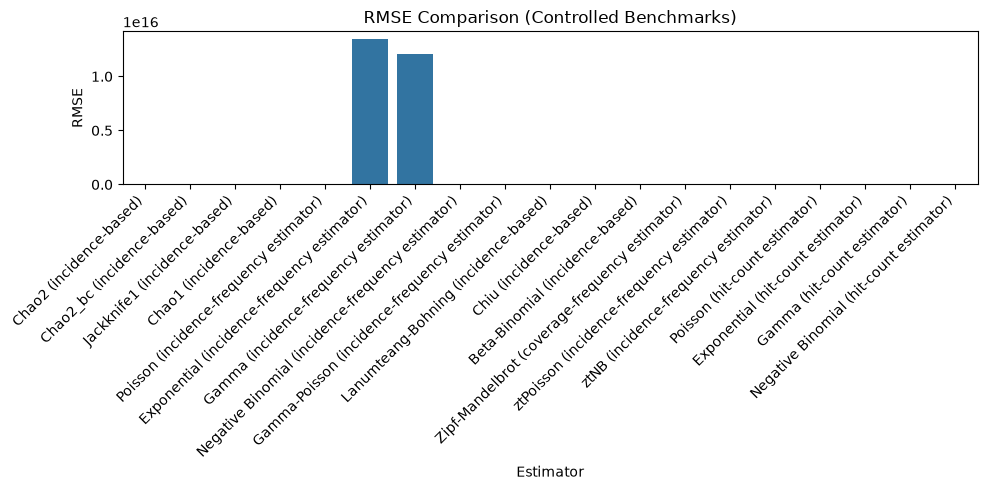

In [80]:
# ============================================================
# Controlled benchmarks: absolute error, relative error, RMSE
# ============================================================

def plot_bar_with_subject_points(df, y_col: str, title: str, ylabel: str, csv_prefix: str):
    raw_cols = [
        "subject", "program_type", "has_known_total", "known_total",
        "estimator_label", "estimate_total", "signed_error", "abs_error", "rel_error", y_col,
    ]
    _save_plot_csv(df.sort_values(["estimator_label", "subject"]), f"{csv_prefix}_raw.csv", raw_cols)

    summary_df = (
        df.groupby("estimator_label", observed=False)[y_col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"mean": f"{y_col}_mean", "std": f"{y_col}_sd", "count": "n_subjects"})
    )
    summary_df["estimator_label"] = pd.Categorical(summary_df["estimator_label"], categories=ESTIMATOR_ORDER, ordered=True)
    summary_df = summary_df.sort_values("estimator_label")
    _save_plot_csv(summary_df, f"{csv_prefix}_summary.csv")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x="estimator_label", y=y_col, errorbar="sd", order=ESTIMATOR_ORDER)
    sns.stripplot(data=df, x="estimator_label", y=y_col, color="black", size=5, jitter=True, alpha=0.7, order=ESTIMATOR_ORDER)
    plt.title(title)
    plt.xlabel("Estimator")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_bar_with_subject_points(
    df_known,
    y_col="abs_error",
    title="Absolute Error by Estimator (Controlled Benchmarks)",
    ylabel="Absolute Error",
    csv_prefix="absolute_error_by_estimator",
)

plot_bar_with_subject_points(
    df_known,
    y_col="rel_error",
    title="Relative Error by Estimator (Controlled Benchmarks)",
    ylabel="Relative Error",
    csv_prefix="relative_error_by_estimator",
)

rmse_input_df = (
    df_known[["subject", "estimator_label", "signed_error", "abs_error", "rel_error", "estimate_total", "known_total"]]
    .sort_values(["estimator_label", "subject"])
    .copy()
)
_save_plot_csv(rmse_input_df, "rmse_comparison_input.csv")

rmse_df = (
    df_known.groupby("estimator_label", observed=False)["signed_error"]
    .apply(lambda s: np.sqrt(np.mean(np.square(s.dropna()))) if s.notna().any() else np.nan)
    .reset_index(name="RMSE")
)
rmse_df["estimator_label"] = pd.Categorical(rmse_df["estimator_label"], categories=ESTIMATOR_ORDER, ordered=True)
rmse_df = rmse_df.sort_values("estimator_label")
_save_plot_csv(rmse_df, "rmse_comparison_summary.csv")

plt.figure(figsize=(10, 5))
sns.barplot(data=rmse_df, x="estimator_label", y="RMSE", order=ESTIMATOR_ORDER)
plt.title("RMSE Comparison (Controlled Benchmarks)")
plt.xlabel("Estimator")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Saved plot data: analysis_outputs_new/summaries/plot_data/synthetic_estimator_comparison_per_subject.csv


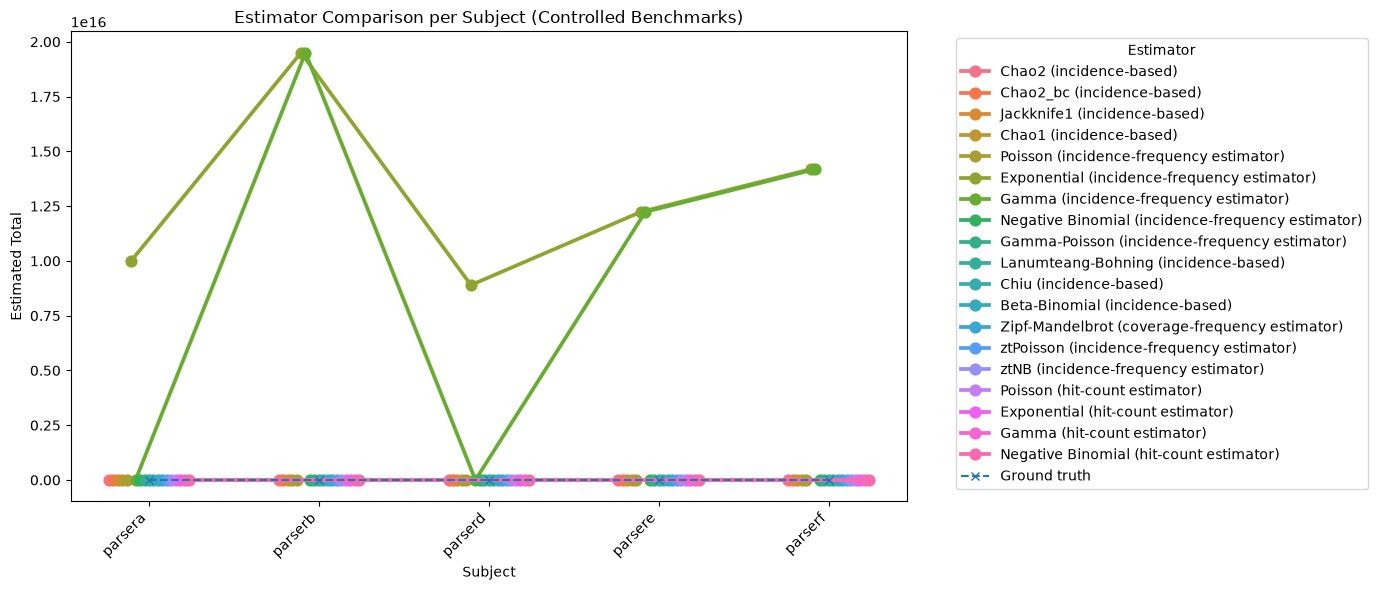

In [81]:
# ============================================================
# Controlled benchmarks: per-subject estimator comparison
# ============================================================

_cols = [
    "subject", "estimator_label", "estimate_total",
    "known_total", "observed_total", "abs_error", "rel_error", "signed_error",
    "n_campaigns", "n_rows_total", "n_blocks_total",
]
_available_cols = [c for c in _cols if c in df_known.columns]

df_known_plot_data = (
    df_known[_available_cols]
    .sort_values(["subject", "estimator_label"])
    .copy()
)

std_dev = (
    df_known_plot_data.groupby("estimator_label")["estimate_total"]
    .std(ddof=1)
    .round()
    .astype(int)
    .rename("std_dev")
)
df_known_plot_data = df_known_plot_data.merge(std_dev, on="estimator_label", how="left")
_save_plot_csv(df_known_plot_data, "synthetic_estimator_comparison_per_subject.csv")

plt.figure(figsize=(14, 6))
sns.pointplot(
    data=df_known,
    x="subject",
    y="estimate_total",
    hue="estimator_label",
    dodge=True,
    markers="o",
    linestyles="-",
    errorbar=None,
    hue_order=ESTIMATOR_ORDER,
)
truth_df = df_known[["subject", "known_total"]].drop_duplicates().sort_values("subject")
plt.plot(truth_df["subject"], truth_df["known_total"], marker="x", linestyle="--", label="Ground truth")

plt.title("Estimator Comparison per Subject (Controlled Benchmarks)")
plt.xlabel("Subject")
plt.ylabel("Estimated Total")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Estimator", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Saved plot data: analysis_outputs_new/summaries/plot_data/real_world_estimator_comparison_per_subject.csv


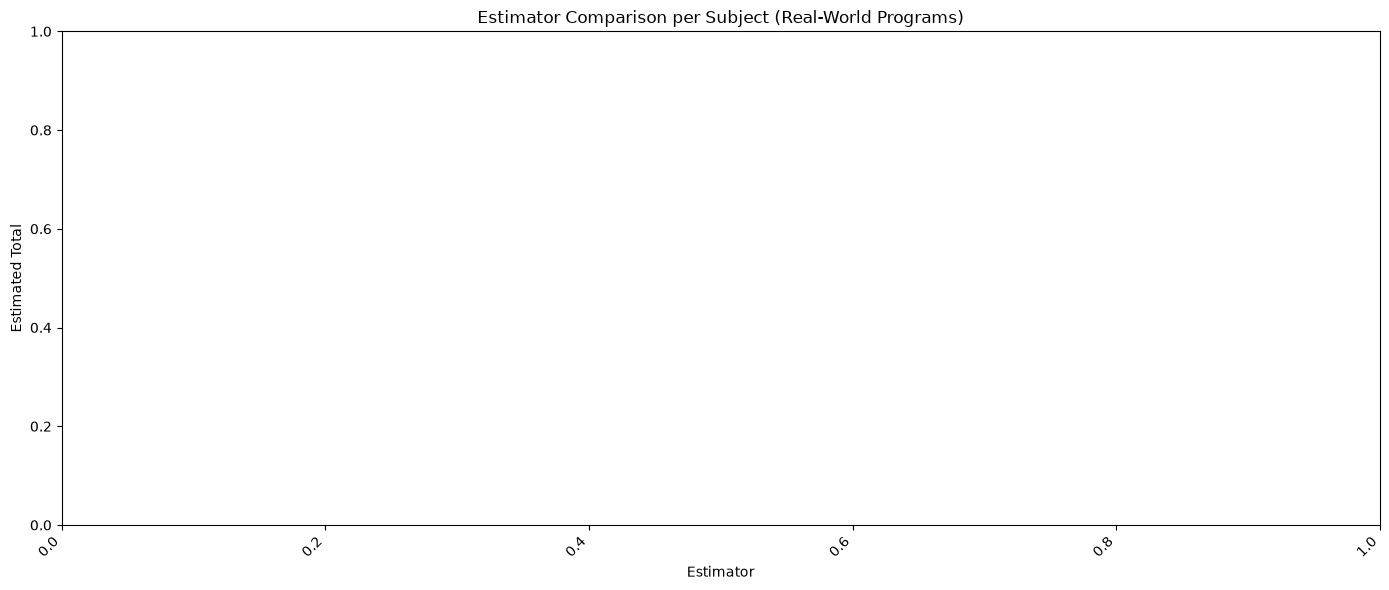

In [82]:
# ============================================================
# Real-world programs: per-subject estimator comparison
# ============================================================

_cols = [
    "subject", "estimator_label", "estimate_total",
    
    "n_campaigns", "n_rows_total", "n_blocks_total",
]
_available_cols = [c for c in _cols if c in df_unknown.columns]

df_unknown_pointplot = (
    df_unknown[_available_cols]
    .sort_values(["subject", "estimator_label"])
    .copy()
)
_save_plot_csv(df_unknown_pointplot, "real_world_estimator_comparison_per_subject.csv")

plt.figure(figsize=(14, 6))
sns.pointplot(
    data=df_unknown,
    x="estimator_label",
    y="estimate_total",
    hue="subject",
    dodge=True,
    markers="o",
    linestyles="-",
    errorbar=None,
    order=ESTIMATOR_ORDER,
)

plt.title("Estimator Comparison per Subject (Real-World Programs)")
plt.xlabel("Estimator")
plt.ylabel("Estimated Total")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


Saved plot data: analysis_outputs_new/summaries/plot_data/estimator_behavior_across_subjects.csv


/var/folders/6v/7wq4kb811_n7vyc91brlwpr80000gp/T/ipykernel_83488/2037500518.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")


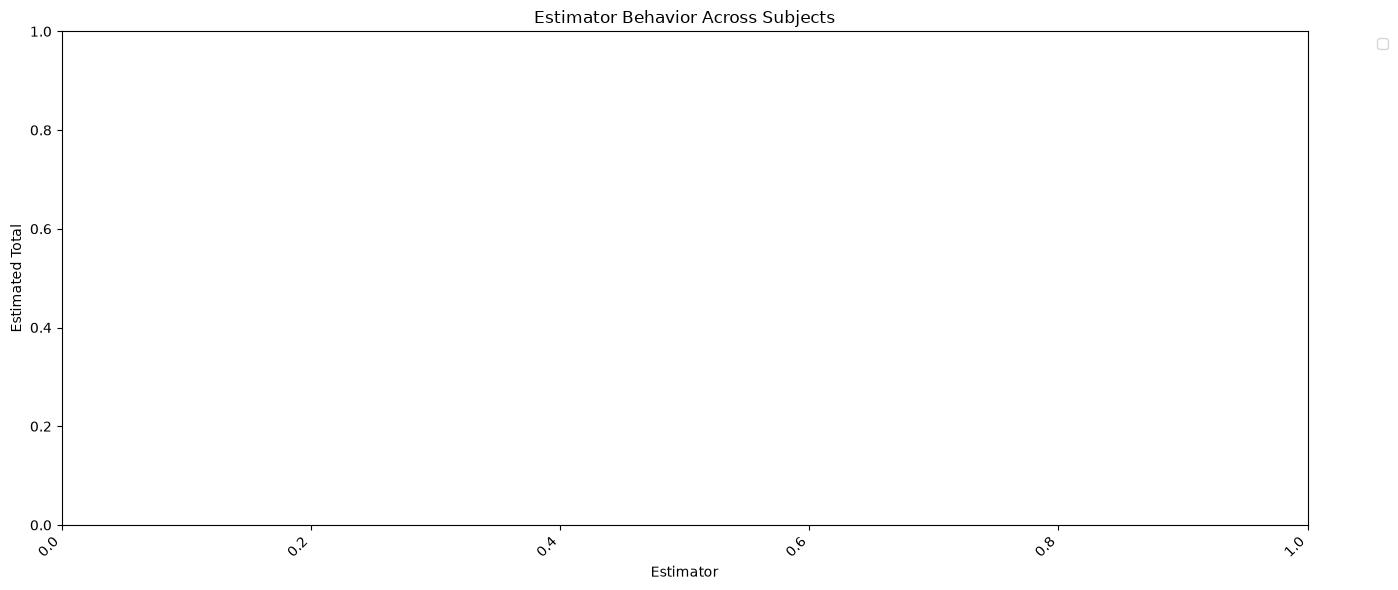

Saved plot data: analysis_outputs_new/summaries/plot_data/deviation_from_subject_mean_raw.csv
Saved plot data: analysis_outputs_new/summaries/plot_data/deviation_from_subject_mean_summary.csv


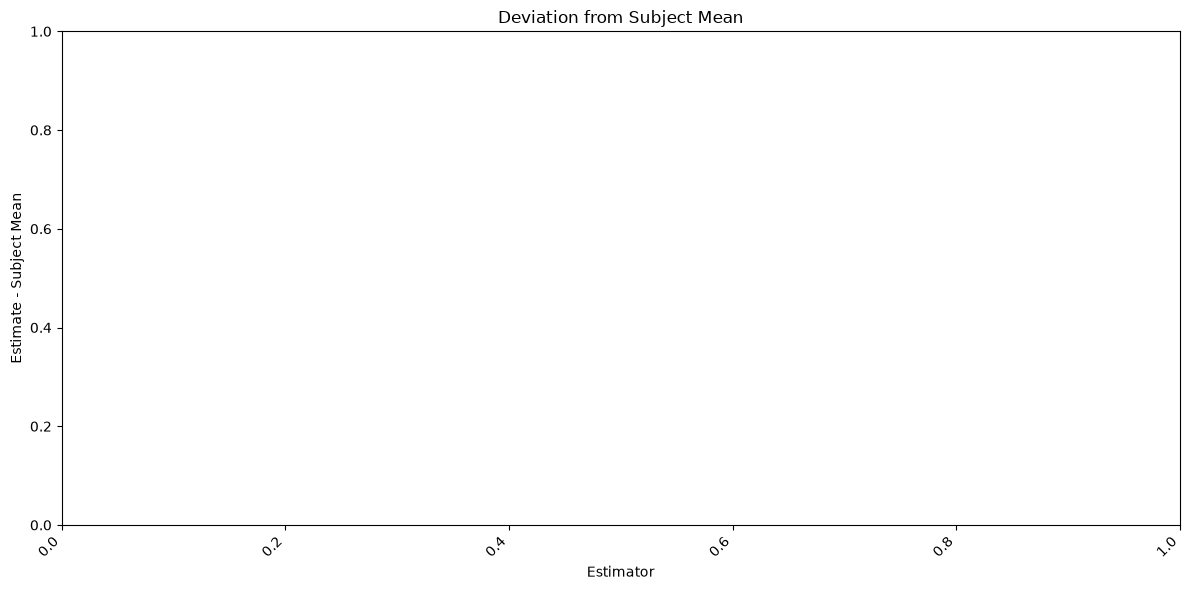

In [83]:
# ============================================================
# Real-world programs: behavior across subjects
# ============================================================

lineplot_df = (
    df_unknown[["subject", "estimator_label", "estimate_total"]]
    .sort_values(["subject", "estimator_label"])
    .copy()
)
_save_plot_csv(lineplot_df, "estimator_behavior_across_subjects.csv")

plt.figure(figsize=(14, 6))
for subject, g in df_unknown.groupby("subject"):
    g = g.sort_values("estimator_label")
    plt.plot(g["estimator_label"], g["estimate_total"], marker="o", label=subject)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Estimator Behavior Across Subjects")
plt.xlabel("Estimator")
plt.ylabel("Estimated Total")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

df_unknown = df_unknown.copy()
df_unknown["mean_per_subject"] = df_unknown.groupby("subject")["estimate_total"].transform("mean")
df_unknown["relative_diff"] = df_unknown["estimate_total"] - df_unknown["mean_per_subject"]

boxplot_raw_df = (
    df_unknown[["subject", "estimator_label", "estimate_total", "mean_per_subject", "relative_diff"]]
    .sort_values(["estimator_label", "subject"])
    .copy()
)
_save_plot_csv(boxplot_raw_df, "deviation_from_subject_mean_raw.csv")

boxplot_summary_df = (
    df_unknown.groupby("estimator_label", observed=False)["relative_diff"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        min="min",
        q1=lambda s: s.quantile(0.25),
        median="median",
        q3=lambda s: s.quantile(0.75),
        max="max",
    )
    .reset_index()
)
boxplot_summary_df["estimator_label"] = pd.Categorical(boxplot_summary_df["estimator_label"], categories=ESTIMATOR_ORDER, ordered=True)
boxplot_summary_df = boxplot_summary_df.sort_values("estimator_label")
_save_plot_csv(boxplot_summary_df, "deviation_from_subject_mean_summary.csv")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_unknown, x="estimator_label", y="relative_diff", order=ESTIMATOR_ORDER)
plt.title("Deviation from Subject Mean")
plt.xlabel("Estimator")
plt.ylabel("Estimate - Subject Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Generic paper-style table generation

The following section generates generic CSV tables in the same style as paper tables:

- model fit comparison tables
- fitted parameter table
- estimator performance tables
- ΔAIC summary table

It uses the notebook's existing `subject_fit_df`, `comparison_df`, and `SUMMARIES_DIR`.

In [84]:
# ============================================================
# Generic paper-style table generation
# ============================================================

MODEL_ORDER_GENERIC = [
    "Poisson (incidence-frequency)",
    "Exponential (incidence-frequency)",
    "Gamma (incidence-frequency)",
    "Negative Binomial (incidence-frequency)",
    "Gamma-Poisson (incidence-frequency)",
    "Poisson (hit-count)",
    "Exponential (hit-count)",
    "Gamma (hit-count)",
    "Negative Binomial (hit-count)",
    "Zipf-Mandelbrot (coverage-frequency)",
    "ztPoisson (incidence-frequency)",
    "ztNB (incidence-frequency)",
]

ESTIMATOR_ORDER_GENERIC = [
    "Chao2 (incidence-based)",
    "Chao2_bc (incidence-based)",
    "Jackknife1 (incidence-based)",
    "Chao1 (incidence-based)",
    "Poisson (incidence-frequency estimator)",
    "Exponential (incidence-frequency estimator)",
    "Gamma (incidence-frequency estimator)",
    "Negative Binomial (incidence-frequency estimator)",
    "Gamma-Poisson (incidence-frequency estimator)",
    "Lanumteang-Bohning (incidence-based)",
    "Chiu (incidence-based)",
    "Beta-Binomial (incidence-based)",
    "Zipf-Mandelbrot (coverage-frequency estimator)",
    "ztPoisson (incidence-frequency estimator)",
    "ztNB (incidence-frequency estimator)",
    "Poisson (hit-count estimator)",
    "Exponential (hit-count estimator)",
    "Gamma (hit-count estimator)",
    "Negative Binomial (hit-count estimator)",
]

def _apply_generic_order(df: pd.DataFrame, col: str, preferred_order: List[str]) -> pd.DataFrame:
    out = df.copy()
    present = [x for x in preferred_order if x in out[col].astype(str).unique()]
    if present:
        out[col] = pd.Categorical(out[col], categories=present, ordered=True)
        sort_cols = [c for c in ["subject", col] if c in out.columns]
        if sort_cols:
            out = out.sort_values(sort_cols)
    return out

def _ensure_generic_error_columns(
    df: pd.DataFrame,
    estimate_col: str = "estimate_total",
    truth_col: str = "known_total",
) -> pd.DataFrame:
    out = df.copy()
    if estimate_col in out.columns and truth_col in out.columns:
        if "signed_error" not in out.columns:
            out["signed_error"] = out[estimate_col] - out[truth_col]
        if "abs_error" not in out.columns:
            out["abs_error"] = out["signed_error"].abs()
        if "rel_error" not in out.columns:
            out["rel_error"] = np.where(
                out[truth_col].astype(float) != 0,
                out["abs_error"] / out[truth_col].astype(float),
                np.nan,
            )
    return out

def generate_generic_model_fit_tables(
    fit_df: pd.DataFrame,
    out_dir: Path = SUMMARIES_DIR,
    subject_col: str = "subject",
    model_col: str = "model",
    group_col: str = "program_type",
    metric_cols: Tuple[str, ...] = ("rmse", "aic", "bic", "loglik"),
    parameter_cols: Tuple[str, ...] = ("shape", "scale", "rate", "lambda", "size", "prob", "mean", "q"),
) -> Dict[str, Optional[pd.DataFrame]]:
    df = fit_df.copy()

    if df.empty:
        raise ValueError("fit_df is empty; cannot generate model-fit tables")

    if group_col not in df.columns:
        subject_series = df[subject_col].astype(str).str.lower()
        df[group_col] = np.where(
            subject_series.isin([str(k).lower() for k in KNOWN_TOTALS.keys()]),
            "synthetic",
            "real_world"
        )

    df = _apply_generic_order(df, model_col, MODEL_ORDER_GENERIC)

    fit_cols = [c for c in [subject_col, group_col, model_col, *metric_cols] if c in df.columns]
    fit_table = df[fit_cols].copy()
    fit_table.to_csv(out_dir / "model_fit_all_subjects.csv", index=False)

    for group_value, sub in fit_table.groupby(group_col, dropna=False):
        safe = str(group_value).lower().replace(" ", "_")
        sub = sub.sort_values([c for c in [subject_col, model_col] if c in sub.columns])
        sub.to_csv(out_dir / f"model_fit_{safe}.csv", index=False)

    param_cols_present = [c for c in parameter_cols if c in df.columns]
    param_table = None
    if param_cols_present:
        param_table = (
            df[[c for c in [subject_col, group_col, model_col, *param_cols_present] if c in df.columns]]
            .dropna(how="all", subset=param_cols_present)
            .sort_values([c for c in [group_col, subject_col, model_col] if c in df.columns])
            .reset_index(drop=True)
        )
        param_table.to_csv(out_dir / "fitted_model_parameters.csv", index=False)

    delta_aic_summary = None
    if "aic" in df.columns:
        tmp = df[[subject_col, model_col, "aic"]].copy()
        tmp = tmp.dropna(subset=["aic"])
        if not tmp.empty:
            tmp["min_aic_subject"] = tmp.groupby(subject_col)["aic"].transform("min")
            tmp["delta_aic"] = tmp["aic"] - tmp["min_aic_subject"]

            delta_aic_summary = (
                tmp.groupby(model_col, as_index=False)
                .agg(
                    subjects_won=("delta_aic", lambda s: int(np.sum(np.isclose(s, 0.0)))),
                    mean_delta_aic=("delta_aic", "mean"),
                    median_delta_aic=("delta_aic", "median"),
                    min_delta_aic=("delta_aic", "min"),
                    max_delta_aic=("delta_aic", "max"),
                )
            )
            delta_aic_summary = _apply_generic_order(delta_aic_summary, model_col, MODEL_ORDER_GENERIC)
            delta_aic_summary.to_csv(out_dir / "model_delta_aic_summary.csv", index=False)

    return {
        "fit_table": fit_table,
        "param_table": param_table,
        "delta_aic_summary": delta_aic_summary,
    }


In [85]:

import pandas as pd
import numpy as np

# -------------------------------
# STEP 1: Filter only parser subjects (known totals)
# -------------------------------
df = comparison_known_df.copy()
df = df[df["subject"].isin(KNOWN_TOTALS.keys())].copy()

# -------------------------------
# STEP 2: Aggregate per unique subject + estimator label
# -------------------------------
df_subject = (
    df.groupby(["subject", "estimator", "estimator_input", "estimator_label"], as_index=False)
      .agg(estimate_total=("estimate_total", "mean"))
)

# -------------------------------
# STEP 3: Add known totals and errors
# -------------------------------
df_subject["known_total"] = df_subject["subject"].map(KNOWN_TOTALS)
df_subject["signed_error"] = df_subject["estimate_total"] - df_subject["known_total"]
df_subject["abs_error"] = df_subject["signed_error"].abs()
df_subject["rel_error"] = df_subject["abs_error"] / df_subject["known_total"]

# -------------------------------
# STEP 4: Save full subject-level table
# -------------------------------
df_subject = df_subject.sort_values(["subject", "estimator_input", "estimator_label"]).reset_index(drop=True)
df_subject.to_csv(SUMMARIES_DIR / "subject_level_estimator_comparison.csv", index=False)

# -------------------------------
# STEP 5: Save grouped views
# -------------------------------
group_views = {
    "standard_parametric_incidence": (
        (df_subject["estimator_input"] == "incidence_frequency") &
        (df_subject["estimator"].isin(STANDARD_PARAMETRIC_ESTIMATORS))
    ),
    "non_parametric_incidence": (
        (df_subject["estimator_input"] == "incidence_frequency") &
        (df_subject["estimator"].isin(NON_PARAMETRIC_ESTIMATORS))
    ),
    "zt_only": df_subject["estimator"].isin(ZT_PARAMETRIC_ESTIMATORS),
    "hit_count_parametric": df_subject["estimator_input"] == "hit_count",
    "parametric_plus_hitcount": (
        ((df_subject["estimator_input"] == "incidence_frequency") & (df_subject["estimator"].isin(STANDARD_PARAMETRIC_ESTIMATORS))) |
        (df_subject["estimator_input"] == "hit_count")
    ),
}

for view_name, mask in group_views.items():
    out = df_subject[mask].copy()
    out.to_csv(SUMMARIES_DIR / f"subject_level_estimator_comparison_{view_name}.csv", index=False)

df_subject.head()


,subject,estimator,estimator_input,estimator_label,estimate_total,known_total,signed_error,abs_error,rel_error
0,parsera,Exponential,hit_count,Exponential (hit-count estimator),9995.000612,104952,-94956.999388,94956.999388,0.904766
1,parsera,Gamma,hit_count,Gamma (hit-count estimator),10822.392170,104952,-94129.607830,94129.607830,0.896882
2,parsera,Negative Binomial,hit_count,Negative Binomial (hit-count estimator),10792.494764,104952,-94159.505236,94159.505236,0.897167
3,parsera,Poisson,hit_count,Poisson (hit-count estimator),9995.000000,104952,-94957.000000,94957.000000,0.904766
4,parsera,Beta-Binomial,incidence_frequency,Beta-Binomial (incidence-based),10038.906952,104952,-94913.093048,94913.093048,0.904348


In [86]:
import pandas as pd
from pathlib import Path

# ==============================
# Input / output paths
# ==============================
INPUT_CSV = SUMMARIES_DIR / "subject_parametric_fit_summary.csv"
OUTPUT_DIR = Path(".")

# ==============================
# Load data
# ==============================
df = pd.read_csv(INPUT_CSV)

# ==============================
# Subject groups
# Synthetic programs: parser*
# Real-world programs: everything else
# ==============================
df["subject"] = df["subject"].astype(str)

is_synthetic = df["subject"].str.startswith("parser")
is_real = ~is_synthetic

# ==============================
# Fit groups
# ==============================
fit_family = df["fit_family"].fillna("").astype(str).str.lower()
fit_input = df["fit_input"].fillna("").astype(str).str.lower()

# Zero-truncated rows
is_zt = fit_family.str.contains("zero-truncated", case=False, na=False)

# Hit-count rows
# Adjust this if your notebook uses a slightly different label
is_hitcount = fit_input.eq("nonzero_averaged_hit_count")

# Incidence rows excluding zt
# In your current CSV, this usually leaves Zipf-Mandelbrot rows
is_incidence = fit_input.isin(["incidence_frequency", "incidence_sum_axis1"]) & (~is_zt)

# ==============================
# Split into six CSVs
# ==============================
outputs = {
    "model_fit_incidence_real.csv": df[is_incidence & is_real].copy(),
    "model_fit_incidence_synthetic.csv": df[is_incidence & is_synthetic].copy(),
    "model_fit_hitcount_real.csv": df[is_hitcount & is_real].copy(),
    "model_fit_hitcount_synthetic.csv": df[is_hitcount & is_synthetic].copy(),
    "model_fit_zt_real.csv": df[is_zt & is_real].copy(),
    "model_fit_zt_synthetic.csv": df[is_zt & is_synthetic].copy(),
}

# ==============================
# Save files
# ==============================
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for filename, subdf in outputs.items():
    out_path = OUTPUT_DIR / filename
    subdf.to_csv(out_path, index=False)
    print(f"Saved: {out_path} ({len(subdf)} rows)")

# ==============================
# Optional summary
# ==============================
print("\nSummary:")
for filename, subdf in outputs.items():
    subjects = sorted(subdf["subject"].unique()) if not subdf.empty else []
    models = sorted(subdf["model"].astype(str).unique()) if not subdf.empty else []
    print(f"\n{filename}")
    print(f"  rows    : {len(subdf)}")
    print(f"  subjects: {subjects}")
    print(f"  models  : {models}")

Saved: model_fit_incidence_real.csv (0 rows)
Saved: model_fit_incidence_synthetic.csv (5 rows)
Saved: model_fit_hitcount_real.csv (0 rows)
Saved: model_fit_hitcount_synthetic.csv (20 rows)
Saved: model_fit_zt_real.csv (0 rows)
Saved: model_fit_zt_synthetic.csv (25 rows)

Summary:

model_fit_incidence_real.csv
  rows    : 0
  subjects: []
  models  : []

model_fit_incidence_synthetic.csv
  rows    : 5
  subjects: ['parsera', 'parserb', 'parserd', 'parsere', 'parserf']
  models  : ['Zipf-Mandelbrot (coverage-frequency)']

model_fit_hitcount_real.csv
  rows    : 0
  subjects: []
  models  : []

model_fit_hitcount_synthetic.csv
  rows    : 20
  subjects: ['parsera', 'parserb', 'parserd', 'parsere', 'parserf']
  models  : ['Exponential (hit-count)', 'Gamma (hit-count)', 'Negative Binomial (hit-count)', 'Poisson (hit-count)']

model_fit_zt_real.csv
  rows    : 0
  subjects: []
  models  : []

model_fit_zt_synthetic.csv
  rows    : 25
  subjects: ['parsera', 'parserb', 'parserd', 'parsere', '

In [87]:
import pandas as pd
#SUMMARIES_DIR = Path("/Users/natt0753/USYD/Papers_Submitted/ISSRE2026/main_V2/issre2026-parametric-species/analysis_outputs/summaries")
# Load your main estimator file
df = pd.read_csv(SUMMARIES_DIR / "estimator_comparison_known_totals_only.csv")

# Group by estimator
df_summary = (
    df.groupby("estimator")["abs_error"]
    .agg(MAE="mean", SD="std")
    .reset_index()
)

# Save to CSV
df_summary.to_csv(SUMMARIES_DIR / "estimator_mae_sd_summary.csv", index=False)

print(df_summary)

             estimator           MAE            SD
0        Beta-Binomial  1.868178e+05  8.676318e+04
1                Chao1  1.868217e+05  8.675938e+04
2                Chao2  1.868218e+05  8.675939e+04
3             Chao2_bc  1.868222e+05  8.675910e+04
4                 Chiu  1.868505e+05  8.676481e+04
5          Exponential  6.481600e+15  7.380421e+15
6                Gamma  4.592400e+15  7.604012e+15
7        Gamma-Poisson  1.867895e+05  8.671142e+04
8           Jackknife1  1.866874e+05  8.662730e+04
9   Lanumteang-Bohning  1.868231e+05  8.678084e+04
10   Negative Binomial  1.861298e+05  8.140250e+04
11             Poisson  1.868508e+05  8.180247e+04
12     Zipf-Mandelbrot  1.868508e+05  8.676463e+04
13                ztNB  1.867895e+05  8.671142e+04
14           ztPoisson  1.868508e+05  8.676463e+04


In [88]:
import pandas as pd

# Load the correct CSV
df = pd.read_csv(SUMMARIES_DIR / "estimator_comparison_known_totals_only.csv")

# Compute bias and variance per estimator
bias_variance_df = (
    df.groupby("estimator")["signed_error"]
      .agg(
          bias="mean",
          variance="std"
      )
      .reset_index()
)

# Save new CSV
bias_variance_df.to_csv(SUMMARIES_DIR / "estimator_bias_variance.csv", index=False)

print(bias_variance_df)

             estimator          bias      variance
0        Beta-Binomial -1.868178e+05  8.676318e+04
1                Chao1 -1.868217e+05  8.675938e+04
2                Chao2 -1.868218e+05  8.675939e+04
3             Chao2_bc -1.868222e+05  8.675910e+04
4                 Chiu -1.868505e+05  8.676481e+04
5          Exponential  6.481600e+15  7.380421e+15
6                Gamma  4.592400e+15  7.604012e+15
7        Gamma-Poisson -1.867895e+05  8.671142e+04
8           Jackknife1 -1.866874e+05  8.662730e+04
9   Lanumteang-Bohning -1.868231e+05  8.678084e+04
10   Negative Binomial -1.861298e+05  8.140250e+04
11             Poisson -1.868508e+05  8.180247e+04
12     Zipf-Mandelbrot -1.868508e+05  8.676463e+04
13                ztNB -1.867895e+05  8.671142e+04
14           ztPoisson -1.868508e+05  8.676463e+04


In [89]:
import pandas as pd
import numpy as np

# ============================================================
# Input files
# ============================================================
files = {
    "hit_count": SUMMARIES_DIR / "subject_parametric_fit_summary_hit_count.csv",
    "incidence_frequency": SUMMARIES_DIR / "subject_parametric_fit_summary_incidence_frequency.csv",
    "zipf_coverage_frequency": SUMMARIES_DIR / "subject_parametric_fit_summary_zipf_coverage_frequency.csv",
}

# ============================================================
# Function to compute delta-AIC summary for one dataframe
# ============================================================
def compute_delta_aic_summary(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    # Keep only rows with valid subject, model, aic
    df = df.copy()
    df = df.dropna(subset=["subject", "model", "aic"])

    # Ensure numeric AIC
    df["aic"] = pd.to_numeric(df["aic"], errors="coerce")
    df = df.dropna(subset=["aic"])

    # Best AIC for each subject
    best_aic_per_subject = df.groupby("subject")["aic"].min().rename("best_aic")

    # Merge best AIC back
    df = df.merge(best_aic_per_subject, on="subject", how="left")

    # Compute delta AIC
    df["delta_aic"] = df["aic"] - df["best_aic"]

    # Count wins: delta_aic == 0
    # Use np.isclose to avoid floating point issues
    summary = (
        df.groupby("model")
          .agg(
              subjects_won=("delta_aic", lambda x: int(np.isclose(x, 0).sum())),
              mean_delta_aic=("delta_aic", "mean"),
              median_delta_aic=("delta_aic", "median"),
              min_delta_aic=("delta_aic", "min"),
              max_delta_aic=("delta_aic", "max"),
          )
          .reset_index()
    )

    # Add source column
    summary.insert(0, "source", source_name)

    return summary


# ============================================================
# Process all files
# ============================================================
all_summaries = []

for source_name, file_path in files.items():
    df = pd.read_csv(file_path)
    summary_df = compute_delta_aic_summary(df, source_name)
    all_summaries.append(summary_df)

# Combine into one dataframe
combined_summary = pd.concat(all_summaries, ignore_index=True)

# Optional: sort nicely
combined_summary = combined_summary.sort_values(
    by=["source", "subjects_won", "mean_delta_aic"],
    ascending=[True, False, True]
).reset_index(drop=True)

# ============================================================
# Save combined CSV
# ============================================================
output_file = "delta_aic_summary_all_models.csv"
combined_summary.to_csv(output_file, index=False)

print(f"Saved combined summary to: {output_file}")
print(combined_summary)

Saved combined summary to: delta_aic_summary_all_models.csv
                    source                                    model  \
0                hit_count                        Gamma (hit-count)   
1                hit_count            Negative Binomial (hit-count)   
2                hit_count                  Exponential (hit-count)   
3                hit_count                      Poisson (hit-count)   
4      incidence_frequency  Negative Binomial (incidence-frequency)   
5      incidence_frequency      Gamma-Poisson (incidence-frequency)   
6      incidence_frequency            Poisson (incidence-frequency)   
7      incidence_frequency              Gamma (incidence-frequency)   
8      incidence_frequency        Exponential (incidence-frequency)   
9  zipf_coverage_frequency     Zipf-Mandelbrot (coverage-frequency)   

   subjects_won  mean_delta_aic  median_delta_aic  min_delta_aic  \
0             5    0.000000e+00      0.000000e+00   0.000000e+00   
1             0    1.2

In [90]:
import pickle

with open("/Users/natt0753/USYD/Papers_Submitted/ISSRE2026/main_V2/issre2026-parametric-species/analysis_outputs/subject_artifacts/freetype2/incidence.pkl", "rb") as f:
    data = pickle.load(f)
    
print(type(data))
print(data.shape)
print(data[:5])

FileNotFoundError: [Errno 2] No such file or directory: '/Users/natt0753/USYD/Papers_Submitted/ISSRE2026/main_V2/issre2026-parametric-species/analysis_outputs/subject_artifacts/freetype2/incidence.pkl'

In [ ]:
import pickle
import pandas as pd
import numpy as np

with open("/Users/natt0753/USYD/Papers_Submitted/ISSRE2026/main_V2/issre2026-parametric-species/analysis_outputs/campaign_artifacts/freetype2_aflpp_run_01/incidence.pkl", "rb") as f:
    data = pickle.load(f)

if isinstance(data, pd.DataFrame):
    df = data

elif isinstance(data, np.ndarray):
    if data.ndim == 1:
        df = pd.DataFrame(data, columns=["value"])
    elif data.ndim == 2:
        df = pd.DataFrame(data)
    else:
        raise ValueError("Unsupported ndarray shape")

else:
    raise ValueError("Unsupported data type")


df.to_csv("output_incidence_2.csv", index=False)

# Paper table reproduction (from `analysis_outputs_new/summaries/` CSVs only)

The cells below regenerate the tables that appear in `issre2026-parametric-species-3.tex` / `issre2026_rene.pdf`, using only the CSV files in `analysis_outputs_new/summaries/`. No values from the paper are hardcoded.

Reproduced:
- **Fitted Zipf–Mandelbrot Distribution Parameters per Subject** (`tab:zipfparamssplit`)
- **Estimator Performance (Bias and Relative Error)** (`tab:estimatorPerformance`)
- **Per-subject estimator comparison for synthetic parser benchmarks** (`tab:subjectEstimatorTable`)

Output tables are written to `analysis_outputs_new/summaries/paper_tables/` (a new subfolder), not into `summaries/` directly.

Not reproduced (no matching data exists in `analysis_outputs_new/summaries/`):
- Synthetic/Real-world program subject tables (LOC, #Basic Blocks, Covered Blocks are static source-code metrics, not present in any summary CSV)
- Model fit comparison for real-world programs (`tab:realworldModels`) — the summary CSVs only contain synthetic parser subjects (parsera/b/d/e/f), no jsoncpp/libtiff/libxml2/libpcap/jasper/freetype2/zlib rows

Notes on data availability:
- The Zipf–Mandelbrot parameter table only includes the synthetic subjects present in the data (parsera, parserb, parserd, parsere, parserf); real-world subjects and parserc/parserg are absent from the summaries.
- In the per-subject estimator table, `std_dev` (sourced from `rmse`) is only populated for the Gamma-Poisson and Zipf-Mandelbrot rows — it is left as `NaN` for the five non-parametric estimators (Chao2, Chao2_bc, Jackknife1, Chiu, Lanumteang-Bohning), since the source CSV has no rmse value for them.
- The lowest- and highest-relative-error subjects are selected programmatically from the data (not hardcoded), so they may differ from the parsers named in the paper.


In [ ]:
# ============================================================
# Paper Table: Fitted Zipf-Mandelbrot Distribution Parameters per Subject
# (paper Table: "Fitted Zipf--Mandelbrot Distribution Parameters per Subject", \label{tab:zipfparamssplit})
# Source: analysis_outputs_new/summaries/subject_parametric_fit_summary_zipf_coverage_frequency.csv
# Columns used: subject, C, s, q
# ============================================================

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)

zipf_params_src = pd.read_csv(SUMMARIES_DIR / "subject_parametric_fit_summary_zipf_coverage_frequency.csv")

table_zipf_params = (
    zipf_params_src[["subject", "C", "s", "q"]]
    .dropna(subset=["C", "s", "q"])
    .sort_values("subject")
    .reset_index(drop=True)
)

table_zipf_params.to_csv(PAPER_TABLES_DIR / "paper_table_zipf_mandelbrot_params.csv", index=False)
display(table_zipf_params)


In [ ]:
# ============================================================
# Paper Table: Estimator Performance (Bias and Relative Error)
# (paper Table: "Estimator Performance (Bias and Relative Error)", \label{tab:estimatorPerformance})
# Sources:
#   - analysis_outputs_new/summaries/estimator_bias_variance.csv
#       columns used: estimator, bias, variance (variance column already holds the SD of signed_error)
#   - analysis_outputs_new/summaries/estimator_summary_by_subject_known_totals.csv
#       columns used: subject, estimator_label, mean_rel_error (aggregated mean/SD across subjects)
# ============================================================

PARAMETRIC_ESTIMATORS_PERF = ["Gamma-Poisson", "Zipf-Mandelbrot"]
NON_PARAMETRIC_ESTIMATORS_PERF = ["Chao2", "Chao2_bc", "Chiu", "Jackknife1", "Lanumteang-Bohning"]
ESTIMATOR_PERF_ORDER = PARAMETRIC_ESTIMATORS_PERF + NON_PARAMETRIC_ESTIMATORS_PERF

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)

bias_variance_src = pd.read_csv(SUMMARIES_DIR / "estimator_bias_variance.csv")
bias_variance_src = bias_variance_src[bias_variance_src["estimator"].isin(ESTIMATOR_PERF_ORDER)].copy()
bias_variance_src = bias_variance_src.rename(columns={"bias": "bias_mean", "variance": "bias_sd"})

by_subject_src = pd.read_csv(SUMMARIES_DIR / "estimator_summary_by_subject_known_totals.csv")
# estimator_label carries a suffix, e.g. "Chao2 (incidence-based)" -> strip it to match estimator_bias_variance.csv
by_subject_src["estimator"] = by_subject_src["estimator_label"].str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
by_subject_src = by_subject_src[by_subject_src["estimator"].isin(ESTIMATOR_PERF_ORDER)]

rel_error_agg = (
    by_subject_src.groupby("estimator")["mean_rel_error"]
    .agg(rel_error_mean="mean", rel_error_sd="std")
    .reset_index()
)

table_estimator_performance = bias_variance_src.merge(rel_error_agg, on="estimator", how="left")
table_estimator_performance["group"] = np.where(
    table_estimator_performance["estimator"].isin(PARAMETRIC_ESTIMATORS_PERF),
    "Parametric",
    "Non-Parametric",
)
table_estimator_performance["estimator"] = pd.Categorical(
    table_estimator_performance["estimator"], categories=ESTIMATOR_PERF_ORDER, ordered=True
)
table_estimator_performance = table_estimator_performance.sort_values("estimator").reset_index(drop=True)
table_estimator_performance = table_estimator_performance[
    ["group", "estimator", "bias_mean", "bias_sd", "rel_error_mean", "rel_error_sd"]
]

table_estimator_performance.to_csv(PAPER_TABLES_DIR / "paper_table_estimator_performance.csv", index=False)
display(table_estimator_performance)


In [ ]:
# ============================================================
# Paper Table: Per-subject estimator comparison for synthetic parser benchmarks
# (paper Table: "Per-subject estimator comparison for synthetic parser benchmarks
#  (lowest- and highest-relative-error parsers)", \label{tab:subjectEstimatorTable})
# Source: analysis_outputs_new/summaries/estimator_comparison_known_totals_only.csv
# Columns used: subject, estimator_label, known_total, observed_total, estimate_total, rmse, rel_error
#
# The lowest- and highest-relative-error subjects are selected programmatically from the
# data below (mean rel_error across the 7 estimators), rather than hardcoded.
# ============================================================

SUBJECT_ESTIMATOR_TABLE_ESTIMATORS = [
    "Gamma-Poisson (incidence-frequency estimator)",
    "Zipf-Mandelbrot (coverage-frequency estimator)",
    "Chao2 (incidence-based)",
    "Chao2_bc (incidence-based)",
    "Jackknife1 (incidence-based)",
    "Chiu (incidence-based)",
    "Lanumteang-Bohning (incidence-based)",
]

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)

comparison_known_src = pd.read_csv(SUMMARIES_DIR / "estimator_comparison_known_totals_only.csv")
subject_table_src = comparison_known_src[
    comparison_known_src["estimator_label"].isin(SUBJECT_ESTIMATOR_TABLE_ESTIMATORS)
].copy()

subject_mean_rel_error = subject_table_src.groupby("subject")["rel_error"].mean().sort_values()
lowest_subject = subject_mean_rel_error.index[0]
highest_subject = subject_mean_rel_error.index[-1]
print(f"Lowest relative-error subject: {lowest_subject} ({subject_mean_rel_error.iloc[0]:.4f})")
print(f"Highest relative-error subject: {highest_subject} ({subject_mean_rel_error.iloc[-1]:.4f})")

table_subject_estimator = subject_table_src[
    subject_table_src["subject"].isin([lowest_subject, highest_subject])
][["subject", "estimator_label", "known_total", "observed_total", "estimate_total", "rmse", "rel_error"]].copy()

table_subject_estimator["estimator_label"] = pd.Categorical(
    table_subject_estimator["estimator_label"], categories=SUBJECT_ESTIMATOR_TABLE_ESTIMATORS, ordered=True
)
table_subject_estimator["subject"] = pd.Categorical(
    table_subject_estimator["subject"], categories=[lowest_subject, highest_subject], ordered=True
)
table_subject_estimator = table_subject_estimator.sort_values(["subject", "estimator_label"]).reset_index(drop=True)
table_subject_estimator = table_subject_estimator.rename(columns={"rmse": "std_dev"})

table_subject_estimator.to_csv(PAPER_TABLES_DIR / "paper_table_subject_estimator_comparison.csv", index=False)
display(table_subject_estimator)


# Zipf–Mandelbrot ascending rank-frequency plots (TikZ generation)

Regenerates the per-parser ascending rank-frequency scatter data and the combined
`zipf-synthetic-standalone-asc.tex` group-plot figure, entirely from the subject
artifacts already loaded above (`subject_artifacts`) — no values are copied from
the paper's existing `img/zipf-parser*-asc.tex` files, they were only used as a
style/structure reference.

Pipeline:
1. For each subject, sum incidence over sampling intervals to get one frequency
   value per coverage element, keep only observed (nonzero) elements, sort ascending,
   and save the full-resolution (rank, frequency) table to
   `analysis_outputs_new/summaries/plot_data/zipf_rank_frequency_ascending/`.
2. Downsample each subject's curve to ~500 points and write a
   `img/zipf-parser<LETTER>-asc.tex` TikZ `\addplot` snippet.
3. Assemble whichever parser panels have data into a `zipf-synthetic-standalone-asc.tex`
   group-plot wrapper (3 columns, as many rows as needed).

Note: only parsers with a `subject_artifacts` entry (currently A, B, D, E, F —
parserc/parserg have no artifact data) are plotted; the wrapper notes which
parsers are omitted.


In [ ]:
# ============================================================
# Step 1: Zipf-Mandelbrot ascending rank-frequency data (per subject)
# Source: subject_artifacts[subject]["incidence"] (built earlier in this notebook)
# Output: analysis_outputs_new/summaries/plot_data/zipf_rank_frequency_ascending/<subject>_rank_frequency_ascending.csv
# ============================================================
import gc

ZIPF_ASC_DATA_DIR = SUMMARIES_DIR / "plot_data" / "zipf_rank_frequency_ascending"
ZIPF_ASC_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Map subject key (as used in subject_artifacts) -> parser letter used in paper figures.
PARSER_LETTER = {f"parser{c}": c.upper() for c in "abcdefg"}

zipf_rank_frequency = {}
for subject, artifact in subject_artifacts.items():
    if subject not in PARSER_LETTER:
        continue

    incidence = artifact["incidence"]
    n_intervals = artifact["metadata"]["n_intervals"]
    axis = 0 if incidence.shape[0] == n_intervals else 1
    freq = incidence.sum(axis=axis)

    nonzero = freq[freq > 0]
    sorted_freq = np.sort(nonzero).astype(int)
    ranks = np.arange(1, sorted_freq.size + 1)

    out = pd.DataFrame({"rank": ranks, "frequency": sorted_freq})
    out.to_csv(ZIPF_ASC_DATA_DIR / f"{subject}_rank_frequency_ascending.csv", index=False)
    zipf_rank_frequency[subject] = out

    print(
        f"{subject} (parser{PARSER_LETTER[subject]}): "
        f"S_obs={sorted_freq.size}, J={int(sorted_freq.sum())}, max_freq={int(sorted_freq.max())}"
    )

    del freq, nonzero
    gc.collect()


In [ ]:
# ============================================================
# Step 2: per-parser TikZ/pgfplots snippets (img/zipf-parser<LETTER>-asc.tex)
# Generated from the CSVs written in Step 1 (not from any paper-hardcoded values).
# ============================================================
import math

IMG_DIR = Path("img")
IMG_DIR.mkdir(parents=True, exist_ok=True)

TARGET_POINTS = 500  # matches the point density used in the paper's reference img/zipf-*-asc.tex files

def _downsample(ranks: np.ndarray, freqs: np.ndarray, target: int = TARGET_POINTS):
    n = len(ranks)
    stride = max(1, round(n / target))
    idx = np.arange(0, n, stride)
    if idx[-1] != n - 1:
        idx = np.append(idx, n - 1)
    return ranks[idx], freqs[idx]

def _nice_xmax(s_obs: int) -> int:
    xmax = math.ceil(s_obs / 1000) * 1000
    if xmax <= s_obs:
        xmax += 1000
    return xmax

def _xticks(xmax: int):
    half = round((xmax / 2) / 1000) * 1000 or 500
    def _lbl(v):
        return f"{v // 1000}k" if v % 1000 == 0 else str(v)
    return (half, xmax), (_lbl(half), _lbl(xmax))

panel_info = {}
for subject, df in zipf_rank_frequency.items():
    label = PARSER_LETTER[subject]
    ranks = df["rank"].to_numpy()
    freqs = df["frequency"].to_numpy()
    d_ranks, d_freqs = _downsample(ranks, freqs)

    pairs = list(zip(d_ranks, d_freqs))
    lines = [
        "      " + " ".join(f"({r}, {v})" for r, v in pairs[i:i + 6])
        for i in range(0, len(pairs), 6)
    ]
    coords_block = "\n".join(lines)

    tex = f"""% Zipf--Mandelbrot ascending rank-frequency data for parser{label} (subject: {subject})
% Source: analysis_outputs_new/summaries/plot_data/zipf_rank_frequency_ascending/{subject}_rank_frequency_ascending.csv
% Per-block incidence summed over sampling intervals, observed (nonzero) elements
% sorted ascending, uniformly downsampled to ~{TARGET_POINTS} points for plotting.
\\addplot[only marks, mark=*, mark size=0.9pt, color=blue!55!black, opacity=0.45]
    coordinates {{
{coords_block}
    }};
"""
    (IMG_DIR / f"zipf-parser{label}-asc.tex").write_text(tex)

    s_obs = int(ranks.max())
    xmax = _nice_xmax(s_obs)
    xtick, xticklabels = _xticks(xmax)
    panel_info[label] = {"subject": subject, "S_obs": s_obs, "xmax": xmax, "xtick": xtick, "xticklabels": xticklabels}

print("Panels generated:", sorted(panel_info.keys()))


In [ ]:
# ============================================================
# Step 3: combined group-plot wrapper -> zipf-synthetic-standalone-asc.tex
# Layout adapts to however many parser panels have data (3 columns, as many rows as needed).
# ============================================================

AVAILABLE_LABELS = sorted(panel_info.keys())  # e.g. ['A', 'B', 'D', 'E', 'F']
N_COLS = 3
n_rows = math.ceil(len(AVAILABLE_LABELS) / N_COLS)

grid = [[None] * N_COLS for _ in range(n_rows)]
for i, label in enumerate(AVAILABLE_LABELS):
    grid[i // N_COLS][i % N_COLS] = label

# bottommost populated row per column -> that panel gets visible x tick labels / xlabel
bottom_row_of_col = {}
for c in range(N_COLS):
    for r in range(n_rows - 1, -1, -1):
        if grid[r][c] is not None:
            bottom_row_of_col[c] = r
            break

def _subplot_block(label, is_bottom, is_top_left):
    info = panel_info[label]
    xmax = info["xmax"]
    t1, t2 = info["xtick"]
    l1, l2 = info["xticklabels"]
    opts = [f"title={{\\scriptsize\\texttt{{parser{label}}}}}", f"xmax={xmax}", f"xtick={{{t1},{t2}}}"]
    if is_bottom:
        opts += [f"xticklabels={{{l1},{l2}}}", "xlabel={Rank}", "xlabel style={font=\\tiny}"]
    else:
        opts.append("xticklabels=\\empty")
    if is_top_left:
        opts += ["ylabel={Frequency}", "ylabel style={font=\\tiny}"]
    return f"\\nextgroupplot[{', '.join(opts)}]\n  \\input{{img/zipf-parser{label}-asc.tex}}"

blocks = []
for r in range(n_rows):
    blocks.append(f"% Row {r + 1}")
    for c in range(N_COLS):
        label = grid[r][c]
        if label is None:
            blocks.append(
                "\\nextgroupplot[axis lines=none, xtick=\\empty, xticklabels=\\empty,\n"
                "  ytick=\\empty, yticklabels=\\empty, title=\\empty]"
            )
        else:
            is_bottom = bottom_row_of_col[c] == r
            is_top_left = (r == 0 and c == 0)
            blocks.append(_subplot_block(label, is_bottom, is_top_left))
body = "\n".join(blocks)

missing_labels = sorted(set("ABCDEFG") - set(AVAILABLE_LABELS))
note = (
    f"% NOTE: parser(s) {', '.join(missing_labels)} have no subject artifact data available "
    f"and are omitted from this figure ({len(AVAILABLE_LABELS)} of 7 panels populated)."
    if missing_labels else "% All 7 synthetic parsers are populated."
)

tex = f"""\\documentclass[tikz,border=5pt]{{standalone}}
\\usepackage{{pgfplots}}
\\pgfplotsset{{compat=1.18}}
\\usepgfplotslibrary{{groupplots}}

\\pgfplotsset{{
  compact zipf base/.style={{
    xmin=0,
    ymin=0, ymax=700,
    enlarge x limits=false,
    enlarge y limits=false,
    xlabel={{}}, ylabel={{}},
    title=\\empty,
    tick label style={{font=\\tiny}},
    ytick={{0, 200, 400, 600}},
    scaled x ticks=false,
    grid=major,
    grid style={{line width=0.3pt, draw=gray!30}},
    minor grid style={{line width=0.15pt, draw=gray!15}},
    minor tick num=4,
    clip=true,
    legend style={{draw=none, fill=none}},
    legend image post style={{opacity=0}},
    every axis legend/.append style={{opacity=0}},
  }},
}}

{note}

\\begin{{document}}
\\begin{{tikzpicture}}
\\begin{{groupplot}}[
  group style={{
    group size={N_COLS} by {n_rows},
    horizontal sep=4pt,
    vertical sep=4pt,
    y descriptions at=edge left,
  }},
  title style={{at={{(0.5,0.05)}}, anchor=south}},
  compact zipf base,
  width=7.2cm,
]
{body}
\\end{{groupplot}}
\\end{{tikzpicture}}
\\end{{document}}
"""

wrapper_path = Path("zipf-synthetic-standalone-asc.tex")
wrapper_path.write_text(tex)
print(f"Wrote {wrapper_path} with panels: {AVAILABLE_LABELS}")


# Paper Table: Model fit comparison for synthetic subjects (`tab:parserModels`)

Reproduces the "Model fit comparison for synthetic subjects" table (Exponential, Gamma,
Gamma-Poisson, Negative Binomial, Poisson, Zipf-Mandelbrot per parser), using only
`analysis_outputs_new/summaries/subject_parametric_fit_summary.csv`
(columns: `subject`, `model`, `aic`, `bic`, `loglik`).

Only parsers with data in `subject_parametric_fit_summary.csv` are included (currently
A, B, D, E, F — parserC/parserG have no fit data). The best (lowest AIC/BIC, highest
LogLik) model per subject is bolded, determined from the data rather than hardcoded —
so the winning model can differ from the paper's original table.

Outputs:
- `analysis_outputs_new/summaries/paper_tables/paper_table_model_fit_synthetic.csv`
- `analysis_outputs_new/summaries/paper_tables/paper_table_model_fit_synthetic.tex`


In [ ]:
# ============================================================
# Paper Table: Model fit comparison for synthetic subjects
# (paper Table: "Model fit comparison for synthetic subjects", \label{tab:parserModels})
# Source: analysis_outputs_new/summaries/subject_parametric_fit_summary.csv
# Columns used: subject, model, aic, bic, loglik
# ============================================================
import math

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER_SYNTH = [
    "Exponential (incidence-frequency)",
    "Gamma (incidence-frequency)",
    "Gamma-Poisson (incidence-frequency)",
    "Negative Binomial (incidence-frequency)",
    "Poisson (incidence-frequency)",
    "Zipf-Mandelbrot (coverage-frequency)",
]
MODEL_MACRO_SYNTH = {
    "Exponential (incidence-frequency)": r"\Exponential",
    "Gamma (incidence-frequency)": "Gamma",
    "Gamma-Poisson (incidence-frequency)": r"\GammaPoisson",
    "Negative Binomial (incidence-frequency)": r"\NBin",
    "Poisson (incidence-frequency)": "Poisson",
    "Zipf-Mandelbrot (coverage-frequency)": r"\Zipf",
}
SUBJECT_LETTER_SYNTH = {f"parser{c}": c.upper() for c in "abcdefg"}

fit_src = pd.read_csv(SUMMARIES_DIR / "subject_parametric_fit_summary.csv")
table_model_fit_synthetic = fit_src[fit_src["model"].isin(MODEL_ORDER_SYNTH)][
    ["subject", "model", "aic", "bic", "loglik"]
].copy()
table_model_fit_synthetic["model"] = pd.Categorical(
    table_model_fit_synthetic["model"], categories=MODEL_ORDER_SYNTH, ordered=True
)
table_model_fit_synthetic = table_model_fit_synthetic.sort_values(["subject", "model"]).reset_index(drop=True)

table_model_fit_synthetic.to_csv(PAPER_TABLES_DIR / "paper_table_model_fit_synthetic.csv", index=False)
display(table_model_fit_synthetic)


In [ ]:
# ============================================================
# Render the model-fit-comparison table above as a LaTeX snippet
# (same structure/macros as the paper's tab:parserModels), bolding
# the best AIC/BIC/LogLik per subject as determined from the data.
# ============================================================

def _sci_notation(x: float) -> str:
    if x == 0 or not np.isfinite(x):
        return "0.00"
    sign = "-" if x < 0 else ""
    ax = abs(x)
    exp = int(math.floor(math.log10(ax)))
    mantissa = round(ax / (10 ** exp), 2)
    if mantissa >= 10:
        mantissa /= 10
        exp += 1
    return f"{sign}{mantissa:.2f} \\times 10^{{{exp}}}"

def _fmt_cell(x: float, bold: bool) -> str:
    inner = _sci_notation(x)
    return f"$\\mathbf{{{inner}}}$" if bold else f"${inner}$"

rows = []
for subject in sorted(table_model_fit_synthetic["subject"].unique()):
    sub = (
        table_model_fit_synthetic[table_model_fit_synthetic["subject"] == subject]
        .set_index("model")
        .loc[MODEL_ORDER_SYNTH]
    )
    best_aic_model = sub["aic"].idxmin()
    best_bic_model = sub["bic"].idxmin()
    best_loglik_model = sub["loglik"].idxmax()

    label = SUBJECT_LETTER_SYNTH[subject]
    lines = []
    for model in MODEL_ORDER_SYNTH:
        r = sub.loc[model]
        aic_cell = _fmt_cell(r["aic"], model == best_aic_model)
        bic_cell = _fmt_cell(r["bic"], model == best_bic_model)
        loglik_cell = _fmt_cell(r["loglik"], model == best_loglik_model)
        lines.append(f" & {MODEL_MACRO_SYNTH[model]} & {aic_cell} & {bic_cell} & {loglik_cell} \\\\")
    rows.append(f"\\multirow{{6}}{{*}}{{\\rotatebox{{90}}{{parser{label}}}}}" + lines[0])
    rows.extend(lines[1:])
    rows.append("\\hline")

body = "\n".join(rows)

paper_table_model_fit_synthetic_tex = f"""\\begin{{minipage}}[t]{{1\\columnwidth}}
\\caption{{Model fit comparison for synthetic subjects}}
\\label{{tab:parserModels}}
\\small
\\setlength{{\\tabcolsep}}{{4pt}}
\\renewcommand{{\\arraystretch}}{{1.15}}
\\centering
%\\resizebox{{\\linewidth}}{{!}}{{
\\begin{{tabular}}{{|p{{1.0em}}|l|r|r|r|}}
\\hline
& Model & AIC & BIC & LogLik \\\\
\\hline
{body}
\\end{{tabular}} %}}
\\end{{minipage}}
"""

tex_out_path = PAPER_TABLES_DIR / "paper_table_model_fit_synthetic.tex"
tex_out_path.write_text(paper_table_model_fit_synthetic_tex)
print(paper_table_model_fit_synthetic_tex)


# Paper Table (LaTeX): Zipf-Mandelbrot params, "Synthetic Programs" rows (`tab:zipfparamssplit`)

Renders the "Synthetic Programs" \multirow block of the "Fitted Zipf--Mandelbrot
Distribution Parameters per Subject" table as a ready-to-paste LaTeX fragment,
using `paper_table_zipf_mandelbrot_params.csv` (generated earlier in this notebook
from `subject_parametric_fit_summary_zipf_coverage_frequency.csv`).

Only parsers with data are included (currently A, B, D, E, F). Output:
`analysis_outputs_new/summaries/paper_tables/paper_table_zipf_mandelbrot_params.tex`

Note: this fragment is meant to be pasted directly into the paper's tabular
environment (as the original table does), not `\input`-ed immediately before a
`\hline` — LaTeX mishandles a `\hline` placed right after an `\input` in a
tabular (a well-known LaTeX quirk), so keep any closing `\hline` in the calling
document on its own, same as the original paper source does.


In [ ]:
# ============================================================
# LaTeX rendering of the Zipf-Mandelbrot params table (Synthetic Programs block)
# Source: analysis_outputs_new/summaries/paper_tables/paper_table_zipf_mandelbrot_params.csv
# (subject, C, s, q)
# ============================================================
import math

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
zipf_params_table = pd.read_csv(PAPER_TABLES_DIR / "paper_table_zipf_mandelbrot_params.csv")
zipf_params_table = zipf_params_table.sort_values("subject").reset_index(drop=True)

SUBJECT_LETTER_ZIPF = {f"parser{c}": c.upper() for c in "abcdefg"}

def _sci_notation_zipf(x: float) -> str:
    if x == 0:
        return "0.00"
    sign = "-" if x < 0 else ""
    ax = abs(x)
    exp = int(math.floor(math.log10(ax)))
    mantissa = round(ax / (10 ** exp), 2)
    if mantissa >= 10:
        mantissa /= 10
        exp += 1
    return f"{sign}{mantissa:.2f} \\times 10^{{{exp}}}"

n_rows = len(zipf_params_table)
lines = []
for _, row in zipf_params_table.iterrows():
    label = SUBJECT_LETTER_ZIPF[row["subject"]]
    c_str = f"${_sci_notation_zipf(row['C'])}$"
    s_str = f"{row['s']:.3f}"
    q_str = f"{row['q']:.0f}"
    lines.append(f"& parser{label} & {c_str} & {s_str} & {q_str} \\\\")

body = "\n".join(lines)
paper_table_zipf_mandelbrot_params_tex = (
    f"\\multirow{{{n_rows}}}{{*}}{{\\rotatebox{{90}}{{Synthetic Programs}}}}\n{body}\n"
)

tex_out_path = PAPER_TABLES_DIR / "paper_table_zipf_mandelbrot_params.tex"
tex_out_path.write_text(paper_table_zipf_mandelbrot_params_tex)
print(paper_table_zipf_mandelbrot_params_tex)


# Paper Table (all subjects): Per-subject estimator comparison (`tab:subjectEstimatorTable`)

Extends the earlier lowest/highest-relative-error version of this table to include
**all** synthetic parsers that have known-total artifact data (currently A, B, D, E, F —
the complete set available, since C and G have no artifact data). Source is unchanged:
`analysis_outputs_new/summaries/estimator_comparison_known_totals_only.csv`, columns
`subject`, `estimator_label`, `known_total`, `observed_total`, `estimate_total`, `rmse`
(-> `std_dev`), `rel_error`, for the same 7 estimators as before.

Outputs:
- `analysis_outputs_new/summaries/paper_tables/paper_table_subject_estimator_comparison_all_subjects.csv`
- `analysis_outputs_new/summaries/paper_tables/paper_table_subject_estimator_comparison_all_subjects.tex`


In [ ]:
# ============================================================
# Paper Table: Per-subject estimator comparison, ALL available synthetic parsers
# Source: analysis_outputs_new/summaries/estimator_comparison_known_totals_only.csv
# ============================================================

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBJECT_ESTIMATOR_TABLE_ESTIMATORS = [
    "Gamma-Poisson (incidence-frequency estimator)",
    "Zipf-Mandelbrot (coverage-frequency estimator)",
    "Chao2 (incidence-based)",
    "Chao2_bc (incidence-based)",
    "Jackknife1 (incidence-based)",
    "Chiu (incidence-based)",
    "Lanumteang-Bohning (incidence-based)",
]
SUBJECT_LETTER_EST = {f"parser{c}": c.upper() for c in "abcdefg"}

comparison_known_src = pd.read_csv(SUMMARIES_DIR / "estimator_comparison_known_totals_only.csv")
subject_table_src = comparison_known_src[
    comparison_known_src["estimator_label"].isin(SUBJECT_ESTIMATOR_TABLE_ESTIMATORS)
].copy()

all_subjects = sorted(subject_table_src["subject"].unique(), key=lambda s: SUBJECT_LETTER_EST[s])

table_subject_estimator_all = subject_table_src[
    ["subject", "estimator_label", "known_total", "observed_total", "estimate_total", "rmse", "rel_error"]
].copy()
table_subject_estimator_all["estimator_label"] = pd.Categorical(
    table_subject_estimator_all["estimator_label"], categories=SUBJECT_ESTIMATOR_TABLE_ESTIMATORS, ordered=True
)
table_subject_estimator_all["subject"] = pd.Categorical(
    table_subject_estimator_all["subject"], categories=all_subjects, ordered=True
)
table_subject_estimator_all = table_subject_estimator_all.sort_values(["subject", "estimator_label"]).reset_index(drop=True)
table_subject_estimator_all = table_subject_estimator_all.rename(columns={"rmse": "std_dev"})

table_subject_estimator_all.to_csv(
    PAPER_TABLES_DIR / "paper_table_subject_estimator_comparison_all_subjects.csv", index=False
)
display(table_subject_estimator_all)


In [ ]:
# ============================================================
# Render the all-subjects estimator comparison table above as LaTeX
# (same structure/macros as tab:subjectEstimatorTable in the paper)
# ============================================================

ESTIMATOR_MACRO_SUBJ = {
    "Gamma-Poisson (incidence-frequency estimator)": r"\GammaPoisson",
    "Zipf-Mandelbrot (coverage-frequency estimator)": r"\Zipf",
    "Chao2 (incidence-based)": "Chao2",
    "Chao2_bc (incidence-based)": r"Chao2\_bc",
    "Jackknife1 (incidence-based)": "Jackknife1",
    "Chiu (incidence-based)": "Chiu",
    "Lanumteang-Bohning (incidence-based)": r"Lanumteang--B\"{o}hning",
}
ESTIMATOR_ORDER_SUBJ = list(ESTIMATOR_MACRO_SUBJ.keys())

def _fmt_int(x):
    return f"{x:,.0f}"

def _fmt_std(x):
    return "" if pd.isna(x) else f"{x:,.0f}"

def _fmt_rel(x):
    return f"{x:.4f}"

subjects_in_order = table_subject_estimator_all["subject"].unique().tolist()
blocks = []
for subject in subjects_in_order:
    label = SUBJECT_LETTER_EST[subject]
    sub = (
        table_subject_estimator_all[table_subject_estimator_all["subject"] == subject]
        .set_index("estimator_label")
        .loc[ESTIMATOR_ORDER_SUBJ]
    )
    known_total = sub["known_total"].iloc[0]
    observed_total = sub["observed_total"].iloc[0]

    lines = []
    for i, estimator in enumerate(ESTIMATOR_ORDER_SUBJ):
        r = sub.loc[estimator]
        macro = ESTIMATOR_MACRO_SUBJ[estimator]
        est_str = _fmt_int(r["estimate_total"])
        std_str = _fmt_std(r["std_dev"])
        rel_str = _fmt_rel(r["rel_error"])
        known_str = _fmt_int(known_total) if i == 0 else ""
        obs_str = _fmt_int(observed_total) if i == 0 else ""
        lines.append(f" & {macro} & {known_str} & {obs_str} & {est_str} & {std_str} & {rel_str} \\\\")
    blocks.append(f"\\multirow{{7}}{{*}}{{\\rotatebox[origin=c]{{90}}{{parser{label}}}}}\n" + "\n".join(lines))
    blocks.append("\\hline")

body = "\n".join(blocks)

parser_list_str = ", ".join("parser" + SUBJECT_LETTER_EST[s] for s in subjects_in_order)
note = (
    "Columns show the known total blocks for each parser,\n"
    "the observed coverage (rounded to the nearest integer),\n"
    "the estimated maximum coverage (rounded to the nearest integer),\n"
    "the standard deviation (blank where the underlying estimator comparison has no rmse value),\n"
    "and the relative error\n"
    "for \\GammaPoisson, \\Zipf, and five incidence-based non-parametric estimators.\n"
    f"All {len(subjects_in_order)} synthetic parsers with known-total artifact data "
    f"({parser_list_str}) are shown;\n"
    "parserC and parserG have no artifact data available."
)

paper_table_subject_estimator_all_tex = f"""\\begin{{table*}}[tp]
\\small
\\centering
\\setlength{{\\tabcolsep}}{{6pt}}
\\renewcommand{{\\arraystretch}}{{1.2}}
  \\caption{{Per-subject estimator comparison for synthetic parser benchmarks (all available parsers)}}
\\label{{tab:subjectEstimatorTable}}
\\begin{{tabular}}{{|p{{1.0em}}|l|r|r|r|r|r|}}
\\hline
& \\textbf{{Estimator}} & \\textbf{{Known Total}} & \\textbf{{Observed Coverage}} & \\textbf{{Estimated Max.\\ Cov.}} & \\textbf{{Std Dev}} & \\textbf{{Rel.~Error}} \\\\
\\hline
{body}
\\end{{tabular}}
{{\\\\
{note}}}
\\end{{table*}}
"""

tex_out_path = PAPER_TABLES_DIR / "paper_table_subject_estimator_comparison_all_subjects.tex"
tex_out_path.write_text(paper_table_subject_estimator_all_tex)
print(paper_table_subject_estimator_all_tex)


# Paper Table (LaTeX): Estimator Performance (`tab:estimatorPerformance`)

Renders the "Estimator Performance (Bias and Relative Error)" table as LaTeX, using
`paper_table_estimator_performance.csv` (generated earlier in this notebook from
`estimator_bias_variance.csv` + `estimator_summary_by_subject_known_totals.csv`).

Bolding rule: for each of the 4 metric columns (Bias Mean, Bias SD, Rel. Error Mean,
Rel. Error SD), the best value **across all 7 estimators** (not per Parametric/
Non-Parametric group) is bolded — closest to zero for Bias Mean, lowest for the other
three — matching the paper's convention. Ties (within floating-point tolerance) are
all bolded. Which estimator wins is determined from the data, not hardcoded.

Output: `analysis_outputs_new/summaries/paper_tables/paper_table_estimator_performance.tex`


In [ ]:
# ============================================================
# LaTeX rendering of the Estimator Performance table (Bias / Rel. Error)
# Source: analysis_outputs_new/summaries/paper_tables/paper_table_estimator_performance.csv
# (group, estimator, bias_mean, bias_sd, rel_error_mean, rel_error_sd)
# ============================================================

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
perf_df = pd.read_csv(PAPER_TABLES_DIR / "paper_table_estimator_performance.csv")

ESTIMATOR_MACRO_PERF = {
    "Gamma-Poisson": "Gamma--Poisson",
    "Zipf-Mandelbrot": "Zipf--Mandelbrot",
    "Chao2": "Chao2",
    "Chao2_bc": r"Chao2\_bc",
    "Chiu": "Chiu",
    "Jackknife1": "Jackknife1",
    "Lanumteang-Bohning": r"Lanumteang--B\"{o}hning",
}

# Global best (bold-worthy) value per metric, across ALL estimators (both groups).
best_bias_mean = perf_df["bias_mean"].abs().min()   # closest to zero
best_bias_sd = perf_df["bias_sd"].min()
best_rel_mean = perf_df["rel_error_mean"].min()
best_rel_sd = perf_df["rel_error_sd"].min()

def _fmt_perf(x, decimals, best_val, is_bias_mean=False, tol=1e-9):
    s = f"{x:.{decimals}f}"
    ref = abs(x) if is_bias_mean else x
    return f"\\textbf{{{s}}}" if abs(ref - best_val) < tol else s

def _render_perf_group(sub_df):
    lines = []
    for _, row in sub_df.iterrows():
        macro = ESTIMATOR_MACRO_PERF[row["estimator"]]
        bias_mean_s = _fmt_perf(row["bias_mean"], 2, best_bias_mean, is_bias_mean=True)
        bias_sd_s = _fmt_perf(row["bias_sd"], 2, best_bias_sd)
        rel_mean_s = _fmt_perf(row["rel_error_mean"], 4, best_rel_mean)
        rel_sd_s = _fmt_perf(row["rel_error_sd"], 4, best_rel_sd)
        lines.append(f"{macro} & {bias_mean_s} & {bias_sd_s} & {rel_mean_s} & {rel_sd_s} \\\\")
    return "\n".join(lines)

parametric_perf = perf_df[perf_df["group"] == "Parametric"]
non_parametric_perf = perf_df[perf_df["group"] == "Non-Parametric"]

paper_table_estimator_performance_tex = f"""\\begin{{table}}[t]
\\small
\\centering
\\caption{{Estimator Performance (Bias and Relative Error)}}
\\label{{tab:estimatorPerformance}}
\\setlength{{\\tabcolsep}}{{6pt}}
\\renewcommand{{\\arraystretch}}{{1.2}}
\\begin{{tabular}}{{|l|c|c|c|c|}}
\\hline
& \\multicolumn{{2}}{{c|}}{{\\textbf{{Bias}}}} & \\multicolumn{{2}}{{c|}}{{\\textbf{{Rel.\\ Error}}}} \\\\
\\cline{{2-5}}
\\textbf{{Estimator}} & \\textbf{{Mean}} & \\textbf{{SD}} & \\textbf{{Mean}} & \\textbf{{SD}} \\\\
\\hline\\hline
\\multicolumn{{5}}{{|c|}}{{\\textbf{{Parametric}}}} \\\\
\\hline
{_render_perf_group(parametric_perf)}
\\hline\\hline
\\multicolumn{{5}}{{|c|}}{{\\textbf{{Non-Parametric}}}} \\\\
\\hline
{_render_perf_group(non_parametric_perf)}
\\hline
\\end{{tabular}}
\\end{{table}}
"""

tex_out_path = PAPER_TABLES_DIR / "paper_table_estimator_performance.tex"
tex_out_path.write_text(paper_table_estimator_performance_tex)
print(paper_table_estimator_performance_tex)


In [ ]:
import json, glob, os

for f in sorted(glob.glob("parsers/grammar_*.json")):
    grammar = json.load(open(f))
    nt = len(grammar)
    rules = sum(len(alts) for alts in grammar.values())
    print(os.path.basename(f), "-> nonterminals:", nt, "| rules:", rules)

# Fix: Std Dev via per-campaign-trial variability (Option B)

`estimator_comparison_known_totals_only.csv` only has a populated `rmse` for
estimators that go through an actual MLE distribution fit (Gamma-Poisson,
Zipf-Mandelbrot, Poisson, Exponential, Gamma, Negative Binomial, ztPoisson, ztNB).
For the seven closed-form / moment-based estimators (Chao2, Chao2_bc, Jackknife1,
Chao1, Chiu, Lanumteang-Bohning, Beta-Binomial) the estimator functions in the
"Estimators" section never compute an `rmse` at all — there's no fitted curve to
compute a residual against, so `res.get("rmse", np.nan)` always falls back to `NaN`
for them (confirmed: 5/5 subjects are `NaN` for every one of those 7, 0/5 `NaN`
for everything else).

This section implements **Option B**: instead of a model-fit residual, compute
every estimator **once per individual campaign trial** (not the subject-averaged
`incidence`/`final_hit_count`), then take the standard deviation of the resulting
`estimate_total` across the `K=3` trials. That matches what the original paper's
small Std Dev values (~68-72) most likely represent — variability across the 3
independent 7-day campaigns — and it fills in the column for **every** estimator
uniformly, including Gamma-Poisson/Zipf-Mandelbrot (replacing their current
model-fit-residual `rmse` with the same per-trial-variability metric used for
the rest of the table, for consistency).

**This requires the raw per-campaign artifacts** (`ARTIFACTS_DIR` /
`RAW_DATA_DIR`, i.e. `/Volumes/PRJ-FSS/ISSRE2026/campaign_artifacts/...`), which
are only available on the machine where that volume is mounted — these cells
will not run in a sandbox without it. Before adding these cells here, the same
estimator-invocation logic (reusing the actual `estimate_*` functions from this
notebook) was tested standalone against synthetic per-trial data to confirm it
runs cleanly end-to-end and produces sensible per-trial variability — only the
real per-campaign data needs to be supplied by running this on your machine.


In [ ]:
# ============================================================
# Option B, step 1: run every estimator once per individual campaign trial
# (not the subject-averaged incidence/final_hit_count), for every subject
# that has both a KNOWN_TOTALS entry and raw campaign artifacts indexed.
# ============================================================
import gc

def run_all_estimators_on_campaign(incidence: np.ndarray, final_hit_count: np.ndarray) -> Dict[str, Dict[str, float]]:
    """Run every estimator function on a single campaign trial's incidence/hit-count matrices.

    Mirrors the estimator_functions list built inside the main per-subject loop
    in the "Estimator comparison" section, but applied to one campaign run at a
    time instead of the subject-averaged artifact.
    """
    estimator_functions = [
        ("Chao2", "incidence_frequency", lambda: estimate_chao2(incidence)),
        ("Chao2_bc", "incidence_frequency", lambda: estimate_chao2_bc(incidence)),
        ("Jackknife1", "incidence_frequency", lambda: estimate_jackknife1(incidence)),
        ("Chao1", "incidence_frequency", lambda: estimate_chao1(incidence)),
        ("Poisson", "incidence_frequency", lambda: estimate_poisson_from_fit(incidence)),
        ("Exponential", "incidence_frequency", lambda: estimate_exponential_from_fit(incidence)),
        ("Gamma", "incidence_frequency", lambda: estimate_gamma_from_fit(incidence)),
        ("Negative Binomial", "incidence_frequency", lambda: estimate_nb_from_fit(incidence)),
        ("ztPoisson", "incidence_frequency", lambda: estimate_ztpoisson_from_fit(incidence)),
        ("ztNB", "incidence_frequency", lambda: estimate_ztnb_from_fit(incidence)),
        ("Gamma-Poisson", "incidence_frequency", lambda: estimate_gamma_poisson_from_fit(incidence)),
        ("Lanumteang-Bohning", "incidence_frequency", lambda: estimate_lanumteang_bohning(incidence)),
        ("Chiu", "incidence_frequency", lambda: estimate_chiu(incidence)),
        ("Beta-Binomial", "incidence_frequency", lambda: estimate_beta_binomial_from_gp_fit(incidence)),
        ("Zipf-Mandelbrot", "incidence_sum_axis1", lambda: estimate_zipf_mandelbrot(incidence)),
        ("Poisson", "hit_count", lambda: estimate_poisson_hitcount_from_fit(final_hit_count)),
        ("Exponential", "hit_count", lambda: estimate_exponential_hitcount_from_fit(final_hit_count)),
        ("Gamma", "hit_count", lambda: estimate_gamma_hitcount_from_fit(final_hit_count)),
        ("Negative Binomial", "hit_count", lambda: estimate_nb_hitcount_from_fit(final_hit_count)),
    ]
    out: Dict[str, Dict[str, float]] = {}
    for est_name, estimator_input, fn in estimator_functions:
        try:
            res = fn()
        except Exception as e:
            print(f"[WARN] per-trial estimator {est_name} ({estimator_input}) failed: {e}")
            res = {}
        out[explicit_estimator_label(est_name, estimator_input)] = res
    return out


per_trial_rows = []

for subject in KNOWN_TOTALS:
    campaign_rows = artifact_index_df[artifact_index_df["subject"] == subject].sort_values("run_no")
    if campaign_rows.empty:
        continue  # no raw campaign artifacts indexed for this subject

    for _, crow in campaign_rows.iterrows():
        payload = load_campaign_artifact(crow["artifact_dir"])
        incidence = np.asarray(payload["incidence"], dtype=np.float32)
        hit_counts = np.asarray(payload["hit_counts"], dtype=np.float32)

        results = run_all_estimators_on_campaign(incidence, hit_counts)
        for label, res in results.items():
            if not res:
                continue
            per_trial_rows.append({
                "subject": subject,
                "run_no": int(crow["run_no"]),
                "campaign_name": crow["campaign_name"],
                "estimator_label": label,
                "estimate_total": float(res.get("estimate", np.nan)),
            })

        del payload, incidence, hit_counts
        gc.collect()

per_trial_df = pd.DataFrame(per_trial_rows)
per_trial_df.to_csv(SUMMARIES_DIR / "estimator_per_campaign_trial_estimates.csv", index=False)
print(f"Computed {len(per_trial_df)} per-trial estimates across "
      f"{per_trial_df['subject'].nunique() if not per_trial_df.empty else 0} subjects.")
display(per_trial_df.head(20))


In [ ]:
# ============================================================
# Option B, step 2: standard deviation of the estimate across the K=3 trials,
# per subject + estimator - this is the new "std_dev" that replaces the
# rmse-based one, and is populated for every estimator (not just the
# distribution-fit-based ones).
# ============================================================

std_across_trials_df = (
    per_trial_df.groupby(["subject", "estimator_label"])["estimate_total"]
    .agg(mean_estimate_trials="mean", std_dev_trials="std", n_trials="count")
    .reset_index()
)

std_across_trials_df.to_csv(SUMMARIES_DIR / "estimator_std_dev_across_trials.csv", index=False)
display(std_across_trials_df)


In [ ]:
# ============================================================
# Option B, step 3: rebuild the per-subject estimator comparison table
# (tab:subjectEstimatorTable) using std_dev_trials instead of the old
# rmse-based std_dev, for all 5 available subjects and the same 7 estimators.
# ============================================================

PAPER_TABLES_DIR = SUMMARIES_DIR / "paper_tables"
PAPER_TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBJECT_ESTIMATOR_TABLE_ESTIMATORS = [
    "Gamma-Poisson (incidence-frequency estimator)",
    "Zipf-Mandelbrot (coverage-frequency estimator)",
    "Chao2 (incidence-based)",
    "Chao2_bc (incidence-based)",
    "Jackknife1 (incidence-based)",
    "Chiu (incidence-based)",
    "Lanumteang-Bohning (incidence-based)",
]
SUBJECT_LETTER_TRIALS = {f"parser{c}": c.upper() for c in "abcdefg"}

comparison_known_src = pd.read_csv(SUMMARIES_DIR / "estimator_comparison_known_totals_only.csv")
base_table = comparison_known_src[
    comparison_known_src["estimator_label"].isin(SUBJECT_ESTIMATOR_TABLE_ESTIMATORS)
][["subject", "estimator_label", "known_total", "observed_total", "estimate_total", "rel_error"]].copy()

table_subject_estimator_trials = base_table.merge(
    std_across_trials_df[["subject", "estimator_label", "std_dev_trials"]],
    on=["subject", "estimator_label"],
    how="left",
).rename(columns={"std_dev_trials": "std_dev"})

all_subjects_trials = sorted(table_subject_estimator_trials["subject"].unique(), key=lambda s: SUBJECT_LETTER_TRIALS[s])
table_subject_estimator_trials["estimator_label"] = pd.Categorical(
    table_subject_estimator_trials["estimator_label"], categories=SUBJECT_ESTIMATOR_TABLE_ESTIMATORS, ordered=True
)
table_subject_estimator_trials["subject"] = pd.Categorical(
    table_subject_estimator_trials["subject"], categories=all_subjects_trials, ordered=True
)
table_subject_estimator_trials = table_subject_estimator_trials.sort_values(
    ["subject", "estimator_label"]
).reset_index(drop=True)

table_subject_estimator_trials.to_csv(
    PAPER_TABLES_DIR / "paper_table_subject_estimator_comparison_std_from_trials.csv", index=False
)
display(table_subject_estimator_trials)

n_missing_std = table_subject_estimator_trials["std_dev"].isna().sum()
print(f"\nRows still missing std_dev after Option B: {n_missing_std} / {len(table_subject_estimator_trials)}")
if n_missing_std:
    print("(a subject/estimator pair only ends up here if a campaign trial's estimator call failed - see [WARN] logs above)")


In [ ]:
# ============================================================
# Option B, step 4: render the fixed table as LaTeX (same structure as
# tab:subjectEstimatorTable), now with std_dev populated for every estimator.
# ============================================================

ESTIMATOR_MACRO_TRIALS = {
    "Gamma-Poisson (incidence-frequency estimator)": r"\GammaPoisson",
    "Zipf-Mandelbrot (coverage-frequency estimator)": r"\Zipf",
    "Chao2 (incidence-based)": "Chao2",
    "Chao2_bc (incidence-based)": r"Chao2\_bc",
    "Jackknife1 (incidence-based)": "Jackknife1",
    "Chiu (incidence-based)": "Chiu",
    "Lanumteang-Bohning (incidence-based)": r"Lanumteang--B\"{o}hning",
}

def _fmt_int_trials(x):
    return f"{x:,.0f}"

def _fmt_std_trials(x):
    return "" if pd.isna(x) else f"{x:,.0f}"

def _fmt_rel_trials(x):
    return f"{x:.4f}"

subjects_in_order_trials = table_subject_estimator_trials["subject"].unique().tolist()
blocks = []
for subject in subjects_in_order_trials:
    label = SUBJECT_LETTER_TRIALS[subject]
    sub = (
        table_subject_estimator_trials[table_subject_estimator_trials["subject"] == subject]
        .set_index("estimator_label")
        .loc[SUBJECT_ESTIMATOR_TABLE_ESTIMATORS]
    )
    known_total = sub["known_total"].iloc[0]
    observed_total = sub["observed_total"].iloc[0]

    lines = []
    for i, estimator in enumerate(SUBJECT_ESTIMATOR_TABLE_ESTIMATORS):
        r = sub.loc[estimator]
        macro = ESTIMATOR_MACRO_TRIALS[estimator]
        est_str = _fmt_int_trials(r["estimate_total"])
        std_str = _fmt_std_trials(r["std_dev"])
        rel_str = _fmt_rel_trials(r["rel_error"])
        known_str = _fmt_int_trials(known_total) if i == 0 else ""
        obs_str = _fmt_int_trials(observed_total) if i == 0 else ""
        lines.append(f" & {macro} & {known_str} & {obs_str} & {est_str} & {std_str} & {rel_str} \\\\")
    blocks.append(f"\\multirow{{7}}{{*}}{{\\rotatebox[origin=c]{{90}}{{parser{label}}}}}\n" + "\n".join(lines))
    blocks.append("\\hline")

body = "\n".join(blocks)
parser_list_str_trials = ", ".join("parser" + SUBJECT_LETTER_TRIALS[s] for s in subjects_in_order_trials)

note = (
    "Columns show the known total blocks for each parser,\n"
    "the observed coverage (rounded to the nearest integer),\n"
    "the estimated maximum coverage (rounded to the nearest integer),\n"
    "the standard deviation of the estimate across the $K=3$ independent campaign trials,\n"
    "and the relative error\n"
    "for \\GammaPoisson, \\Zipf, and five incidence-based non-parametric estimators.\n"
    f"All {len(subjects_in_order_trials)} synthetic parsers with known-total artifact data "
    f"({parser_list_str_trials}) are shown."
)

paper_table_subject_estimator_std_from_trials_tex = f"""\\begin{{table*}}[tp]
\\small
\\centering
\\setlength{{\\tabcolsep}}{{6pt}}
\\renewcommand{{\\arraystretch}}{{1.2}}
  \\caption{{Per-subject estimator comparison for synthetic parser benchmarks}}
\\label{{tab:subjectEstimatorTable}}
\\begin{{tabular}}{{|p{{1.0em}}|l|r|r|r|r|r|}}
\\hline
& \\textbf{{Estimator}} & \\textbf{{Known Total}} & \\textbf{{Observed Coverage}} & \\textbf{{Estimated Max.\\ Cov.}} & \\textbf{{Std Dev}} & \\textbf{{Rel.~Error}} \\\\
\\hline
{body}
\\end{{tabular}}
{{\\\\
{note}}}
\\end{{table*}}
"""

tex_out_path = PAPER_TABLES_DIR / "paper_table_subject_estimator_comparison_std_from_trials.tex"
tex_out_path.write_text(paper_table_subject_estimator_std_from_trials_tex)
print(paper_table_subject_estimator_std_from_trials_tex)


In [ ]:
import json, glob, os

for f in sorted(glob.glob("parsers/grammar_*.json")):
    grammar = json.load(open(f))
    nt = len(grammar)
    rules = sum(len(alts) for alts in grammar.values())
    print(os.path.basename(f), "-> nonterminals:", nt, "| rules:", rules)

grammar_14.json -> nonterminals: 55 | rules: 728
grammar_16.json -> nonterminals: 47 | rules: 529
grammar_17.json -> nonterminals: 49 | rules: 744
grammar_18.json -> nonterminals: 51 | rules: 1025
grammar_20.json -> nonterminals: 59 | rules: 1534
